### 1D TEM Forward Modelling for Layered Earth

#### Introduction

This notebook implements a 1D forward model for the **transient electromagnetic (TEM)** method over a layered isotropic earth. Both **central-loop** and **offset-loop** configurations are supported.

#### References

| # | Reference | Used for |
|---|-----------|----------|
| 1 | **Key, K., 2009**, "1D inversion of multicomponent, multifrequency marine CSEM data: Methodology and synthetic studies for resolving thin resistive layers", *Geophysics*, 74(2), F9–F20. | Digital Linear Filter (DLF) coefficients for Hankel and Fourier transforms |
| 2 | **Ward, S.H. & Hohmann, G.W., 1988**, "Electromagnetic Theory for Geophysical Applications", in Nabighian (ed.), *EM Methods in Applied Geophysics*, Vol. 1, SEG, pp. 131–311. | Layered-earth EM theory, Wait's recursion, analytical half-space solutions |
| 3 | **Christensen, N.B., 1990**, "Optimized fast Hankel transform filters", *Geophysical Prospecting*, 38(5), 545–568. | Theory of fast Hankel transforms for EM forward modelling |
| 4 | **Hunziker, J., Thorbecke, J. & Slob, E., 2015**, "The electromagnetic response in a layered vertical transverse isotropic medium: A new look at an old problem", *Geophysics*, 80(1), F1–F18. | Extension to vertically transverse isotropic (VTI) media |

#### Method overview

The forward computation proceeds in three stages:

1. **Layered-earth reflection coefficient** $r_{TE}(\lambda, \omega)$ via Wait's recursion (Ward & Hohmann, 1988, §4.4).
2. **Frequency-domain** $H_z^{sec}$ via a Hankel $J_1$ Digital Linear Filter (Key, 2009).
3. **Time-domain** $\partial B_z / \partial t$ via a Fourier sine DLF (Key, 2009).

### Digital Linear Filters (Key, 2009)

The DLF replaces oscillatory Hankel and Fourier integrals with weighted sums. For a Hankel $J_\nu$ transform (Key, 2009, eq. 4; Christensen, 1990):

$$\int_0^\infty f(\lambda)\,J_\nu(\lambda r)\,d\lambda \;\approx\; \frac{1}{r}\sum_{i=1}^{N} w_i\,f\!\left(\frac{b_i}{r}\right)$$

where $b_i$ are the filter base points and $w_i$ the weights. The 201-point $J_1$ filter achieves roughly 10 digits of accuracy for smooth kernels.

The Fourier sine transform for the frequency-to-time conversion uses the same principle:

$$\int_0^\infty F(\omega)\,\sin(\omega t)\,d\omega \;\approx\; \frac{1}{t}\sum_{m=1}^{M} w_m\,F\!\left(\frac{b_m}{t}\right)$$

evaluated here with an 81-point sine filter (Key, 2009, Table A-2).

In [1]:
import numpy as np
from scipy.special import erf, j0  # j0: zeroth-order Bessel function
import matplotlib.pyplot as plt

try:
    import numba as nb
    HAS_NUMBA = True
    _NB_OPTS = {'nogil': True, 'cache': True}
except ImportError:
    HAS_NUMBA = False
    print("Numba not available — JIT acceleration disabled.")

MU0 = 4e-7 * np.pi  # vacuum permeability [H/m]

# ============================================================================
# Digital Filter Coefficients (Key, 2009) — CC-BY-4.0, Kerry Key
# ============================================================================

# --- Hankel J0 / J1 201-pt filter ---
_HANKEL_BASE_201 = np.array([6.11252761e-04, 6.58201133e-04, 7.08755459e-04, 7.63192702e-04, 8.21811096e-04, 8.84931781e-04, 9.52900564e-04, 1.02608981e-03, 1.10490049e-03, 1.18976437e-03, 1.28114637e-03, 1.37954713e-03,
       1.48550574e-03, 1.59960269e-03, 1.72246306e-03, 1.85475995e-03, 1.99721813e-03, 2.15061808e-03, 2.31580018e-03, 2.49366940e-03, 2.68520018e-03, 2.89144182e-03, 3.11352423e-03, 3.35266408e-03,
       3.61017150e-03, 3.88745724e-03, 4.18604042e-03, 4.50755681e-03, 4.85376785e-03, 5.22657025e-03, 5.62800641e-03, 6.06027561e-03, 6.52574602e-03, 7.02696772e-03, 7.56668667e-03, 8.14785970e-03,
       8.77367077e-03, 9.44754840e-03, 1.01731844e-02, 1.09545542e-02, 1.17959385e-02, 1.27019469e-02, 1.36775428e-02, 1.47280712e-02, 1.58592873e-02, 1.70773885e-02, 1.83890482e-02, 1.98014522e-02,
       2.13223385e-02, 2.29600392e-02, 2.47235265e-02, 2.66224616e-02, 2.86672478e-02, 3.08690875e-02, 3.32400435e-02, 3.57931051e-02, 3.85422591e-02, 4.15025669e-02, 4.46902465e-02, 4.81227616e-02,
       5.18189172e-02, 5.57989627e-02, 6.00847027e-02, 6.46996168e-02, 6.96689877e-02, 7.50200401e-02, 8.07820897e-02, 8.69867040e-02, 9.36678748e-02, 1.00862205e-01, 1.08609109e-01, 1.16951028e-01,
       1.25933662e-01, 1.35606225e-01, 1.46021706e-01, 1.57237166e-01, 1.69314051e-01, 1.82318522e-01, 1.96321825e-01, 2.11400678e-01, 2.27637688e-01, 2.45121812e-01, 2.63948835e-01, 2.84221902e-01,
       3.06052079e-01, 3.29558961e-01, 3.54871332e-01, 3.82127865e-01, 4.11477886e-01, 4.43082188e-01, 4.77113916e-01, 5.13759511e-01, 5.53219738e-01, 5.95710779e-01, 6.41465421e-01, 6.90734331e-01,
       7.43787428e-01, 8.00915364e-01, 8.62431115e-01, 9.28671694e-01, 1.00000000e+00, 1.07680681e+00, 1.15951290e+00, 1.24857138e+00, 1.34447016e+00, 1.44773461e+00, 1.55893049e+00, 1.67866696e+00,
       1.80760000e+00, 1.94643598e+00, 2.09593551e+00, 2.25691763e+00, 2.43026426e+00, 2.61692509e+00, 2.81792275e+00, 3.03435839e+00, 3.26741777e+00, 3.51837769e+00, 3.78861304e+00, 4.07960431e+00,
       4.39294568e+00, 4.73035381e+00, 5.09367717e+00, 5.48490624e+00, 5.90618437e+00, 6.35981952e+00, 6.84829694e+00, 7.37429275e+00, 7.94068862e+00, 8.55058755e+00, 9.20733087e+00, 9.91451654e+00,
       1.06760189e+01, 1.14960098e+01, 1.23789816e+01, 1.33297716e+01, 1.43535888e+01, 1.54560421e+01, 1.66431713e+01, 1.79214801e+01, 1.92979718e+01, 2.07801873e+01, 2.23762471e+01, 2.40948952e+01,
       2.59455471e+01, 2.79383417e+01, 3.00841965e+01, 3.23948675e+01, 3.48830138e+01, 3.75622667e+01, 4.04473044e+01, 4.35539326e+01, 4.68991710e+01, 5.05013465e+01, 5.43801936e+01, 5.85569626e+01,
       6.30545358e+01, 6.78975533e+01, 7.31125475e+01, 7.87280887e+01, 8.47749417e+01, 9.12862341e+01, 9.82976382e+01, 1.05847566e+02, 1.13977379e+02, 1.22731618e+02, 1.32158241e+02, 1.42308893e+02,
       1.53239185e+02, 1.65008997e+02, 1.77682811e+02, 1.91330060e+02, 2.06025511e+02, 2.21849672e+02, 2.38889237e+02, 2.57237556e+02, 2.76995151e+02, 2.98270264e+02, 3.21179450e+02, 3.45848217e+02,
       3.72411714e+02, 4.01015468e+02, 4.31816185e+02, 4.64982607e+02, 5.00696435e+02, 5.39153329e+02, 5.80563974e+02, 6.25155238e+02, 6.73171415e+02, 7.24875561e+02, 7.80550937e+02, 8.40502561e+02,
       9.05058878e+02, 9.74573559e+02, 1.04942744e+03, 1.13003061e+03, 1.21682465e+03, 1.31028507e+03, 1.41092388e+03, 1.51929243e+03, 1.63598443e+03])

_HANKEL_J0_201 = np.array([ 1.10470282e-01, -3.00286017e-01,  0.00000000e+00,  9.30461200e-01, -1.23798946e+00,  0.00000000e+00,  1.52278250e+00, -1.48126221e+00,  0.00000000e+00,
        1.20093868e+00, -1.04235628e+00,  0.00000000e+00,  8.18648215e-01, -7.83797944e-01,  0.00000000e+00,  1.07208794e+00, -2.01797348e+00,  2.63855191e+00,
       -2.91697381e+00,  2.93254772e+00, -2.78203018e+00,  2.54863429e+00, -2.28613254e+00,  2.02866803e+00, -1.79046655e+00,  1.57977821e+00, -1.39510079e+00,
        1.23689978e+00, -1.09963335e+00,  9.82918061e-01, -8.80812750e-01,  7.93941732e-01, -7.16639998e-01,  6.50805245e-01, -5.90908776e-01,  5.40034683e-01,
       -4.92506229e-01,  4.52501283e-01, -4.13928215e-01,  3.82030383e-01, -3.50069492e-01,  3.24390747e-01, -2.97399101e-01,  2.76631789e-01, -2.53431563e-01,
        2.36661771e-01, -2.16387521e-01,  2.02971642e-01, -1.84966378e-01,  1.74447028e-01, -1.58190179e-01,  1.50238638e-01, -1.35295617e-01,  1.29673244e-01,
       -1.15661986e-01,  1.12198183e-01, -9.87703710e-02,  9.73530775e-02, -8.41832455e-02,  8.47534796e-02, -7.15282980e-02,  7.40748091e-02, -6.04833687e-02,
        6.50416260e-02, -5.07707453e-02,  5.74270624e-02, -4.21580485e-02,  5.10527683e-02, -3.44540282e-02,  4.57813906e-02, -2.74984240e-02,  4.15073432e-02,
       -2.11544963e-02,  3.81522446e-02, -1.53050072e-02,  3.56600696e-02, -9.84457209e-03,  3.39873559e-02, -4.66963434e-03,  3.30950575e-02,  3.24877506e-04,
        3.29486029e-02,  5.24045127e-03,  3.35219193e-02,  1.01683927e-02,  3.47974801e-02,  1.51864069e-02,  3.67598908e-02,  2.03562310e-02,  3.93853729e-02,
        2.57172055e-02,  4.26287903e-02,  3.12726505e-02,  4.64058662e-02,  3.69678931e-02,  5.05666415e-02,  4.26573623e-02,  5.48568154e-02,  4.80569737e-02,
        5.88632673e-02,  5.26793424e-02,  6.19408175e-02,  5.57526367e-02,  6.31234831e-02,  5.61317121e-02,  6.10387706e-02,  5.22307339e-02,  5.38734075e-02,
        4.20500396e-02,  3.94953729e-02,  2.34446490e-02,  1.59297590e-02, -5.11245496e-03, -1.75042476e-02, -4.29302858e-02, -5.80653684e-02, -8.44383769e-02,
       -9.65164199e-02, -1.16035356e-01, -1.14571615e-01, -1.15274691e-01, -8.75311516e-02, -5.91736760e-02, -6.66037840e-04,  4.96649448e-02,  1.15720636e-01,
        1.44896661e-01,  1.58899833e-01,  1.03159021e-01,  2.38946574e-02, -1.00760080e-01, -1.70108168e-01, -1.80659634e-01, -5.04422081e-02,  1.06755883e-01,
        2.24384321e-01,  1.12486119e-01, -1.06075003e-01, -2.49468958e-01, -2.53256391e-02,  2.31309316e-01,  1.26504152e-01, -2.71689556e-01, -5.74167330e-02,
        2.82835580e-01, -1.15152918e-01, -1.89523821e-01,  3.49898182e-01, -3.28359449e-01,  2.22868994e-01, -1.19188270e-01,  4.91413686e-02, -1.08504633e-02,
       -6.98967317e-03,  1.39622510e-02, -1.58324765e-02,  1.55379889e-02, -1.44353414e-02,  1.31093449e-02, -1.17956256e-02,  1.05790917e-02, -9.48212916e-03,
        8.50263635e-03, -7.63007614e-03,  6.85204315e-03, -6.15676104e-03,  5.53384941e-03, -4.97438301e-03,  4.47069975e-03, -4.01616187e-03,  3.60495526e-03,
       -3.23195186e-03,  2.89263019e-03, -2.58303465e-03,  2.29975097e-03, -2.03987984e-03,  1.80100002e-03, -1.58112178e-03,  1.37863790e-03, -1.19228146e-03,
        1.02109638e-03, -8.64416954e-04,  7.21843897e-04, -5.93200632e-04,  4.78459656e-04, -3.77640637e-04,  2.90693749e-04, -2.17388097e-04,  1.57224702e-04,
       -1.09388048e-04,  7.27427883e-05, -4.58750858e-05,  2.71728425e-05, -1.49356966e-05,  7.50207244e-06, -3.37498001e-06,  1.32302857e-06, -4.34281335e-07,
        1.12052939e-07, -2.02367922e-08,  1.92313395e-09])

_HANKEL_J1_201 = np.array([ 1.28963393e-05, -4.69285296e-05,  5.71240750e-05,  0.00000000e+00, -5.40189836e-05,  0.00000000e+00,  1.16381361e-04, -1.34158516e-04,  0.00000000e+00,  1.56352988e-04, -1.70193229e-04,
        0.00000000e+00,  2.68521272e-04, -5.14862339e-04,  6.65351998e-04, -7.07223226e-04,  6.68404776e-04, -5.84796489e-04,  4.87702305e-04, -3.93931347e-04,  3.13634518e-04, -2.47006406e-04,
        1.95399790e-04, -1.53960230e-04,  1.23452983e-04, -9.81700811e-05,  8.05880436e-05, -6.45145998e-05,  5.45643043e-05, -4.34441904e-05,  3.81552305e-05, -2.94939366e-05,  2.73218718e-05,
       -1.95984297e-05,  1.98291173e-05, -1.20090479e-05,  1.44325161e-05, -5.68376186e-06,  1.04359456e-05,  4.51324023e-08,  7.45760932e-06,  5.65321675e-06,  5.30868840e-06,  1.15279657e-05,
        3.93296160e-06,  1.80335284e-05,  3.38068357e-06,  2.55571603e-05,  3.80372918e-06,  3.45489549e-05,  5.46613982e-06,  4.55623477e-05,  8.76810108e-06,  5.93009738e-05,  1.42841630e-05,
        7.66767262e-05,  2.28186604e-05,  9.88843653e-05,  3.54828887e-05,  1.27499541e-04,  5.38004178e-05,  1.64609007e-04,  7.98495642e-05,  2.12984280e-04,  1.16455463e-04,  2.76313393e-04,
        1.67448539e-04,  3.59510011e-04,  2.38011828e-04,  4.69125342e-04,  3.35146366e-04,  6.13897095e-04,  4.68291916e-04,  8.05480570e-04,  6.50151999e-04,  1.05941791e-03,  8.97788165e-04,
        1.39641449e-03,  1.23406477e-03,  1.84400910e-03,  1.68953833e-03,  2.43874427e-03,  2.30489552e-03,  3.22895249e-03,  3.13404918e-03,  4.27826046e-03,  4.24798136e-03,  5.66986413e-03,
        5.73934169e-03,  7.51150088e-03,  7.72761477e-03,  9.94076845e-03,  1.03642681e-02,  1.31298792e-02,  1.38365214e-02,  1.72878829e-02,  1.83669592e-02,  2.26565144e-02,  2.42037207e-02,
        2.94926237e-02,  3.15919163e-02,  3.80249985e-02,  4.07106539e-02,  4.83658887e-02,  5.15515043e-02,  6.03483557e-02,  6.37053082e-02,  7.32537479e-02,  7.60224604e-02,  8.54018288e-02,
        8.61375680e-02,  9.36304521e-02,  8.99478055e-02,  9.28543835e-02,  8.13853817e-02,  7.62570142e-02,  5.33184028e-02,  3.72841064e-02,  1.08891830e-03, -2.48218556e-02, -6.96698504e-02,
       -9.50837044e-02, -1.32045780e-01, -1.33318891e-01, -1.34567983e-01, -8.40360551e-02, -3.27015331e-02,  6.37470098e-02,  1.24372003e-01,  1.81896771e-01,  1.37574065e-01,  5.81187330e-02,
       -1.04308776e-01, -1.81559582e-01, -1.81991713e-01,  1.63140269e-02,  1.75237563e-01,  2.15230895e-01, -6.13583473e-02, -2.26001273e-01, -1.05881883e-01,  2.75172033e-01,  7.28207844e-02,
       -2.45390420e-01, -2.98155294e-02,  3.29532116e-01, -3.39568876e-01,  1.43734776e-01,  5.56913733e-02, -1.61897535e-01,  1.84088162e-01, -1.63847565e-01,  1.32309898e-01, -1.03584431e-01,
        8.13282332e-02, -6.50210853e-02,  5.31663246e-02, -4.44148369e-02,  3.77901726e-02, -3.26363160e-02,  2.85210434e-02, -2.51578544e-02,  2.23533948e-02, -1.99741605e-02,  1.79257404e-02,
       -1.61398062e-02,  1.45658280e-02, -1.31656927e-02,  1.19101328e-02, -1.07763105e-02,  9.74615154e-03, -8.80517986e-03,  7.94168889e-03, -7.14614581e-03,  6.41075936e-03, -5.72916501e-03,
        5.09619569e-03, -4.50771436e-03,  3.96049005e-03, -3.45210171e-03,  2.98085604e-03, -2.54570655e-03,  2.14616248e-03, -1.78217715e-03,  1.45400775e-03, -1.16204137e-03,  9.06587821e-04,
       -6.87647380e-04,  5.04671834e-04, -3.56348912e-04,  2.40450174e-04, -1.53786572e-04,  9.23083411e-05, -5.13625291e-05,  2.60831821e-05, -1.18449968e-05,  4.67858772e-06, -1.54406422e-06,
        3.99592180e-07, -7.21941602e-08,  6.84486411e-09])

# --- Fourier sine / cosine 81-pt filter (Key, 2009) ---
_FOURIER_BASE_81 = np.array([3.35462628e-04, 4.09734979e-04, 5.00451433e-04, 6.11252761e-04, 7.46585808e-04, 9.11881966e-04, 1.11377515e-03, 1.36036804e-03, 1.66155727e-03, 2.02943064e-03, 2.47875218e-03, 3.02755475e-03,
       3.69786372e-03, 4.51658094e-03, 5.51656442e-03, 6.73794700e-03, 8.22974705e-03, 1.00518357e-02, 1.22773399e-02, 1.49955768e-02, 1.83156389e-02, 2.23707719e-02, 2.73237224e-02, 3.33732700e-02,
       4.07622040e-02, 4.97870684e-02, 6.08100626e-02, 7.42735782e-02, 9.07179533e-02, 1.10803158e-01, 1.35335283e-01, 1.65298888e-01, 2.01896518e-01, 2.46596964e-01, 3.01194212e-01, 3.67879441e-01,
       4.49328964e-01, 5.48811636e-01, 6.70320046e-01, 8.18730753e-01, 1.00000000e+00, 1.22140276e+00, 1.49182470e+00, 1.82211880e+00, 2.22554093e+00, 2.71828183e+00, 3.32011692e+00, 4.05519997e+00,
       4.95303242e+00, 6.04964746e+00, 7.38905610e+00, 9.02501350e+00, 1.10231764e+01, 1.34637380e+01, 1.64446468e+01, 2.00855369e+01, 2.45325302e+01, 2.99641000e+01, 3.65982344e+01, 4.47011845e+01,
       5.45981500e+01, 6.66863310e+01, 8.14508687e+01, 9.94843156e+01, 1.21510418e+02, 1.48413159e+02, 1.81272242e+02, 2.21406416e+02, 2.70426407e+02, 3.30299560e+02, 4.03428793e+02, 4.92749041e+02,
       6.01845038e+02, 7.35095189e+02, 8.97847292e+02, 1.09663316e+03, 1.33943076e+03, 1.63598443e+03, 1.99819590e+03, 2.44060198e+03, 2.98095799e+03])

_FOURIER_SIN_81 = np.array([ 7.47832651e-07, -2.57285043e-06,  5.22595562e-06, -7.35253961e-06,  8.76881996e-06, -8.56000437e-06,  8.10193228e-06, -5.98355272e-06,  5.03679283e-06, -1.58435507e-06,  1.42605023e-06,
        3.97286343e-06, -1.90378808e-06,  1.14465294e-05, -4.32777400e-06,  2.29729900e-05, -4.39122770e-06,  4.29120240e-05,  1.76027903e-06,  8.01788791e-05,  2.36465185e-05,  1.53503169e-04,
        8.37542712e-05,  3.03011569e-04,  2.33945535e-04,  6.15739211e-04,  5.92180856e-04,  1.28187304e-03,  1.42427619e-03,  2.71850617e-03,  3.32450463e-03,  5.83985990e-03,  7.60866360e-03,
        1.26357147e-02,  1.71419930e-02,  2.73501397e-02,  3.79484048e-02,  5.85851990e-02,  8.16691423e-02,  1.21550802e-01,  1.65894664e-01,  2.32438948e-01,  2.93895663e-01,  3.57252584e-01,
        3.47923536e-01,  2.29431412e-01, -1.25041245e-01, -6.34098674e-01, -9.70340408e-01, -2.73410976e-01,  1.32185261e+00,  6.76219972e-01, -2.09325765e+00,  1.70784235e+00, -8.84461883e-01,
        3.72079278e-01, -1.48150995e-01,  6.12433962e-02, -2.72619438e-02,  1.30766844e-02, -6.68210154e-03,  3.59910140e-03, -2.03073514e-03,  1.19762432e-03, -7.38220252e-04,  4.75690696e-04,
       -3.19997771e-04,  2.23862852e-04, -1.61837750e-04,  1.19923385e-04, -9.02534593e-05,  6.83086030e-05, -5.14340937e-05,  3.80457482e-05, -2.72060496e-05,  1.83991306e-05, -1.14015770e-05,
        6.17280214e-06, -2.70656285e-06,  8.40363678e-07, -1.35630045e-07])

_FOURIER_COS_81 = np.array([ 1.74641273e-02, -7.65872502e-02,  1.76167391e-01, -2.84094068e-01,  3.68038896e-01, -4.11549816e-01,  4.18120976e-01, -3.96720460e-01,  3.60882969e-01,
       -3.17187008e-01,  2.74493284e-01, -2.32467365e-01,  1.97114482e-01, -1.63491536e-01,  1.38140641e-01, -1.12572853e-01,  9.61958032e-02, -7.64043143e-02,
        6.74889166e-02, -5.09786457e-02,  4.85360931e-02, -3.29327269e-02,  3.67717598e-02, -1.96932360e-02,  3.05372680e-02, -9.30113548e-03,  2.89521549e-02,
       -1.87552610e-04,  3.18145266e-02,  9.02572624e-03,  3.95537660e-02,  1.96676665e-02,  5.31878281e-02,  3.30057588e-02,  7.40921294e-02,  4.97286392e-02,
        1.02934426e-01,  6.77685570e-02,  1.35786576e-01,  7.51161467e-02,  1.52221829e-01,  3.03457200e-02,  8.80256368e-02, -1.68925532e-01, -1.75658179e-01,
       -6.12386378e-01, -5.09835964e-01, -6.73686980e-01,  4.59956113e-01,  8.90701026e-01,  1.03915377e+00, -2.17813593e+00,  8.04097116e-01,  5.65984858e-01,
       -9.34905034e-01,  8.00609949e-01, -5.94496011e-01,  4.36961430e-01, -3.29256635e-01,  2.54742642e-01, -2.01089903e-01,  1.60946721e-01, -1.29997555e-01,
        1.05608250e-01, -8.60833745e-02,  7.02725211e-02, -5.73574262e-02,  4.67327011e-02, -3.79363573e-02,  3.06078616e-02, -2.44622055e-02,  1.92739922e-02,
       -1.48684302e-02,  1.11174769e-02, -7.93944296e-03,  5.29885247e-03, -3.20010459e-03,  1.66538278e-03, -6.91307425e-04,  1.99906523e-04, -2.95515929e-05])

print("Filter coefficients loaded.")
print(f"  Hankel J0 : {len(_HANKEL_J0_201)} pts")
print(f"  Hankel J1 : {len(_HANKEL_J1_201)} pts")
print(f"  Fourier sin: {len(_FOURIER_BASE_81)} pts")
print(f"  Fourier cos: {len(_FOURIER_COS_81)} pts")
print(f"  Numba JIT  : {'available' if HAS_NUMBA else 'NOT available'}")

# Extract Key 101-pt Hankel and 41-pt Fourier filter coefficients from libdlf
import libdlf
import numpy as np
np.set_printoptions(precision=14, linewidth=200, threshold=10000)

# Key 101-pt Hankel
h101 = libdlf.hankel.key_101_2009()
print("=== Key 101-pt Hankel ===")
print("BASE:", repr(h101[0]))
print("J0:", repr(h101[1]))
print("J1:", repr(h101[2]))

# Key 41-pt Fourier sine/cosine
f41 = libdlf.fourier.key_81_2009()
print("\n=== Key 81-pt Fourier (already have) ===")
print("n_base:", len(f41[0]), "n_sin:", len(f41[1]), "n_cos:", len(f41[2]))

# Check for shorter Fourier filter
print("\nAvailable Fourier filters:", libdlf.fourier.__all__)

Filter coefficients loaded.
  Hankel J0 : 201 pts
  Hankel J1 : 201 pts
  Fourier sin: 81 pts
  Fourier cos: 81 pts
  Numba JIT  : available
=== Key 101-pt Hankel ===
BASE: array([3.18278079650967e-03, 3.57067723321825e-03, 4.00584794209042e-03, 4.49405440118345e-03, 5.04176025969098e-03, 5.65621691395311e-03, 6.34555951290911e-03, 7.11891466406466e-03,
       7.98652126595550e-03, 8.95986606687889e-03, 1.00518357446336e-02, 1.12768875207406e-02, 1.26512405680053e-02, 1.41930907455777e-02, 1.59228515045117e-02, 1.78634241533140e-02,
       2.00405010616840e-02, 2.24829058167355e-02, 2.52229748352272e-02, 2.82969854841869e-02, 3.17456363780679e-02, 3.56145862113719e-02, 3.99550582606539e-02, 4.48245185592669e-02,
       5.02874367235919e-02, 5.64161395037774e-02, 6.32917683596407e-02, 7.10053537396370e-02, 7.96590202858980e-02, 8.93673389217532e-02, 1.00258843722804e-01, 1.12477733654290e-01,
       1.26185781705039e-01, 1.41564476694134e-01, 1.58817426106921e-01, 1.78173051772898e-01, 

In [2]:
# ============================================================================
# Additional Digital Filter Coefficients — Key (2009) 101-pt Hankel,
#                                          Key (2012) 101-pt Fourier
# ============================================================================

# --- Key (2009) 101-pt Hankel J0 / J1 filter ---
_HANKEL_BASE_101 = np.array([
    3.18278080e-03, 3.57067723e-03, 4.00584794e-03, 4.49405440e-03,
    5.04176026e-03, 5.65621691e-03, 6.34555951e-03, 7.11891466e-03,
    7.98652127e-03, 8.95986607e-03, 1.00518357e-02, 1.12768875e-02,
    1.26512406e-02, 1.41930907e-02, 1.59228515e-02, 1.78634242e-02,
    2.00405011e-02, 2.24829058e-02, 2.52229748e-02, 2.82969855e-02,
    3.17456364e-02, 3.56145862e-02, 3.99550583e-02, 4.48245186e-02,
    5.02874367e-02, 5.64161395e-02, 6.32917684e-02, 7.10053537e-02,
    7.96590203e-02, 8.93673389e-02, 1.00258844e-01, 1.12477734e-01,
    1.26185782e-01, 1.41564477e-01, 1.58817426e-01, 1.78173052e-01,
    1.99887614e-01, 2.24248605e-01, 2.51578553e-01, 2.82239296e-01,
    3.16636769e-01, 3.55226381e-01, 3.98519041e-01, 4.47087927e-01,
    5.01576069e-01, 5.62704869e-01, 6.31283646e-01, 7.08220353e-01,
    7.94533603e-01, 8.91366144e-01, 1.00000000e+00, 1.12187344e+00,
    1.25860001e+00, 1.41198992e+00, 1.58407398e+00, 1.77713053e+00,
    1.99371553e+00, 2.23669650e+00, 2.50929039e+00, 2.81510624e+00,
    3.15819291e+00, 3.54309274e+00, 3.97490163e+00, 4.45933655e+00,
    5.00281123e+00, 5.61252103e+00, 6.29653826e+00, 7.06391902e+00,
    7.92482312e+00, 8.89064855e+00, 9.97418245e+00, 1.11897704e+01,
    1.25535061e+01, 1.40834451e+01, 1.57998429e+01, 1.77254241e+01,
    1.98856825e+01, 2.23092190e+01, 2.50281202e+01, 2.80783832e+01,
    3.15003923e+01, 3.53394534e+01, 3.96463941e+01, 4.44782364e+01,
    4.98989520e+01, 5.59803088e+01, 6.28028214e+01, 7.04568172e+01,
    7.90436317e+01, 8.86769508e+01, 9.94843156e+01, 1.11608811e+02,
    1.25210961e+02, 1.40470851e+02, 1.57590516e+02, 1.76796614e+02,
    1.98343425e+02, 2.22516220e+02, 2.49635037e+02, 2.80058917e+02,
    3.14190660e+02])

_HANKEL_J0_101 = np.array([
     1.76149963e+00, -1.26110408e+01,  4.58944074e+01, -1.13720162e+02,
     2.17137385e+02, -3.42741876e+02,  4.68297009e+02, -5.72181022e+02,
     6.40470587e+02, -6.68990331e+02,  6.61484094e+02, -6.26145804e+02,
     5.72474284e+02, -5.09118839e+02,  4.42912185e+02, -3.78606483e+02,
     3.19158826e+02, -2.66073494e+02,  2.19890935e+02, -1.80465535e+02,
     1.47325105e+02, -1.19761762e+02,  9.70670817e+01, -7.84823772e+01,
     6.33797012e+01, -5.11237710e+01,  4.12531917e+01, -3.32802287e+01,
     2.69054685e+01, -2.17607778e+01,  1.76790044e+01, -1.43729850e+01,
     1.17782111e+01, -9.65321429e+00,  8.01418862e+00, -6.63671612e+00,
     5.60511242e+00, -4.69013689e+00,  4.04036917e+00, -3.40410389e+00,
     2.99574764e+00, -2.52417628e+00,  2.27430387e+00, -1.89857815e+00,
     1.75990318e+00, -1.43825532e+00,  1.38371886e+00, -1.09041169e+00,
     1.10318750e+00, -8.23264537e-01,  8.89725331e-01, -6.18171061e-01,
     7.21432104e-01, -4.66052365e-01,  5.78469131e-01, -3.65809595e-01,
     4.40774810e-01, -3.21729845e-01,  2.90904276e-01, -3.33825335e-01,
     1.29395353e-01, -3.71863919e-01,  8.69818674e-03, -3.38982829e-01,
     4.96395377e-02, -1.14729035e-01,  2.81850114e-01,  1.36012986e-01,
     2.68352861e-01, -1.50576959e-01, -2.03106477e-01, -2.43768753e-01,
     2.87677080e-01,  2.01132959e-01, -2.27546353e-01, -1.74991727e-01,
     4.30667190e-01, -3.99287821e-01,  2.55055097e-01, -1.33674887e-01,
     6.42300870e-02, -3.10880891e-02,  1.63982165e-02, -9.84227428e-03,
     6.68550292e-03, -4.95500631e-03,  3.85124045e-03, -3.04718433e-03,
     2.40593529e-03, -1.86925902e-03,  1.41282102e-03, -1.02734064e-03,
     7.09912427e-04, -4.59339604e-04,  2.73157183e-04, -1.45715590e-04,
     6.74842248e-05, -2.59040287e-05,  7.67616802e-06, -1.54943357e-06,
     1.58491206e-07])

_HANKEL_J1_101 = np.array([
     3.38242175e-04, -2.08008943e-03,  6.61651689e-03, -1.44444211e-02,
     2.44560337e-02, -3.43902015e-02,  4.20527785e-02, -4.61688397e-02,
     4.66504456e-02, -4.41794243e-02,  3.98312499e-02, -3.45624186e-02,
     2.91901525e-02, -2.41348006e-02,  1.97316393e-02, -1.59578476e-02,
     1.29275387e-02, -1.04006902e-02,  8.49685956e-03, -6.85760811e-03,
     5.73451540e-03, -4.63571028e-03,  4.03436999e-03, -3.21772894e-03,
     2.99080261e-03, -2.26939840e-03,  2.36371477e-03, -1.58378502e-03,
     2.02537182e-03, -1.02795217e-03,  1.92215360e-03, -5.04394552e-04,
     2.05456791e-03,  7.63383539e-05,  2.47190228e-03,  8.19034532e-04,
     3.27737197e-03,  1.87077910e-03,  4.64286701e-03,  3.45472718e-03,
     6.83916572e-03,  5.91127317e-03,  1.02856650e-02,  9.75201862e-03,
     1.56163621e-02,  1.57278951e-02,  2.37513208e-02,  2.48916811e-02,
     3.59361027e-02,  3.85860217e-02,  5.36361202e-02,  5.81731818e-02,
     7.80021697e-02,  8.40828167e-02,  1.08304269e-01,  1.13371206e-01,
     1.38356487e-01,  1.34812577e-01,  1.50407396e-01,  1.22426203e-01,
     1.10644627e-01,  3.77282530e-02, -1.35320420e-02, -1.26604641e-01,
    -1.73007412e-01, -2.32766194e-01, -1.31267714e-01, -1.10450976e-02,
     2.29423793e-01,  2.32798892e-01,  9.14936752e-02, -3.00496487e-01,
    -1.79704052e-01,  1.81730899e-01,  2.93534656e-01, -4.50246580e-01,
     2.15148321e-01,  4.92458543e-02, -1.67984210e-01,  1.75499762e-01,
    -1.42835198e-01,  1.07627481e-01, -8.03088548e-02,  6.07963021e-02,
    -4.68726703e-02,  3.66411535e-02, -2.88425303e-02,  2.26953531e-02,
    -1.77206047e-02,  1.36245571e-02, -1.02282578e-02,  7.42472052e-03,
    -5.15070967e-03,  3.36554301e-03, -2.03339938e-03,  1.10889584e-03,
    -5.28326619e-04,  2.09977951e-04, -6.48456601e-05,  1.37298481e-05,
    -1.48264585e-06])

# --- Key (2012) 101-pt Fourier sine / cosine filter ---
_FOURIER_BASE_101 = np.array([
    2.08619195e-04, 2.47153736e-04, 2.92806083e-04, 3.46890982e-04,
    4.10966030e-04, 4.86876529e-04, 5.76808636e-04, 6.83352313e-04,
    8.09575922e-04, 9.59114591e-04, 1.13627490e-03, 1.34615890e-03,
    1.59481107e-03, 1.88939237e-03, 2.23838647e-03, 2.65184408e-03,
    3.14167243e-03, 3.72197812e-03, 4.40947343e-03, 5.22395762e-03,
    6.18888709e-03, 7.33205095e-03, 8.68637129e-03, 1.02908513e-02,
    1.21916986e-02, 1.44436559e-02, 1.71115775e-02, 2.02722971e-02,
    2.40168407e-02, 2.84530477e-02, 3.37086769e-02, 3.99350857e-02,
    4.73115891e-02, 5.60506238e-02, 6.64038661e-02, 7.86694800e-02,
    9.32007043e-02, 1.10416025e-01, 1.30811228e-01, 1.54973677e-01,
    1.83599229e-01, 2.17512274e-01, 2.57689476e-01, 3.05287904e-01,
    3.61678349e-01, 4.28484806e-01, 5.07631240e-01, 6.01396998e-01,
    7.12482449e-01, 8.44086754e-01, 1.00000000e+00, 1.18471235e+00,
    1.40354335e+00, 1.66279513e+00, 1.96993392e+00, 2.33380504e+00,
    2.76488765e+00, 3.27559653e+00, 3.88063966e+00, 4.59744172e+00,
    5.44664597e+00, 6.45270872e+00, 7.64460370e+00, 9.05665639e+00,
    1.07295326e+01, 1.27114098e+01, 1.50593641e+01, 1.78410146e+01,
    2.11364703e+01, 2.50406374e+01, 2.96659523e+01, 3.51456199e+01,
    4.16374499e+01, 4.93284010e+01, 5.84399657e+01, 6.92345489e+01,
    8.20230250e+01, 9.71736904e+01, 1.15122871e+02, 1.36387487e+02,
    1.61579939e+02, 1.91425749e+02, 2.26784448e+02, 2.68674336e+02,
    3.18301803e+02, 3.77096077e+02, 4.46750378e+02, 5.29270689e+02,
    6.27033520e+02, 7.42854353e+02, 8.80068724e+02, 1.04262828e+03,
    1.23521460e+03, 1.46337399e+03, 1.73367723e+03, 2.05390882e+03,
    2.43329114e+03, 2.88275006e+03, 3.41522959e+03, 4.04606466e+03,
    4.79342277e+03])

_FOURIER_SIN_101 = np.array([
     7.60403176e-07, -3.58553920e-06,  9.07861507e-06, -1.58261778e-05,
     2.16670951e-05, -2.46395964e-05,  2.44088488e-05, -2.08200218e-05,
     1.50670891e-05, -7.00507695e-06, -1.79585017e-06,  1.26033329e-05,
    -2.31846471e-05,  3.66492432e-05, -4.89253709e-05,  6.63037641e-05,
    -8.07432948e-05,  1.04508954e-04, -1.21592860e-04,  1.55847915e-04,
    -1.75451242e-04,  2.27009881e-04, -2.47343884e-04,  3.27832480e-04,
    -3.43328654e-04,  4.73172613e-04, -4.70069095e-04,  6.86179380e-04,
    -6.33414027e-04,  1.00400191e-03, -8.34879431e-04,  1.48793781e-03,
    -1.06363800e-03,  2.24207538e-03, -1.27901298e-03,  3.44822476e-03,
    -1.37377920e-03,  5.43159276e-03, -1.09987979e-03,  8.78414279e-03,
     7.83193932e-05,  1.45952084e-02,  3.26594594e-03,  2.48725125e-02,
     1.06501790e-02,  4.32596417e-02,  2.63223162e-02,  7.60482703e-02,
     5.71700572e-02,  1.32742902e-01,  1.12020916e-01,  2.22335357e-01,
     1.91494014e-01,  3.31818544e-01,  2.46832732e-01,  3.58307438e-01,
     8.60481247e-02,  2.90880091e-02, -5.67040642e-01, -6.24433464e-01,
    -8.67499649e-01,  4.08849114e-01,  9.86501865e-01,  9.13207919e-01,
    -2.23499607e+00,  9.82862636e-01,  5.52908444e-01, -1.09358161e+00,
     9.93966343e-01, -7.50770305e-01,  5.49883816e-01, -4.11318755e-01,
     3.17205141e-01, -2.51054332e-01,  2.02524025e-01, -1.65580133e-01,
     1.36639964e-01, -1.13477274e-01,  9.46532224e-02, -7.91788380e-02,
     6.63522040e-02, -5.56563958e-02,  4.66922131e-02, -3.91517021e-02,
     3.27863331e-02, -2.73942008e-02,  2.28116909e-02, -1.89007735e-02,
     1.55488551e-02, -1.26625271e-02,  1.01646528e-02, -7.99647428e-03,
     6.11362607e-03, -4.48885579e-03,  3.11327253e-03, -1.98974633e-03,
     1.12993984e-03, -5.42182790e-04,  2.04505251e-04, -5.35411730e-05,
     7.23207675e-06])

_FOURIER_COS_101 = np.array([
     2.86728644e-02, -1.54498029e-01,  4.29250409e-01, -8.24969715e-01,
     1.24783592e+00, -1.59926742e+00,  1.82431317e+00, -1.91453963e+00,
     1.89348096e+00, -1.79370550e+00,  1.64830783e+00, -1.48081551e+00,
     1.31013253e+00, -1.14491528e+00,  9.93435526e-01, -8.55532346e-01,
     7.35198282e-01, -6.27966525e-01,  5.37388622e-01, -4.56514648e-01,
     3.90454366e-01, -3.29993497e-01,  2.83054743e-01, -2.37516380e-01,
     2.05294324e-01, -1.70125537e-01,  1.49406696e-01, -1.20913795e-01,
     1.09586988e-01, -8.46915525e-02,  8.16195167e-02, -5.75802673e-02,
     6.25180186e-02, -3.66511051e-02,  5.02370727e-02, -1.96322187e-02,
     4.34591015e-02, -4.67945364e-03,  4.14414268e-02,  9.79397475e-03,
     4.38921514e-02,  2.52108916e-02,  5.08088286e-02,  4.27662338e-02,
     6.21175125e-02,  6.29627306e-02,  7.66965187e-02,  8.41045399e-02,
     8.97774952e-02,  9.82726968e-02,  8.66782323e-02,  8.23439902e-02,
     3.08695470e-02, -1.49099491e-02, -1.43297517e-01, -2.56921971e-01,
    -4.55641095e-01, -5.26429664e-01, -5.14601043e-01, -5.55026917e-02,
     5.78344820e-01,  1.12560642e+00,  2.13833400e-01, -1.36975586e+00,
    -5.40940535e-01,  2.16766249e+00, -1.94268416e+00,  1.05458705e+00,
    -4.19634907e-01,  1.23727918e-01, -1.24846791e-02, -2.37886749e-02,
     3.31148782e-02, -3.32225971e-02,  3.03583525e-02, -2.67368131e-02,
     2.31506371e-02, -1.98714051e-02,  1.69728472e-02, -1.44524971e-02,
     1.22793217e-02, -1.04138134e-02,  8.81582620e-03, -7.44787694e-03,
     6.27643574e-03, -5.27190667e-03,  4.40865129e-03, -3.66461300e-03,
     3.02096405e-03, -2.46200105e-03,  1.97487755e-03, -1.54967669e-03,
     1.17952981e-03, -8.60587178e-04,  5.92029779e-04, -3.75259867e-04,
     2.11955956e-04, -1.01500605e-04,  3.81581205e-05, -9.86333102e-06,
     1.29364033e-06])

_LN2 = np.log(2.0)

# ============================================================================
# Euler Acceleration Method for Laplace Inversion (Abate & Whitt 1995)
# ============================================================================
# Evaluates F(s) on the Bromwich line Re(s) = A/(2t) at 2N+1 equally spaced
# imaginary points, then applies binomial (Euler) acceleration.
#
# Advantages over full DLF: 23 evals vs 81 → ~3.5x fewer per time point.
# ============================================================================
def _euler_weights(N):
    """Pre-compute Euler binomial acceleration weights for N terms.
    Returns eta[k] for k = 0, ..., 2N where:
      eta[0] = 1/2, eta[1..N] = 1.0,
      eta[N+j] = 1 - cumsum(C(N,0..j-1)) / 2^N  for j=1..N
    """
    eta = np.ones(2 * N + 1)
    eta[0] = 0.5
    # Binomial weights C(N, j) / 2^N
    binom_cum = 0.0
    binom = 1.0
    for j in range(N):
        binom_cum += binom / (2.0**N)
        eta[N + 1 + j] = 1.0 - binom_cum
        binom *= float(N - j) / float(j + 1)
    return eta

# Pre-compute Euler weights for common orders
_EULER_WEIGHTS_8  = _euler_weights(8)
_EULER_WEIGHTS_11 = _euler_weights(11)
_EULER_WEIGHTS_15 = _euler_weights(15)
_EULER_WEIGHTS_19 = _euler_weights(19)

# Convergence parameter: A ≈ ln(10^d) for d digits accuracy
_EULER_A = 18.4   # ~8 digits

EULER_PARAMS = {
    8:  (_EULER_WEIGHTS_8,  _EULER_A),
    11: (_EULER_WEIGHTS_11, _EULER_A),
    15: (_EULER_WEIGHTS_15, _EULER_A),
    19: (_EULER_WEIGHTS_19, _EULER_A),
}

# ============================================================================
# Filter / Transform Registries
# ============================================================================
HANKEL_FILTERS = {
    'key_201': (_HANKEL_BASE_201, _HANKEL_J0_201, _HANKEL_J1_201),
    'key_101': (_HANKEL_BASE_101, _HANKEL_J0_101, _HANKEL_J1_101),
}
FOURIER_FILTERS = {
    'key_81':  (_FOURIER_BASE_81,  _FOURIER_SIN_81,  _FOURIER_COS_81),
    'key_101': (_FOURIER_BASE_101, _FOURIER_SIN_101, _FOURIER_COS_101),
}

print("Additional filter coefficients loaded.")
print(f"  Hankel filters   : {list(HANKEL_FILTERS.keys())}")
print(f"  Fourier filters  : {list(FOURIER_FILTERS.keys())}")
print(f"  Euler params     : N = {list(EULER_PARAMS.keys())} (evals = 2N+1)")

Additional filter coefficients loaded.
  Hankel filters   : ['key_201', 'key_101']
  Fourier filters  : ['key_81', 'key_101']
  Euler params     : N = [8, 11, 15, 19] (evals = 2N+1)


In [3]:
# ============================================================================
# CUDA / CuPy Detection and GPU Array Utilities
# ============================================================================
try:
    import cupy as cp
    HAS_CUDA = cp.cuda.is_available()
    if HAS_CUDA:
        _GPU_DEVICE = cp.cuda.Device(0)
        _GPU_DEVICE.use()
        try:
            _gpu_name = cp.cuda.runtime.getDeviceProperties(_GPU_DEVICE.id)['name']
            if isinstance(_gpu_name, bytes):
                _gpu_name = _gpu_name.decode()
        except Exception:
            _gpu_name = 'detected'
        print(f"CuPy CUDA available — GPU: {_gpu_name}")
        print(f"  CuPy version : {cp.__version__}")
        print(f"  CUDA runtime : {cp.cuda.runtime.runtimeGetVersion()}")
        # Pre-transfer filter coefficients to GPU memory — 201-pt
        _d_HANKEL_BASE_201 = cp.asarray(_HANKEL_BASE_201)
        _d_HANKEL_J0_201   = cp.asarray(_HANKEL_J0_201, dtype=cp.complex128)
        _d_HANKEL_J1_201   = cp.asarray(_HANKEL_J1_201, dtype=cp.complex128)
        _d_FOURIER_BASE_81 = cp.asarray(_FOURIER_BASE_81)
        _d_FOURIER_SIN_81  = cp.asarray(_FOURIER_SIN_81)
        _d_FOURIER_COS_81  = cp.asarray(_FOURIER_COS_81)
        # Pre-transfer filter coefficients to GPU memory — 101-pt
        _d_HANKEL_BASE_101 = cp.asarray(_HANKEL_BASE_101)
        _d_HANKEL_J0_101   = cp.asarray(_HANKEL_J0_101, dtype=cp.complex128)
        _d_HANKEL_J1_101   = cp.asarray(_HANKEL_J1_101, dtype=cp.complex128)
        _d_FOURIER_BASE_101 = cp.asarray(_FOURIER_BASE_101)
        _d_FOURIER_SIN_101  = cp.asarray(_FOURIER_SIN_101)
        _d_FOURIER_COS_101  = cp.asarray(_FOURIER_COS_101)
        # GPU filter registries
        GPU_HANKEL = {
            'key_201': (_d_HANKEL_BASE_201, _d_HANKEL_J0_201, _d_HANKEL_J1_201),
            'key_101': (_d_HANKEL_BASE_101, _d_HANKEL_J0_101, _d_HANKEL_J1_101),
        }
        GPU_FOURIER = {
            'key_81':  (_d_FOURIER_BASE_81,  _d_FOURIER_SIN_81,  _d_FOURIER_COS_81),
            'key_101': (_d_FOURIER_BASE_101, _d_FOURIER_SIN_101, _d_FOURIER_COS_101),
        }
        print("  Filter coefficients transferred to GPU (201-pt + 101-pt).")
    else:
        print("CuPy installed but no CUDA device available.")
except ImportError:
    HAS_CUDA = False
    print("CuPy not installed — CUDA acceleration disabled.")
    print("  Install with: pip install cupy-cuda12x  (match your CUDA version)")

CuPy CUDA available — GPU: NVIDIA T550 Laptop GPU
  CuPy version : 14.0.1
  CUDA runtime : 12090
  Filter coefficients transferred to GPU (201-pt + 101-pt).


## TE Reflection Coefficient — Wait Recursion

The **transverse-electric (TE) surface reflection coefficient** $r_{TE}(\lambda, \omega)$ describes how a vertically-incident EM field is reflected by a stack of $N$ horizontal layers. It is the fundamental building block of all 1-D TEM forward models.

### Physics

For a layered isotropic earth with resistivities $\rho_j$ and thicknesses $h_j$, the vertical wavenumber in each layer is:

$$\Gamma_j(\lambda, \omega) = \sqrt{\lambda^2 + i\omega\mu_0\sigma_j}$$

where $\sigma_j = 1/\rho_j$ and $\mu_0 = 4\pi \times 10^{-7}$ H/m.

The reflection coefficient is computed by upward recursion from the bottom half-space (Wait, 1954; Christensen et al., 2026, Eqs. A.15-A.16):

$$\psi_{j+1} = \frac{\Gamma_j - \Gamma_{j+1}}{\Gamma_j + \Gamma_{j+1}}, \qquad
\gamma_j = e^{-2\Gamma_j h_j}\,\frac{\gamma_{j+1} + \psi_{j+1}}{1 + \gamma_{j+1}\,\psi_{j+1}}$$

starting with $\gamma_N = 0$ (no reflection below the bottom half-space).

### Implementations

| Function | Backend | Arithmetic | Used by |
|----------|---------|-----------|---------|
| `te_reflection_coeff()` | NumPy (vectorized) | Complex | Python fallback path (DLF, Euler) |
| `_te_rte_jit()` | Numba JIT (scalar loops) | Complex | Numba DLF and Euler kernels |
| `_te_reflection_coeff_gpu()` | CuPy (batched) | Complex | GPU DLF kernels |

All three functions implement the **same** Wait recursion — they differ only in:
- **Loop style**: vectorized (NumPy), scalar loops (Numba), batched broadcasting (CuPy)

In [4]:
# ============================================================================
# TE reflection coefficient — Wait recursion (NumPy, isotropic layered earth)
# ============================================================================
# te_reflection_coeff() — complex omega (frequency domain)
# Pure NumPy/vectorized, serves as the Python-path fallback.
# ============================================================================

def te_reflection_coeff(lam, omega, thicknesses, resistivities):
    """
    TE-mode surface reflection coefficient for a layered isotropic earth
    using the Wait (1954) upward recursion.  Complex arithmetic.

    This is the frequency-domain version used by the DLF and Euler transforms.

    Parameters
    ----------
    lam           : (K,)   horizontal wavenumbers [1/m]
    omega         : float  angular frequency [rad/s]
    thicknesses   : (N-1,) layer thicknesses [m]
    resistivities : (N,)   layer resistivities [Ohm.m] (may be complex for IP)

    Returns
    -------
    r_TE : (K,) complex128 — TE surface reflection coefficient

    Notes
    -----
    The vertical wavenumber per layer is:
        Gamma_j = sqrt(lam^2 + j*omega*mu0*sigma_j)
    The recursion starts from the bottom half-space (gamma_N = 0) and works
    upward to the air-earth interface:
        psi   = (Gamma_j - Gamma_{j+1}) / (Gamma_j + Gamma_{j+1})
        gamma = exp(-2*Gamma_j*h_j) * (gamma + psi) / (1 + gamma*psi)
    """
    n_lay = len(resistivities)
    sval = 1j * omega
    resistivities = np.asarray(resistivities, dtype=complex)

    # Vertical wavenumber per layer: Gamma_j = sqrt(lam^2 + sval * mu0 * sigma_j)
    sigma = 1.0 / resistivities
    Gamma = np.sqrt(lam[None, :]**2 + (sval * MU0 * sigma)[:, None])  # (N, K)

    # Upward Wait recursion from bottom half-space
    r = np.zeros(len(lam), dtype=complex)
    for j in range(n_lay - 2, -1, -1):
        psi = (Gamma[j] - Gamma[j + 1]) / (Gamma[j] + Gamma[j + 1])
        r = np.exp(-2.0 * Gamma[j] * thicknesses[j]) * (r + psi) / (1.0 + r * psi)

    # Air-earth surface reflection (Gamma_air = lam for non-magnetic air)
    psi_air = (lam - Gamma[0]) / (lam + Gamma[0])
    r_TE = (r + psi_air) / (1.0 + r * psi_air)

    return r_TE

## Numba JIT Kernels — Fourier DLF Transform

The following Numba-compiled kernels fuse the Hankel transform, Wait recursion, and Fourier sine transform into tight scalar loops. This avoids intermediate array allocation and enables single-pass computation.

### Kernel architecture

Each kernel performs a **triple nested loop**: `time → frequency → wavenumber`.

1. **Outer loop** over gate times $t_i$
2. **Middle loop** over Fourier DLF sample points $\omega_k = b_k^{(F)} / t$
3. **Inner loop** over Hankel DLF sample points $\lambda_m = b_m^{(H)} / a$

The central and offset geometries share the same kernel `_tem_circular_jit()`, with the offset case passing `extra_weights = J_0(\lambda \rho)` to include the offset Bessel function. For central-loop, `extra_weights = ones`.

The square geometry uses `_tem_square_jit()`, which adds an outer quadrature loop over the Gauss-Legendre area points.

In [5]:
# ============================================================================
# Numba-JIT kernels: TE reflection + Fourier DLF transform
# ============================================================================
# _te_rte_jit        — Wait recursion (complex), called by DLF and Euler kernels
# _tem_circular_jit  — unified central/offset circular loop (Fourier DLF)
# _tem_square_jit    — square loop via VMD area integral (Fourier DLF)
#
# All DLF kernels accept a filter_weights array (n_t, n_f) complex128.
# When no system filter is needed, pass np.ones((n_t, n_f), complex128).
# The filter is applied in the frequency domain BEFORE taking Im{Hz}
# for the Fourier sine transform:  Im[ Hz(ω) * H(ω) ].
# ============================================================================
if HAS_NUMBA:

    # ------------------------------------------------------------------
    # Wait recursion — Numba JIT, complex arithmetic
    # ------------------------------------------------------------------
    @nb.njit(**_NB_OPTS)
    def _te_rte_jit(lam, omega, thicknesses, resistivities, mu0):
        """
        JIT-compiled TE reflection coefficient (Wait recursion) for a
        single angular frequency omega.  Complex128 arithmetic.

        This is the Numba equivalent of te_reflection_coeff() — same
        recursion, but using explicit scalar loops instead of NumPy
        broadcasting.  Called by all DLF and Euler Numba kernels.

        Parameters
        ----------
        lam           : (K,)   horizontal wavenumbers [1/m]
        omega         : float  angular frequency [rad/s]
        thicknesses   : (N-1,) layer thicknesses [m]
        resistivities : (N,)   layer resistivities [Ohm.m]
        mu0           : float  magnetic permeability [H/m]

        Returns
        -------
        r_te : (K,) complex128 — TE surface reflection coefficient
        """
        n_lay = len(resistivities)
        n_lam = len(lam)
        sval = 1j * omega

        # Gamma_j(m) = sqrt(lam[m]^2 + j*omega*mu0*sigma_j)
        Gamma = np.empty((n_lay, n_lam), dtype=np.complex128)
        for j in range(n_lay):
            sigma_j = 1.0 / resistivities[j]
            prod = sval * mu0 * sigma_j
            for m in range(n_lam):
                Gamma[j, m] = np.sqrt(lam[m]**2 + prod)

        # Upward Wait recursion from bottom half-space
        r = np.zeros(n_lam, dtype=np.complex128)
        for j in range(n_lay - 2, -1, -1):
            h = thicknesses[j]
            for m in range(n_lam):
                psi = (Gamma[j, m] - Gamma[j + 1, m]) / (Gamma[j, m] + Gamma[j + 1, m])
                exp_term = np.exp(-2.0 * Gamma[j, m] * h)
                r[m] = exp_term * (r[m] + psi) / (1.0 + r[m] * psi)

        # Air-earth surface reflection
        r_te = np.empty(n_lam, dtype=np.complex128)
        for m in range(n_lam):
            psi_air = (lam[m] - Gamma[0, m]) / (lam[m] + Gamma[0, m])
            r_te[m] = (r[m] + psi_air) / (1.0 + r[m] * psi_air)
        return r_te

    # ------------------------------------------------------------------
    # Circular loop: central + offset (Fourier DLF)
    # ------------------------------------------------------------------
    @nb.njit(**_NB_OPTS)
    def _tem_circular_jit(times, thicknesses, resistivities,
                          tx_radius, extra_weights, mu0,
                          hankel_base, hankel_j1,
                          fourier_base, fourier_weights,
                          filter_weights):
        """
        Circular-loop dBz/dt via fused Numba loops (Fourier DLF).

        Unified kernel for both **central-loop** and **offset-loop** geometries:
          - Central:  extra_weights = np.ones(n_lam)
          - Offset:   extra_weights = J0(lam * rx_offset)

        System filter support: filter_weights (n_t, n_f) complex128 array
        contains pre-evaluated H(omega) at each evaluation frequency.
        Hz(omega) is multiplied by H(omega) BEFORE taking Im{} for the
        Fourier sine transform.  Pass np.ones when no filter is needed.

        Parameters
        ----------
        times           : (n_t,) gate times [s]
        thicknesses     : (N-1,) layer thicknesses [m]
        resistivities   : (N,)   layer resistivities [Ohm.m]
        tx_radius       : float  Tx loop radius [m]
        extra_weights   : (n_lam,) geometry factor per wavenumber
                          ones for central, J0(lam*rho) for offset
        mu0             : float  magnetic permeability [H/m]
        hankel_base     : (n_lam,) Hankel DLF base points
        hankel_j1       : (n_lam,) Hankel J1 filter weights
        fourier_base    : (n_f,)   Fourier DLF base points
        fourier_weights : (n_f,)   Fourier sine filter weights
        filter_weights  : (n_t, n_f) complex128 — pre-evaluated H(omega)

        Returns
        -------
        dbdt : (n_t,) raw dBz/dt — caller applies _apply_signal_scaling()
        """
        n_t = len(times)
        n_f = len(fourier_base)
        a = tx_radius
        lam = hankel_base / a
        n_lam = len(lam)
        dbdt = np.empty(n_t)

        for i in range(n_t):
            t = times[i]
            accum = 0.0
            for k in range(n_f):
                omega = fourier_base[k] / t
                r_te = _te_rte_jit(lam, omega, thicknesses,
                                   resistivities, mu0)
                # Hankel J1 dot product — full complex for filter support
                hz_c = 0.0 + 0.0j
                for m in range(n_lam):
                    hz_c += r_te[m] * lam[m] * hankel_j1[m] * extra_weights[m]
                hz_c *= 0.5  # prefactor a/2 / a = 0.5 after lam = base/a
                # Apply system filter H(ω), then take imaginary part
                hz_im = (hz_c * filter_weights[i, k]).imag
                accum += mu0 * hz_im * fourier_weights[k]
            dbdt[i] = accum / t
        return dbdt

    # ------------------------------------------------------------------
    # Square loop: VMD area integral (Fourier DLF)
    # ------------------------------------------------------------------
    @nb.njit(**_NB_OPTS)
    def _tem_square_jit(times, thicknesses, resistivities,
                        rho_q, area_w, mu0,
                        hankel_base, hankel_j0,
                        fourier_base, fourier_weights,
                        filter_weights):
        """
        Square-loop dBz/dt via VMD area integral (Fourier DLF, Numba).

        The secondary Hz at the receiver is an area integral of the VMD
        Green's function G(rho, omega) over the square loop:
            Hz(omega) = 4 * Σ_q  w_q * G(rho_q, omega)
        where the factor 4 accounts for the four quadrants (symmetry),
        and G(rho, omega) is evaluated via a J0 Hankel transform:
            G(rho, omega) = (1/4pi) * Σ_m r_TE * lam_m^2 * J0_m / rho

        filter_weights: (n_t, n_f) complex128 — pre-evaluated H(omega).

        Parameters
        ----------
        times        : (n_t,)  gate times [s]
        thicknesses  : (N-1,)  layer thicknesses [m]
        resistivities: (N,)    layer resistivities [Ohm.m]
        rho_q        : (n_q,)  quadrature radial distances [m]
        area_w       : (n_q,)  quadrature area weights [m^2]
        mu0          : float   magnetic permeability [H/m]
        hankel_base  : (n_lam,) Hankel DLF base points
        hankel_j0    : (n_lam,) Hankel J0 filter weights
        fourier_base : (n_f,)  Fourier DLF base points
        fourier_weights: (n_f,) Fourier sine filter weights
        filter_weights : (n_t, n_f) complex128 — pre-evaluated H(omega)

        Returns
        -------
        dbdt : (n_t,) raw dBz/dt — caller applies _apply_signal_scaling()
        """
        n_t = len(times)
        n_f = len(fourier_base)
        n_q = len(rho_q)
        n_lam = len(hankel_base)
        dbdt = np.empty(n_t)

        for i in range(n_t):
            t = times[i]
            accum_t = 0.0
            for k in range(n_f):
                omega = fourier_base[k] / t
                # Full complex accumulation over quadrature points
                hz_c = 0.0 + 0.0j

                # Area integral over quadrature points
                for q in range(n_q):
                    rho = rho_q[q]
                    lam = np.empty(n_lam)
                    for m in range(n_lam):
                        lam[m] = hankel_base[m] / rho

                    r_te = _te_rte_jit(lam, omega, thicknesses,
                                       resistivities, mu0)

                    # VMD Green's function: G = Σ r_TE * lam^2 * J0 / (4*pi*rho)
                    g_c = 0.0 + 0.0j
                    for m in range(n_lam):
                        lm = lam[m]
                        g_c += r_te[m] * (lm * lm) * hankel_j0[m]
                    g_c = g_c / rho / (4.0 * np.pi)
                    hz_c += area_w[q] * g_c

                hz_c *= 4.0  # four quadrants
                # Apply system filter H(ω), then take imaginary part
                hz_im = (hz_c * filter_weights[i, k]).imag
                accum_t += mu0 * hz_im * fourier_weights[k]

            dbdt[i] = accum_t / t

        return dbdt
    
    print("Numba DLF kernels defined: _te_rte_jit, _tem_circular_jit, _tem_square_jit")
    print("  All kernels support filter_weights for system filter in compiled path.")

else:
    print("Numba not available — JIT kernels not defined.")

Numba DLF kernels defined: _te_rte_jit, _tem_circular_jit, _tem_square_jit
  All kernels support filter_weights for system filter in compiled path.


## Numba JIT Kernels — Euler Acceleration (Bromwich Inversion)

The **Euler acceleration** method evaluates the Bromwich contour integral for inverse Laplace transform using a sequence of complex $s$ values along a shifted contour, then applies alternating-sign binomial weights to accelerate convergence (Abate & Whitt, 2006):

$$f(t) \approx \frac{e^{A/2}}{t} \sum_{k=0}^{N-1} \eta_k \,(-1)^k \,\text{Re}\!\left[\bar{f}\!\left(\frac{A}{2t} + \frac{ik\pi}{t}\right)\right]$$

where $A$ is the Bromwich abscissa parameter and $\eta_k$ are the pre-computed binomial weights from `EULER_PARAMS`.

Unlike GS, this uses **complex** $s$ values, so the complex Wait recursion `_te_rte_jit` is reused.

**Kernel summary:**
| Function | Geometry | Description |
|----------|----------|-------------|
| `_tem_circular_euler_jit()` | central/offset | Unified via `extra_weights` |
| `_tem_square_euler_jit()` | square | VMD area integral |

In [6]:
# ============================================================================
# Numba-JIT kernels for Euler acceleration (Bromwich contour, complex arith.)
# ============================================================================
# _tem_circular_euler_jit — unified central/offset
# _tem_square_euler_jit   — square loop via VMD area integral
# Both reuse _te_rte_jit (complex Wait recursion from the DLF kernel cell).
#
# All Euler kernels accept a filter_weights array (n_t, n_euler) complex128.
# When no system filter is needed, pass np.ones((n_t, n_euler), complex128).
# The filter is applied: Hz(s) *= H(ω), BEFORE taking Re{} for Euler sum.
# ============================================================================
if HAS_NUMBA:

    # ------------------------------------------------------------------
    # Circular loop: central + offset (Euler acceleration)
    # ------------------------------------------------------------------
    @nb.njit(**_NB_OPTS)
    def _tem_circular_euler_jit(times, thicknesses, resistivities,
                                tx_radius, extra_weights, mu0,
                                hankel_base, hankel_j1,
                                euler_eta, euler_A,
                                filter_weights):
        """
        Circular-loop dBz/dt via Euler-accelerated Bromwich inversion.

        Unified kernel for central-loop and offset-loop:
          - Central:  extra_weights = np.ones(n_lam)
          - Offset:   extra_weights = J0(lam * rx_offset)

        filter_weights: (n_t, n_euler) complex128 — pre-evaluated H(omega)
        at each Bromwich contour evaluation point.  Pass np.ones when no
        filter is needed.

        Parameters
        ----------
        times           : (n_t,) gate times [s]
        thicknesses     : (N-1,) layer thicknesses [m]
        resistivities   : (N,)   layer resistivities [Ohm.m]
        tx_radius       : float  Tx loop radius [m]
        extra_weights   : (n_lam,) geometry factor (ones or J0)
        mu0             : float  magnetic permeability [H/m]
        hankel_base     : (n_lam,) Hankel DLF base points
        hankel_j1       : (n_lam,) Hankel J1 filter weights
        euler_eta       : (n_euler,) binomial weights from EULER_PARAMS
        euler_A         : float  Bromwich abscissa parameter
        filter_weights  : (n_t, n_euler) complex128 — pre-evaluated H(omega)

        Returns
        -------
        dbdt : (n_t,) raw dBz/dt — caller applies _apply_signal_scaling()
        """
        n_t = len(times)
        n_euler = len(euler_eta)
        a = tx_radius
        n_lam = len(hankel_base)
        lam = np.empty(n_lam)
        for m in range(n_lam):
            lam[m] = hankel_base[m] / a
        half_A = euler_A / 2.0
        pi_val = np.pi
        dbdt = np.empty(n_t)

        for i in range(n_t):
            t = times[i]
            c = half_A / t         # Bromwich abscissa c = A/(2t)
            h = pi_val / t         # imaginary spacing h = pi/t

            # Weighted sum: d = Σ η_k * (-1)^k * Re{F(s_k)}
            d = 0.0
            for k in range(n_euler):
                s = c + k * h * 1j                       # complex s
                omega = s / 1j                            # so 1j*omega = s
                r_te = _te_rte_jit(lam, omega, thicknesses,
                                   resistivities, mu0)
                # Hankel J1 dot product with optional J0 offset factor
                hz = 0.0 + 0.0j
                for m in range(n_lam):
                    hz += r_te[m] * lam[m] * hankel_j1[m] * extra_weights[m]
                hz *= 0.5
                # Apply system filter H(ω)
                hz *= filter_weights[i, k]
                fval = (mu0 * hz).real
                sign = 1.0 if k % 2 == 0 else -1.0
                d += euler_eta[k] * sign * fval

            dbdt[i] = np.exp(half_A) / t * d
        return dbdt

    # ------------------------------------------------------------------
    # Square loop: VMD area integral (Euler acceleration)
    # ------------------------------------------------------------------
    @nb.njit(**_NB_OPTS)
    def _tem_square_euler_jit(times, thicknesses, resistivities,
                              rho_q, area_w, mu0,
                              hankel_base, hankel_j0,
                              euler_eta, euler_A,
                              filter_weights):
        """
        Square-loop dBz/dt via Euler-accelerated Bromwich + VMD integral.

        Same area integral as _tem_square_jit, but with Euler inversion
        instead of Fourier DLF. Uses complex arithmetic via _te_rte_jit.

        filter_weights: (n_t, n_euler) complex128 — pre-evaluated H(omega).

        Parameters
        ----------
        times        : (n_t,)  gate times [s]
        thicknesses  : (N-1,)  layer thicknesses [m]
        resistivities: (N,)    layer resistivities [Ohm.m]
        rho_q        : (n_q,)  quadrature radial distances [m]
        area_w       : (n_q,)  quadrature area weights [m^2]
        mu0          : float   magnetic permeability [H/m]
        hankel_base  : (n_lam,) Hankel DLF base points
        hankel_j0    : (n_lam,) Hankel J0 filter weights
        euler_eta    : (n_euler,) binomial weights from EULER_PARAMS
        euler_A      : float   Bromwich abscissa parameter
        filter_weights : (n_t, n_euler) complex128 — pre-evaluated H(omega)

        Returns
        -------
        dbdt : (n_t,) raw dBz/dt — caller applies _apply_signal_scaling()
        """
        n_t = len(times)
        n_euler = len(euler_eta)
        n_q = len(rho_q)
        n_lam = len(hankel_base)
        half_A = euler_A / 2.0
        pi_val = np.pi
        dbdt = np.empty(n_t)

        for i in range(n_t):
            t = times[i]
            c = half_A / t
            h = pi_val / t

            d = 0.0
            for k in range(n_euler):
                s = c + k * h * 1j
                omega = s / 1j
                hz = 0.0 + 0.0j

                # VMD area integral over quadrature points
                for q in range(n_q):
                    rho = rho_q[q]
                    lam = np.empty(n_lam)
                    for m in range(n_lam):
                        lam[m] = hankel_base[m] / rho

                    r_te = _te_rte_jit(lam, omega, thicknesses,
                                       resistivities, mu0)
                    g = 0.0 + 0.0j
                    for m in range(n_lam):
                        lm = lam[m]
                        g += r_te[m] * (lm * lm) * hankel_j0[m]
                    g = g / rho / (4.0 * pi_val)
                    hz += area_w[q] * g

                hz *= 4.0
                # Apply system filter H(ω)
                hz *= filter_weights[i, k]
                fval = (mu0 * hz).real
                sign = 1.0 if k % 2 == 0 else -1.0
                d += euler_eta[k] * sign * fval

            dbdt[i] = np.exp(half_A) / t * d
        return dbdt

    print("Euler JIT kernels defined: _tem_circular_euler_jit, _tem_square_euler_jit")
    print("  All kernels support filter_weights for system filter in compiled path.")

else:
    print("Numba not available — Euler JIT kernels not defined.")

Euler JIT kernels defined: _tem_circular_euler_jit, _tem_square_euler_jit
  All kernels support filter_weights for system filter in compiled path.


## CUDA / GPU-Accelerated Kernels (CuPy)

When a CUDA-capable GPU and CuPy are available, the forward computation is massively parallelised by **batching all time gates and Fourier frequencies simultaneously** on the GPU.

### Parallelisation strategy

The key insight is that the computation for each time gate $t_i$ and each Fourier frequency $\omega_k = b_k/t_i$ is **independent**. This gives $N_t \times N_f$ independent TE-reflection + Hankel-transform evaluations — an embarrassingly parallel workload ideal for GPUs.

| Dimension | CPU (Numba) | GPU (CuPy) |
|-----------|------------|------------|
| Time gates $N_t$ | serial loop | batched axis 0 |
| Fourier points $N_f$ | serial loop | batched axis 1 |
| Hankel points $N_\lambda$ | serial loop | vectorised dot product |
| Layers $N$ | serial recursion | serial recursion (small $N$) |

**Key design**: Central and offset geometries share one kernel `_tem_circular_gpu`, distinguished by an `extra_weights` array (ones for central, $J_0(\lambda\rho)$ for offset).

### Kernel summary

| Function | Transform | Geometry | Arithmetic |
|----------|-----------|----------|-----------|
| `_te_reflection_coeff_gpu()` | — | — | Complex |
| `_tem_circular_gpu()` | Fourier DLF | central/offset | Complex |
| `_tem_square_gpu()` | Fourier DLF | square | Complex |

In [7]:
# ============================================================================
# CUDA / CuPy GPU Kernels for TEM forward modelling
# ============================================================================
# Wait recursion (complex) batched over all times×frequencies at once.
# DLF kernels:   _tem_circular_gpu, _tem_square_gpu
# Euler kernels: _tem_circular_euler_gpu, _tem_square_euler_gpu
#
# All kernels accept an optional filter_weights parameter (n_t, n_eval)
# complex128.  When provided, Hz(ω) *= H(ω) before the final transform.
# Pass None when no system filter is needed.
# ============================================================================
if HAS_CUDA:

    # ------------------------------------------------------------------
    # Wait recursion — GPU batched, complex
    # ------------------------------------------------------------------
    def _te_reflection_coeff_gpu(d_lam, omega_2d, d_thicknesses, d_resistivities):
        """
        GPU-batched TE reflection coefficient via Wait recursion (complex).

        Computes r_TE for ALL (time, frequency, wavenumber) combinations in
        one call using CuPy broadcasting.  No Python loops over time or freq.

        Works with both real omega (DLF) and complex omega (Euler/Bromwich).

        Parameters
        ----------
        d_lam           : (K,)           CuPy — horizontal wavenumbers
        omega_2d        : (n_t, n_f)     CuPy — angular frequencies (real or complex)
        d_thicknesses   : (N-1,)         CuPy — layer thicknesses
        d_resistivities : (N,)           CuPy — layer resistivities

        Returns
        -------
        r_TE : (n_t, n_f, K) CuPy complex128 array
        """
        n_lay = len(d_resistivities)
        sigma = 1.0 / d_resistivities
        sval = 1j * omega_2d

        lam2 = d_lam ** 2
        prod = (MU0 * sigma)[:, None, None] * sval[None, :, :]
        Gamma = cp.sqrt(lam2[None, None, None, :] + prod[:, :, :, None])

        r = cp.zeros((*omega_2d.shape, len(d_lam)), dtype=cp.complex128)
        for j in range(n_lay - 2, -1, -1):
            psi = (Gamma[j] - Gamma[j + 1]) / (Gamma[j] + Gamma[j + 1])
            exp_term = cp.exp(-2.0 * Gamma[j] * d_thicknesses[j])
            r = exp_term * (r + psi) / (1.0 + r * psi)

        psi_air = (d_lam[None, None, :] - Gamma[0]) / (d_lam[None, None, :] + Gamma[0])
        r_TE = (r + psi_air) / (1.0 + r * psi_air)
        return r_TE

    # ------------------------------------------------------------------
    # Fourier DLF GPU — circular (central + offset unified)
    # ------------------------------------------------------------------
    def _tem_circular_gpu(times, thicknesses, resistivities, tx_radius,
                          extra_weights, d_h_base, d_h_j1, d_f_base, d_f_sin,
                          filter_weights=None):
        """
        Circular-loop dBz/dt fully on GPU (Fourier DLF).

        Unified kernel for central and offset geometries:
          - Central: extra_weights = cp.ones(n_lam)
          - Offset:  extra_weights = cp.asarray(J0(lam * rx_offset))

        Parameters
        ----------
        times           : (n_t,) NumPy — gate times [s]
        thicknesses     : (N-1,) layer thicknesses [m]
        resistivities   : (N,)   layer resistivities [Ohm.m]
        tx_radius       : float  Tx loop radius [m]
        extra_weights   : (K,)   CuPy — geometry factor (ones or J0)
        d_h_base        : (K,)   CuPy — Hankel base points
        d_h_j1          : (K,)   CuPy — Hankel J1 filter weights
        d_f_base        : (n_f,) CuPy — Fourier base points
        d_f_sin         : (n_f,) CuPy — Fourier sine weights
        filter_weights  : (n_t, n_f) complex128 NumPy or None

        Returns
        -------
        dbdt : (n_t,) NumPy float64 — raw dBz/dt
        """
        d_times = cp.asarray(times)
        d_thick = cp.asarray(thicknesses, dtype=cp.float64)
        d_rho = cp.asarray(resistivities, dtype=cp.float64)
        a = float(tx_radius)

        d_lam = d_h_base / a
        omega_2d = d_f_base[None, :] / d_times[:, None]
        r_te = _te_reflection_coeff_gpu(d_lam, omega_2d, d_thick, d_rho)

        # Hankel J1 dot product with extra geometry weights → complex Hz
        kernel = r_te * d_lam[None, None, :] * extra_weights[None, None, :]
        hz = 0.5 * cp.sum(kernel * d_h_j1[None, None, :], axis=2)  # (n_t, n_f) complex

        # Apply system filter H(ω) before taking imaginary part
        if filter_weights is not None:
            hz = hz * cp.asarray(filter_weights)

        # Fourier sine transform → dBz/dt
        sig = MU0 * hz.imag
        dbdt = cp.sum(sig * d_f_sin[None, :], axis=1) / d_times
        return cp.asnumpy(dbdt)

    # ------------------------------------------------------------------
    # Fourier DLF GPU — square (VMD area integral)
    # ------------------------------------------------------------------
    def _tem_square_gpu(times, thicknesses, resistivities, rho_q, area_w,
                        d_h_base, d_h_j0, d_f_base, d_f_sin,
                        filter_weights=None):
        """
        Square-loop dBz/dt fully on GPU (Fourier DLF + VMD area integral).

        Loops over quadrature points in Python (typically 15-25 points),
        but all inner work (Wait recursion, Hankel, Fourier) is on GPU.

        Parameters
        ----------
        times        : (n_t,) NumPy — gate times [s]
        thicknesses  : (N-1,) layer thicknesses [m]
        resistivities: (N,)   layer resistivities [Ohm.m]
        rho_q        : (n_q,) quadrature radial distances [m]
        area_w       : (n_q,) quadrature area weights [m^2]
        d_h_base     : (K,)   CuPy — Hankel base points
        d_h_j0       : (K,)   CuPy — Hankel J0 filter weights
        d_f_base     : (n_f,) CuPy — Fourier base points
        d_f_sin      : (n_f,) CuPy — Fourier sine weights
        filter_weights : (n_t, n_f) complex128 NumPy or None

        Returns
        -------
        dbdt : (n_t,) NumPy float64 — raw dBz/dt
        """
        n_q = len(rho_q)
        d_times = cp.asarray(times)
        d_thick = cp.asarray(thicknesses, dtype=cp.float64)
        d_rho_lay = cp.asarray(resistivities, dtype=cp.float64)
        d_rho_q = cp.asarray(rho_q)
        d_area_w = cp.asarray(area_w)

        omega_2d = d_f_base[None, :] / d_times[:, None]
        n_f = len(d_f_base)
        # Complex accumulation for filter support
        hz_total = cp.zeros((len(times), n_f), dtype=cp.complex128)

        for q in range(n_q):
            rho = d_rho_q[q]
            d_lam = d_h_base / rho
            r_te = _te_reflection_coeff_gpu(d_lam, omega_2d, d_thick, d_rho_lay)

            kernel = r_te * (d_lam ** 2)[None, None, :]
            g = cp.sum(kernel * d_h_j0[None, None, :], axis=2) / rho / (4.0 * cp.pi)
            hz_total += float(d_area_w[q]) * g

        hz_total *= 4.0  # four quadrants

        # Apply system filter H(ω) before taking imaginary part
        if filter_weights is not None:
            hz_total = hz_total * cp.asarray(filter_weights)

        sig = MU0 * hz_total.imag
        dbdt = cp.sum(sig * d_f_sin[None, :], axis=1) / d_times
        return cp.asnumpy(dbdt)

    # ------------------------------------------------------------------
    # Euler GPU — circular (central + offset unified)
    # ------------------------------------------------------------------
    def _tem_circular_euler_gpu(times, thicknesses, resistivities, tx_radius,
                                extra_weights, d_h_base, d_h_j1,
                                euler_eta, euler_A, filter_weights=None):
        """
        Circular-loop dBz/dt on GPU via Euler-accelerated Bromwich inversion.

        Evaluates Hz(s) at 2N+1 complex Bromwich contour points for ALL
        time gates simultaneously on GPU.  The existing _te_reflection_coeff_gpu
        handles complex omega natively.

        Parameters
        ----------
        times           : (n_t,) NumPy — gate times [s]
        thicknesses     : (N-1,) layer thicknesses [m]
        resistivities   : (N,)   layer resistivities [Ohm.m]
        tx_radius       : float  Tx loop radius [m]
        extra_weights   : (K,)   CuPy — geometry factor (ones or J0)
        d_h_base        : (K,)   CuPy — Hankel base points
        d_h_j1          : (K,)   CuPy — Hankel J1 filter weights
        euler_eta       : (n_euler,) NumPy — binomial weights
        euler_A         : float  Bromwich abscissa parameter
        filter_weights  : (n_t, n_euler) complex128 NumPy or None

        Returns
        -------
        dbdt : (n_t,) NumPy float64 — raw dBz/dt
        """
        d_times = cp.asarray(times)
        d_thick = cp.asarray(thicknesses, dtype=cp.float64)
        d_rho = cp.asarray(resistivities, dtype=cp.float64)
        a = float(tx_radius)

        d_lam = d_h_base / a
        n_euler = len(euler_eta)
        d_eta = cp.asarray(euler_eta)
        half_A = euler_A / 2.0

        # Build complex omega on the Bromwich contour:
        #   s_k = A/(2t) + j*k*π/t,  ω = s/j
        ks = cp.arange(n_euler, dtype=cp.float64)
        c = half_A / d_times                                     # (n_t,)
        h = cp.pi / d_times                                      # (n_t,)
        s_2d = c[:, None] + ks[None, :] * h[:, None] * 1j       # (n_t, n_euler) complex
        omega_2d = s_2d / 1j                                     # (n_t, n_euler) complex

        # GPU batched Wait recursion — handles complex omega
        r_te = _te_reflection_coeff_gpu(d_lam, omega_2d, d_thick, d_rho)  # (n_t, n_euler, K)

        # Hankel J1 dot product with geometry weights
        kernel = r_te * d_lam[None, None, :] * extra_weights[None, None, :]
        hz = 0.5 * cp.sum(kernel * d_h_j1[None, None, :], axis=2)  # (n_t, n_euler) complex

        # Apply system filter H(ω)
        if filter_weights is not None:
            hz = hz * cp.asarray(filter_weights)

        # Euler weighted sum: dbdt[i] = exp(A/2)/t * Σ_k η_k * (-1)^k * Re{μ₀*Hz}
        fvals = (MU0 * hz).real                                  # (n_t, n_euler)
        signs = cp.array([(-1.0)**k for k in range(n_euler)])    # (n_euler,)
        dbdt = cp.exp(half_A) / d_times * cp.sum(d_eta[None, :] * signs[None, :] * fvals, axis=1)

        return cp.asnumpy(dbdt)

    # ------------------------------------------------------------------
    # Euler GPU — square (VMD area integral)
    # ------------------------------------------------------------------
    def _tem_square_euler_gpu(times, thicknesses, resistivities, rho_q, area_w,
                              d_h_base, d_h_j0,
                              euler_eta, euler_A, filter_weights=None):
        """
        Square-loop dBz/dt on GPU via Euler-accelerated Bromwich + VMD integral.

        Loops over quadrature points in Python; inner work (Wait recursion,
        Hankel dot product) runs on GPU for all (time, Euler point, wavenumber).

        Parameters
        ----------
        times        : (n_t,) NumPy — gate times [s]
        thicknesses  : (N-1,) layer thicknesses [m]
        resistivities: (N,)   layer resistivities [Ohm.m]
        rho_q        : (n_q,) quadrature radial distances [m]
        area_w       : (n_q,) quadrature area weights [m^2]
        d_h_base     : (K,)   CuPy — Hankel base points
        d_h_j0       : (K,)   CuPy — Hankel J0 filter weights
        euler_eta    : (n_euler,) NumPy — binomial weights
        euler_A      : float  Bromwich abscissa parameter
        filter_weights : (n_t, n_euler) complex128 NumPy or None

        Returns
        -------
        dbdt : (n_t,) NumPy float64 — raw dBz/dt
        """
        n_q = len(rho_q)
        d_times = cp.asarray(times)
        d_thick = cp.asarray(thicknesses, dtype=cp.float64)
        d_rho_lay = cp.asarray(resistivities, dtype=cp.float64)
        n_euler = len(euler_eta)
        d_eta = cp.asarray(euler_eta)
        half_A = euler_A / 2.0

        # Bromwich contour points
        ks = cp.arange(n_euler, dtype=cp.float64)
        c = half_A / d_times
        h = cp.pi / d_times
        s_2d = c[:, None] + ks[None, :] * h[:, None] * 1j
        omega_2d = s_2d / 1j

        # Complex accumulation over quadrature points
        n_t = len(times)
        hz_total = cp.zeros((n_t, n_euler), dtype=cp.complex128)

        for q in range(n_q):
            rho = float(rho_q[q])
            d_lam = d_h_base / rho
            r_te = _te_reflection_coeff_gpu(d_lam, omega_2d, d_thick, d_rho_lay)
            kernel = r_te * (d_lam ** 2)[None, None, :]
            g = cp.sum(kernel * d_h_j0[None, None, :], axis=2) / rho / (4.0 * cp.pi)
            hz_total += float(area_w[q]) * g

        hz_total *= 4.0  # four quadrants

        # Apply system filter H(ω)
        if filter_weights is not None:
            hz_total = hz_total * cp.asarray(filter_weights)

        # Euler weighted sum
        fvals = (MU0 * hz_total).real
        signs = cp.array([(-1.0)**k for k in range(n_euler)])
        dbdt = cp.exp(half_A) / d_times * cp.sum(d_eta[None, :] * signs[None, :] * fvals, axis=1)

        return cp.asnumpy(dbdt)

    print("CUDA GPU kernels defined (CuPy):")
    print("  Wait recursion: _te_reflection_coeff_gpu")
    print("  DLF:   _tem_circular_gpu, _tem_square_gpu")
    print("  Euler: _tem_circular_euler_gpu, _tem_square_euler_gpu")
    print("  All kernels support filter_weights for system filter on GPU.")

else:
    print("CUDA not available — GPU kernels not defined.")

CUDA GPU kernels defined (CuPy):
  Wait recursion: _te_reflection_coeff_gpu
  DLF:   _tem_circular_gpu, _tem_square_gpu
  Euler: _tem_circular_euler_gpu, _tem_square_euler_gpu
  All kernels support filter_weights for system filter on GPU.


## Central-Loop Forward Model

For a **circular Tx loop** of radius $a$ carrying current $I$, with the **receiver at the loop centre** ($\rho = 0$), the secondary $H_z$ in the frequency domain is (Ward & Hohmann, 1988, §4.7):

$$H_z^{sec}(\omega) = \frac{Ia}{2}\int_0^\infty r_{TE}(\lambda,\omega)\,\lambda\,J_1(\lambda a)\,d\lambda$$

Applying the $J_1$ DLF with $r = a$ (Key, 2009):

$$H_z^{sec}(\omega) = \frac{Ia}{2}\cdot\frac{1}{a}\sum_i w_i\,r_{TE}\!\left(\frac{b_i}{a},\omega\right)\frac{b_i}{a} = \frac{I}{2}\sum_i w_i\,r_{TE}(\lambda_i)\,\lambda_i$$

### Transform to time domain (step-off / step-on)

The **signal** parameter controls the type of response:

| `signal` | Response type | Fourier kernel | DLF weights |
|----------|--------------|---------------|-------------|
| $-1$ | Step-off $\partial B_z/\partial t$ | $\mu_0\,\mathrm{Im}[H_z^{sec}]$ | sine |
| $+1$ | Step-on $\partial B_z/\partial t$ | $-\mu_0\,\mathrm{Im}[H_z^{sec}]$ | sine |
| $0$  | Impulse $\partial B_z/\partial t$ | $\mathrm{Re}[\mu_0 H_z^{sec}]$ | cosine |

For the **step-off** (default):

$$\frac{\partial B_z}{\partial t}(t) = \frac{2I}{\pi t}\sum_m w_m^{sin}\,\mu_0\,\mathrm{Im}\!\left[H_z^{sec}\!\left(\frac{b_m}{t}\right)\right]$$

For the **step-on**: identical magnitude but opposite sign.

For the **impulse** response (using cosine DLF):

$$\frac{\partial B_z}{\partial t}(t) = \frac{2I}{\pi t}\sum_m w_m^{cos}\,\mathrm{Re}\!\left[-\mu_0\,j\omega\,H_z^{sec}\!\left(\frac{b_m}{t}\right)\right]$$

In [8]:
# ============================================================================
# Helper functions + tem_forward (central-loop circular)
# ============================================================================
#
# OVERVIEW
# --------
# This cell defines:
#   _rx_scale()                — receiver area/turns scaling
#   _resolve_filters()         — look up NumPy filter arrays by name
#   _resolve_gpu_filters()     — look up CuPy GPU filter arrays by name
#   _apply_signal_scaling()    — apply current, signal type, and quadrant scaling
#   _precompute_filter_dlf()   — pre-evaluate system_filter at DLF frequencies
#   _precompute_filter_euler() — pre-evaluate system_filter at Euler/Bromwich points
#   tem_forward()              — central-loop circular TEM forward model
#
# DISPATCH PATHS
# --------------
# All three execution paths now support system_filter:
#   1. CUDA/CuPy GPU  — DLF and Euler
#   2. Numba JIT      — DLF and Euler
#   3. Pure Python    — DLF, Euler, and impulse response
#
# For GPU and Numba paths, the system_filter callable is pre-evaluated
# at all needed frequencies BEFORE entering the compiled kernel.  The
# resulting (n_t, n_eval) complex array is passed to the kernel, which
# multiplies Hz(ω) *= H(ω) before the final transform step.
#
# Only the impulse response (signal=0) requires the Python path.
# ============================================================================


def _rx_scale(rx_area=1.0, rx_turns=1):
    """
    Compute the receiver effective area scaling factor.

    The output dBz/dt has units of V/m² by default.  When the receiver
    has a known loop area and number of turns, multiplying by N*A converts
    the output to voltage [V] (by Faraday's law: V = -N*A * dBz/dt).

    Parameters
    ----------
    rx_area  : float  Receiver loop area [m²] (default 1.0)
    rx_turns : int    Number of receiver turns (default 1)

    Returns
    -------
    float : N * A scaling factor
    """
    return float(rx_area) * float(rx_turns)


def _resolve_filters(hankel_filter, fourier_filter, transform,
                     euler_order=11):
    """
    Look up filter coefficient arrays from the HANKEL_FILTERS, FOURIER_FILTERS,
    and EULER_PARAMS registries (defined in Cell 4).

    Parameters
    ----------
    hankel_filter  : str  Registry key for Hankel filter ('key_201' or 'key_101')
    fourier_filter : str  Registry key for Fourier filter ('key_81' or 'key_101')
    transform      : str  'dlf' or 'euler'
    euler_order    : int  Euler half-order N: 8, 11, 15, or 19

    Returns
    -------
    tuple of 8 arrays:
        (h_base, h_j0, h_j1, f_base, f_sin, f_cos, e_eta, e_A)
    """
    h_base, h_j0, h_j1 = HANKEL_FILTERS[hankel_filter]
    if transform == 'dlf':
        f_base, f_sin, f_cos = FOURIER_FILTERS[fourier_filter]
        return h_base, h_j0, h_j1, f_base, f_sin, f_cos, None, None
    else:  # 'euler'
        e_eta, e_A = EULER_PARAMS[euler_order]
        return h_base, h_j0, h_j1, None, None, None, e_eta, e_A


def _resolve_gpu_filters(hankel_filter, fourier_filter, transform):
    """
    Look up GPU (CuPy) filter arrays from the GPU_HANKEL and GPU_FOURIER
    registries (defined in Cell 5).

    Parameters
    ----------
    hankel_filter  : str  Registry key ('key_201' or 'key_101')
    fourier_filter : str  Registry key ('key_81' or 'key_101')
    transform      : str  'dlf' or 'euler'

    Returns
    -------
    tuple of 6 CuPy arrays:
        (d_h_base, d_h_j0, d_h_j1, d_f_base, d_f_sin, d_f_cos)
        Fourier entries are None for Euler.
    """
    d_h_base, d_h_j0, d_h_j1 = GPU_HANKEL[hankel_filter]
    if transform == 'dlf':
        d_f_base, d_f_sin, d_f_cos = GPU_FOURIER[fourier_filter]
        return d_h_base, d_h_j0, d_h_j1, d_f_base, d_f_sin, d_f_cos
    else:
        return d_h_base, d_h_j0, d_h_j1, None, None, None


def _apply_signal_scaling(dbdt, current, signal, transform, quadrant_factor=1.0):
    """
    Apply current amplitude, signal type, and optional quadrant scaling
    to the raw dBz/dt array returned by the Numba/GPU/Python kernels.

    Signal scaling logic:
    ---------------------
    DLF:   step-off → +current * (2/π),  step-on → -current * (2/π)
    Euler: dbdt *= current * signal

    quadrant_factor is used by tem_forward_square_offset() to compensate
    for the kernel's built-in ×4 when integrating the full square (0.25).
    """
    if transform == 'euler':
        dbdt *= current * float(signal) * quadrant_factor
    else:  # dlf
        if signal == 1:
            dbdt *= -current * 2.0 / np.pi * quadrant_factor
        else:
            dbdt *= current * 2.0 / np.pi * quadrant_factor
    return dbdt


# --------------------------------------------------------------------------
# Pre-compute system filter H(ω) at all evaluation frequencies
# --------------------------------------------------------------------------
# These helpers evaluate the Python callable system_filter(omega) at every
# frequency point needed by the DLF or Euler transform, producing a NumPy
# array that can be passed into the compiled Numba/GPU kernels.
# --------------------------------------------------------------------------

def _precompute_filter_dlf(system_filter, times, f_base):
    """
    Pre-evaluate system_filter(omega) at all DLF Fourier evaluation frequencies.

    For DLF, omega[i, k] = f_base[k] / times[i]  (real angular frequencies).

    Parameters
    ----------
    system_filter : callable  omega -> complex (scalar or array)
    times         : (n_t,) array
    f_base        : (n_f,) array

    Returns
    -------
    filter_weights : (n_t, n_f) complex128
    """
    n_t = len(times)
    n_f = len(f_base)
    fw = np.empty((n_t, n_f), dtype=np.complex128)
    for i in range(n_t):
        omega_row = f_base / times[i]
        fw[i] = system_filter(omega_row)
    return fw


def _precompute_filter_euler(system_filter, times, e_eta, e_A):
    """
    Pre-evaluate system_filter(omega) at all Euler/Bromwich evaluation points.

    For Euler, the evaluation points are on the Bromwich contour:
        s_k = A/(2t) + j*k*π/t,   ω = s/j
    so omega is COMPLEX (not purely real like DLF).

    Parameters
    ----------
    system_filter : callable  omega -> complex (scalar or array)
    times         : (n_t,) array
    e_eta         : (n_euler,) array
    e_A           : float

    Returns
    -------
    filter_weights : (n_t, n_euler) complex128
    """
    n_t = len(times)
    n_euler = len(e_eta)
    fw = np.empty((n_t, n_euler), dtype=np.complex128)
    for i in range(n_t):
        t = times[i]
        c = e_A / (2.0 * t)
        h_step = np.pi / t
        ks = np.arange(n_euler, dtype=float)
        s_vals = c + ks * h_step * 1j
        omega_vals = s_vals / 1j
        fw[i] = system_filter(omega_vals)
    return fw


# ============================================================================
# tem_forward — central-loop circular Tx, Rx at loop centre
# ============================================================================
#
# PHYSICS
# -------
# Hz_sec(ω) = (Ia/2) * ∫₀^∞ r_TE(λ,ω) * λ * J₁(λa) dλ
#
# TIME-DOMAIN: DLF (Fourier sine) or Euler (Bromwich contour).
#
# DISPATCH: GPU → Numba → Python.  All three paths support system_filter
# and both DLF and Euler transforms.  Only impulse (signal=0) is Python-only.
# ============================================================================

def tem_forward(thicknesses, resistivities, tx_radius, times,
                current=1.0, signal=-1,
                system_filter=None, use_numba=True, use_cuda=True,
                rx_area=1.0, rx_turns=1,
                hankel_filter='key_201', fourier_filter='key_81',
                transform='dlf', euler_order=11):
    """
    Central-loop TEM forward response for a 1-D layered earth.

    Computes dBz/dt [V/m²] at the centre of a circular Tx loop.
    Three execution paths are tried in priority order:
      1. CUDA/CuPy GPU  (fastest)
      2. Numba JIT       (fast)
      3. Pure Python      (supports impulse response)

    All paths support system_filter and both DLF/Euler transforms.
    Only impulse (signal=0) requires the Python fallback.

    Parameters
    ----------
    thicknesses   : array-like, shape (N-1,)
    resistivities : array-like, shape (N,)
    tx_radius     : float  Tx loop radius [m]
    times         : array-like, shape (n_t,)
    current       : float, default 1.0
    signal        : int, default -1  (-1=step-off, +1=step-on, 0=impulse)
    system_filter : callable or None — H(omega) -> complex
    use_numba     : bool, default True
    use_cuda      : bool, default True
    rx_area       : float, default 1.0
    rx_turns      : int, default 1
    hankel_filter : str, default 'key_201'
    fourier_filter: str, default 'key_81'
    transform     : str, default 'dlf'
    euler_order   : int, default 11

    Returns
    -------
    dbdt : ndarray, shape (n_t,)
    """
    thicknesses = np.asarray(thicknesses, dtype=float)
    resistivities = np.asarray(resistivities, dtype=float)
    times = np.asarray(times, dtype=float)
    a = float(tx_radius)
    rx_fac = _rx_scale(rx_area, rx_turns)

    h_base, h_j0, h_j1, f_base, f_sin, f_cos, e_eta, e_A = \
        _resolve_filters(hankel_filter, fourier_filter, transform,
                         euler_order)

    n_lam = len(h_base)

    # Pre-compute system filter at all evaluation frequencies
    if system_filter is not None:
        if transform == 'dlf':
            filter_wt = _precompute_filter_dlf(system_filter, times, f_base)
        else:
            filter_wt = _precompute_filter_euler(system_filter, times, e_eta, e_A)
    else:
        filter_wt = None

    # ---- PATH 1: CUDA GPU ----
    if (HAS_CUDA and use_cuda and signal in (-1, 1)):
        d_h_base, d_h_j0, d_h_j1, d_f_base, d_f_sin, d_f_cos = \
            _resolve_gpu_filters(hankel_filter, fourier_filter, transform)
        d_ones = cp.ones(len(d_h_base), dtype=cp.float64)
        if transform == 'euler':
            dbdt = _tem_circular_euler_gpu(
                times, thicknesses, resistivities, a,
                d_ones, d_h_base, d_h_j1,
                e_eta, e_A, filter_weights=filter_wt)
        else:
            dbdt = _tem_circular_gpu(
                times, thicknesses, resistivities, a,
                d_ones, d_h_base, d_h_j1, d_f_base, d_f_sin,
                filter_weights=filter_wt)
        _apply_signal_scaling(dbdt, current, signal, transform)
        dbdt *= rx_fac
        return dbdt

    # ---- PATH 2: Numba JIT ----
    if (HAS_NUMBA and use_numba and signal in (-1, 1)):
        extra_w = np.ones(n_lam, dtype=np.float64)
        # Numba requires a concrete array (not None)
        if filter_wt is None:
            n_eval = len(f_base) if transform == 'dlf' else len(e_eta)
            fw = np.ones((len(times), n_eval), dtype=np.complex128)
        else:
            fw = filter_wt
        if transform == 'euler':
            dbdt = _tem_circular_euler_jit(
                times, thicknesses, resistivities,
                a, extra_w, MU0, h_base, h_j1, e_eta, e_A, fw)
        else:
            dbdt = _tem_circular_jit(
                times, thicknesses, resistivities,
                a, extra_w, MU0, h_base, h_j1, f_base, f_sin, fw)
        _apply_signal_scaling(dbdt, current, signal, transform)
        dbdt *= rx_fac
        return dbdt

    # ---- PATH 3: Pure Python (supports impulse) ----
    def _hz_sec(omega):
        """Frequency-domain secondary Hz at the loop centre."""
        lam = h_base / a
        r_te = te_reflection_coeff(lam, omega, thicknesses, resistivities)
        hankel = np.dot(r_te * lam, h_j1) / a
        hz = 0.5 * a * hankel
        if system_filter is not None:
            hz *= system_filter(omega)
        return hz

    dbdt = np.zeros(len(times))

    if transform == 'euler':
        n_eval = len(e_eta)
        for i, t in enumerate(times):
            c = e_A / (2.0 * t)
            h_step = np.pi / t
            vals = np.array([np.real(MU0 * _hz_sec((c + k*h_step*1j) / 1j))
                             for k in range(n_eval)])
            signs = np.array([(-1.0)**k for k in range(n_eval)])
            dbdt[i] = np.exp(e_A/2.0) / t * np.dot(e_eta * signs, vals)
        _apply_signal_scaling(dbdt, current, signal, transform)
    else:
        for i, t in enumerate(times):
            omega_pts = f_base / t
            if signal in (-1, 1):
                sig = np.array([MU0 * np.imag(_hz_sec(w)) for w in omega_pts])
                dbdt[i] = np.dot(sig, f_sin) / t
            else:  # impulse (signal == 0)
                sig = np.array([np.real(-MU0 * 1j * w * _hz_sec(w))
                                for w in omega_pts])
                dbdt[i] = np.dot(sig, f_cos) / t
        _apply_signal_scaling(dbdt, current, signal, transform)

    dbdt *= rx_fac
    return dbdt

## Offset-Loop Forward Model

When the receiver is displaced a radial distance $\rho$ from the centre of the Tx loop, the Sommerfeld integral generalises to (Ward & Hohmann, 1988, §4.7):

$$H_z^{sec}(\rho, \omega) = \frac{Ia}{2}\int_0^\infty r_{TE}(\lambda,\omega)\,\lambda\,J_1(\lambda a)\,J_0(\lambda\rho)\,d\lambda$$

The additional $J_0(\lambda\rho)$ factor accounts for the phase shift at the offset position.

**Evaluation via DLF:** We still use the $J_1$ filter with parameter $a$, but include $J_0(\lambda_i\rho)$ in the kernel:

$$H_z^{sec}(\rho, \omega) = \frac{I}{2}\sum_i w_i\,r_{TE}(\lambda_i)\,\lambda_i\,J_0(\lambda_i\rho), \qquad \lambda_i = b_i/a$$

At $\rho = 0$: $J_0(0) = 1$, recovering the central-loop formula. As $\rho \to \infty$, $J_0(\lambda\rho)$ oscillates and averages to zero — the response vanishes.

The frequency-to-time transform chain is identical to the central-loop case.

Wait recursion is an efficient algorithm for computing the central-loop (coincident source and receiver) response in layered media, but it only works for zero-offset (central) configurations.
_vmd_greenfct is needed for offset-loop and arbitrary source-receiver separations, where the field at a distance (not just at the center) is required. This involves a Hankel transform (with 
J
0
J 
0
​
 ), which Wait recursion does not compute.
For central-loop: you can use Wait recursion directly (it’s faster and more stable).
For offset-loop or general geometry: you must use the Green’s function approach (like _vmd_greenfct) with the DLF/Hankel transform.

In [9]:
# ============================================================================
# tem_forward_offset — circular Tx loop, Rx at radial offset
# ============================================================================
#
# PHYSICS
# -------
# Hz_sec(ρ, ω) = (Ia/2) * ∫₀^∞ r_TE(λ,ω) * λ * J₁(λa) * J₀(λρ) dλ
#
# The J₀(λρ) factor is pre-computed as extra_weights = J₀(λᵢ * ρ) and
# passed to the unified _tem_circular_* kernels.
# ============================================================================

def tem_forward_offset(thicknesses, resistivities, tx_radius, rx_offset,
                       times, current=1.0, signal=-1,
                       system_filter=None, use_numba=True, use_cuda=True,
                       rx_area=1.0, rx_turns=1,
                       hankel_filter='key_201', fourier_filter='key_81',
                       transform='dlf', euler_order=11):
    """
    Offset-loop TEM forward response for a 1-D layered earth.

    Computes dBz/dt [V/m²] at a receiver displaced radial distance
    `rx_offset` from the centre of a circular Tx loop of radius `tx_radius`.

    All three paths (GPU, Numba, Python) support system_filter and
    both DLF/Euler transforms.  Only impulse (signal=0) is Python-only.

    Parameters
    ----------
    thicknesses   : array-like, shape (N-1,)
    resistivities : array-like, shape (N,)
    tx_radius     : float
    rx_offset     : float  Radial distance from Tx centre to Rx [m]
    times         : array-like, shape (n_t,)
    current       : float, default 1.0
    signal        : int, default -1
    system_filter : callable or None
    use_numba     : bool, default True
    use_cuda      : bool, default True
    rx_area       : float, default 1.0
    rx_turns      : int, default 1
    hankel_filter : str, default 'key_201'
    fourier_filter: str, default 'key_81'
    transform     : str, default 'dlf'
    euler_order   : int, default 11

    Returns
    -------
    dbdt : ndarray, shape (n_t,)
    """
    thicknesses = np.asarray(thicknesses, dtype=float)
    resistivities = np.asarray(resistivities, dtype=float)
    times = np.asarray(times, dtype=float)
    a = float(tx_radius)
    rho = float(rx_offset)
    rx_fac = _rx_scale(rx_area, rx_turns)

    h_base, h_j0, h_j1, f_base, f_sin, f_cos, e_eta, e_A = \
        _resolve_filters(hankel_filter, fourier_filter, transform,
                         euler_order)

    # Offset geometry: extra_weights = J₀(λᵢ * ρ)
    lam = h_base / a
    j0_vals = j0(lam * rho)

    # Pre-compute system filter at all evaluation frequencies
    if system_filter is not None:
        if transform == 'dlf':
            filter_wt = _precompute_filter_dlf(system_filter, times, f_base)
        else:
            filter_wt = _precompute_filter_euler(system_filter, times, e_eta, e_A)
    else:
        filter_wt = None

    # ---- PATH 1: CUDA GPU ----
    if (HAS_CUDA and use_cuda and signal in (-1, 1)):
        d_h_base, d_h_j0, d_h_j1, d_f_base, d_f_sin, d_f_cos = \
            _resolve_gpu_filters(hankel_filter, fourier_filter, transform)
        d_j0 = cp.asarray(j0_vals)
        if transform == 'euler':
            dbdt = _tem_circular_euler_gpu(
                times, thicknesses, resistivities, a,
                d_j0, d_h_base, d_h_j1,
                e_eta, e_A, filter_weights=filter_wt)
        else:
            dbdt = _tem_circular_gpu(
                times, thicknesses, resistivities, a,
                d_j0, d_h_base, d_h_j1, d_f_base, d_f_sin,
                filter_weights=filter_wt)
        _apply_signal_scaling(dbdt, current, signal, transform)
        dbdt *= rx_fac
        return dbdt

    # ---- PATH 2: Numba JIT ----
    if (HAS_NUMBA and use_numba and signal in (-1, 1)):
        if filter_wt is None:
            n_eval = len(f_base) if transform == 'dlf' else len(e_eta)
            fw = np.ones((len(times), n_eval), dtype=np.complex128)
        else:
            fw = filter_wt
        if transform == 'euler':
            dbdt = _tem_circular_euler_jit(
                times, thicknesses, resistivities,
                a, j0_vals, MU0, h_base, h_j1, e_eta, e_A, fw)
        else:
            dbdt = _tem_circular_jit(
                times, thicknesses, resistivities,
                a, j0_vals, MU0, h_base, h_j1, f_base, f_sin, fw)
        _apply_signal_scaling(dbdt, current, signal, transform)
        dbdt *= rx_fac
        return dbdt

    # ---- PATH 3: Pure Python (supports impulse) ----
    def _hz_sec(omega):
        """Frequency-domain secondary Hz at offset position."""
        lam_loc = h_base / a
        r_te = te_reflection_coeff(lam_loc, omega, thicknesses, resistivities)
        kernel = r_te * lam_loc * j0(lam_loc * rho)
        hankel = np.dot(kernel, h_j1) / a
        hz = 0.5 * a * hankel
        if system_filter is not None:
            hz *= system_filter(omega)
        return hz

    dbdt = np.zeros(len(times))

    if transform == 'euler':
        n_eval = len(e_eta)
        for i, t in enumerate(times):
            c = e_A / (2.0 * t)
            h_step = np.pi / t
            vals = np.array([np.real(MU0 * _hz_sec((c + k*h_step*1j) / 1j))
                             for k in range(n_eval)])
            signs = np.array([(-1.0)**k for k in range(n_eval)])
            dbdt[i] = np.exp(e_A/2.0) / t * np.dot(e_eta * signs, vals)
        _apply_signal_scaling(dbdt, current, signal, transform)
    else:
        for i, t in enumerate(times):
            omega_pts = f_base / t
            if signal in (-1, 1):
                sig = np.array([MU0 * np.imag(_hz_sec(w)) for w in omega_pts])
                dbdt[i] = np.dot(sig, f_sin) / t
            else:
                sig = np.array([np.real(-MU0 * 1j * w * _hz_sec(w))
                                for w in omega_pts])
                dbdt[i] = np.dot(sig, f_cos) / t
        _apply_signal_scaling(dbdt, current, signal, transform)

    dbdt *= rx_fac
    return dbdt

print("tem_forward_offset() defined — GPU/Numba/Python all support system_filter.")

tem_forward_offset() defined — GPU/Numba/Python all support system_filter.


## Square-Loop Forward Model (Area Integral)

A current loop of **arbitrary shape** enclosing area $A$ is equivalent to a surface distribution of vertical magnetic dipoles (VMD) over $A$. The secondary $H_z$ at receiver position $\mathbf{r}$ is:

$$H_z^{sec}(\mathbf{r}, \omega) = I \iint_A G(\rho, \omega)\,dA'$$

where $\rho = |\mathbf{r} - \mathbf{r}'|$ is the horizontal distance from an area element $dA'$ to the receiver, and

$$G(\rho, \omega) = \frac{1}{4\pi}\int_0^\infty r_{TE}(\lambda, \omega)\,\lambda^2\,J_0(\lambda\rho)\,d\lambda$$

is the VMD Green's function evaluated with the $J_0$ DLF.

### Central receiver (Rx at centre of square)

For a square loop of side length $L$ centered at the origin, the receiver at $(0,0)$:

$$H_z^{sec} = I \int_{-L/2}^{L/2}\int_{-L/2}^{L/2} G\!\left(\sqrt{x^2+y^2}\right) dx\,dy$$

By four-fold symmetry, this reduces to:

$$H_z^{sec} = 4I \int_0^{L/2}\int_0^{L/2} G\!\left(\sqrt{x^2+y^2}\right) dx\,dy$$

and by additional $x\leftrightarrow y$ symmetry inside the quadrant, the numerical quadrature evaluates only the triangular set ($x\le y$), doubling off-diagonal weights. This reduces point evaluations from $n_{quad}^2$ to $n_{quad}(n_{quad}+1)/2$ per quadrant.

### Validation

For a circular loop of radius $a$ (area $\pi a^2$), the area integral recovers the circular-loop formula:
$$\int_0^{2\pi}\int_0^a G(r)\,r\,dr\,d\phi = \frac{a}{2}\int_0^\infty r_{TE}\lambda J_1(\lambda a)\,d\lambda$$

In [10]:
# ============================================================================
# VMD Green's function + tem_forward_square + tem_forward_square_offset
# ============================================================================
#
# PHYSICS — SQUARE LOOP AS AN AREA OF DIPOLES
# --------------------------------------------
# A wire loop of arbitrary shape carrying current I is equivalent to a
# surface distribution of vertical magnetic dipoles (VMDs) over the area
# enclosed by the loop.  The secondary Hz at any point r is:
#
#   Hz_sec(r, ω) = I * ∬_A G(|r - r'|, ω) dA'
#
# where G(ρ, ω) is the VMD Green's function — the Hz response of a single
# vertical dipole at horizontal distance ρ on a layered earth:
#
#   G(ρ, ω) = (1/4π) * ∫₀^∞ r_TE(λ,ω) * λ² * J₀(λρ) dλ
#
# Note the difference from the circular-loop formula:
#   - Circular loop uses J₁ Hankel with parameter a (loop radius)
#   - Square loop uses J₀ Hankel with parameter ρ (source-to-receiver distance)
#   - The kernel is r_TE * λ² (not r_TE * λ as in the circular case)
#
# QUADRATURE
# ----------
# The area integral is evaluated with 2D Gauss-Legendre quadrature.
# For a square loop of side L centred at the origin:
#
#   Central Rx (at origin):
#     By four-fold symmetry, only one quadrant [0, L/2]×[0, L/2] is
#     integrated, and the result is multiplied by 4.
#     Additionally, x↔y symmetry within the quadrant halves the points.
#
#   Offset Rx (at arbitrary rx_x, rx_y):
#     No symmetry can be exploited; the full square [-L/2, L/2]² is
#     integrated.  The kernels still multiply by 4 internally, so we
#     compensate with quadrant_factor=0.25.
#
# DISPATCH PATHS
# --------------
# All three paths (GPU, Numba, Python) support system_filter for both
# DLF and Euler transforms.  Only impulse (signal=0) is Python-only.
#
# FUNCTIONS IN THIS CELL
# ----------------------
#   _vmd_greenfct()              — evaluate G(ρ, ω) via J₀ DLF
#   tem_forward_square()         — central Rx, quadrant symmetry
#   tem_forward_square_offset()  — arbitrary Rx, full-square integration
# ============================================================================


def _vmd_greenfct(rho, omega, thicknesses, resistivities, h_base, h_j0):
    """
    VMD Green's function G(ρ, ω) via J₀ Hankel DLF.

    Evaluates the vertical magnetic dipole response at horizontal distance ρ
    on a layered earth in the frequency domain:

        G(ρ, ω) = (1/4π) * ∫₀^∞ r_TE(λ,ω) * λ² * J₀(λρ) dλ
                ≈ (1/4π) * (1/ρ) * Σᵢ r_TE(bᵢ/ρ, ω) * (bᵢ/ρ)² * J0_weight_i

    This uses the J₀ DLF with sampling parameter ρ (not a, unlike the
    circular-loop Hankel which uses the loop radius).

    Parameters
    ----------
    rho           : float   horizontal source-to-receiver distance [m]
    omega         : complex angular frequency [rad/s]
    thicknesses   : (N-1,)  layer thicknesses [m]
    resistivities : (N,)    layer resistivities [Ohm·m]
    h_base        : (K,)    Hankel DLF base points
    h_j0          : (K,)    Hankel J₀ filter weights

    Returns
    -------
    G : complex — VMD Green's function value [1/m²]
    """
    lam = h_base / rho                   # λᵢ = base_i / ρ  (note: /ρ, not /a)
    r_te = te_reflection_coeff(lam, omega, thicknesses, resistivities)
    integrand = r_te * lam**2            # r_TE * λ²  (note: λ², not λ as in circular)
    hankel_val = np.dot(integrand, h_j0) / rho   # DLF approximation: Σ(..)/ρ
    return hankel_val / (4.0 * np.pi)    # Green's function prefactor 1/(4π)


# ============================================================================
# tem_forward_square — central receiver at centre of square Tx loop
# ============================================================================

def tem_forward_square(thicknesses, resistivities, side_length, times,
                       current=1.0, signal=-1,
                       system_filter=None, n_quad=5, use_numba=True,
                       use_cuda=True, use_symmetry=True,
                       rx_area=1.0, rx_turns=1,
                       hankel_filter='key_201', fourier_filter='key_81',
                       transform='dlf', euler_order=11):
    """
    Central square-loop TEM forward response for a 1-D layered earth.

    Computes dBz/dt [V/m²] at the centre of a square Tx loop of side
    length `side_length`.  The loop is modelled as an area distribution
    of VMDs, with the area integral evaluated by 2D Gauss-Legendre
    quadrature over one quadrant (exploiting four-fold symmetry).

    All three paths (GPU, Numba, Python) support system_filter.
    Only impulse (signal=0) requires the Python fallback.

    Parameters
    ----------
    thicknesses   : array-like, shape (N-1,)
    resistivities : array-like, shape (N,)
    side_length   : float
    times         : array-like, shape (n_t,)
    current       : float, default 1.0
    signal        : int, default -1
    system_filter : callable or None
    n_quad        : int, default 5
    use_numba     : bool, default True
    use_cuda      : bool, default True
    use_symmetry  : bool, default True
    rx_area       : float, default 1.0
    rx_turns      : int, default 1
    hankel_filter : str, default 'key_201'
    fourier_filter: str, default 'key_81'
    transform     : str, default 'dlf'
    euler_order   : int, default 11

    Returns
    -------
    dbdt : ndarray, shape (n_t,)
    """
    # --- Input preparation ---
    thicknesses = np.asarray(thicknesses, dtype=float)
    resistivities = np.asarray(resistivities, dtype=float)
    times = np.asarray(times, dtype=float)
    L = float(side_length)
    hs = L / 2.0
    rx_fac = _rx_scale(rx_area, rx_turns)
    transform = transform.lower()

    h_base, h_j0, h_j1, f_base, f_sin, f_cos, e_eta, e_A = \
        _resolve_filters(hankel_filter, fourier_filter, transform,
                         euler_order)

    # --- 2D Gauss-Legendre quadrature over one quadrant [0, hs]×[0, hs] ---
    gl_nodes, gl_weights = np.polynomial.legendre.leggauss(n_quad)
    x_pts = hs / 2.0 * (1.0 + gl_nodes)
    w_pts = gl_weights * hs / 2.0

    if use_symmetry:
        rho_q = []
        area_w = []
        for i in range(n_quad):
            xi = x_pts[i]
            wi = w_pts[i]
            for j in range(i, n_quad):
                yj = x_pts[j]
                wj = w_pts[j]
                w = wi * wj
                if i != j:
                    w *= 2.0
                rho_q.append(np.sqrt(xi * xi + yj * yj))
                area_w.append(w)
        rho_q = np.asarray(rho_q, dtype=float)
        area_w = np.asarray(area_w, dtype=float)
    else:
        xx, yy = np.meshgrid(x_pts, x_pts)
        ww_x, ww_y = np.meshgrid(w_pts, w_pts)
        rho_q = np.sqrt(xx.ravel()**2 + yy.ravel()**2)
        area_w = (ww_x * ww_y).ravel()

    # Pre-compute system filter at all evaluation frequencies
    if system_filter is not None:
        if transform == 'dlf':
            filter_wt = _precompute_filter_dlf(system_filter, times, f_base)
        else:
            filter_wt = _precompute_filter_euler(system_filter, times, e_eta, e_A)
    else:
        filter_wt = None

    # ---- PATH 1: CUDA GPU ----
    if (HAS_CUDA and use_cuda and signal in (-1, 1)):
        d_h_base, d_h_j0, d_h_j1, d_f_base, d_f_sin, d_f_cos = \
            _resolve_gpu_filters(hankel_filter, fourier_filter, transform)
        if transform == 'euler':
            dbdt = _tem_square_euler_gpu(
                times, thicknesses, resistivities,
                rho_q, area_w, d_h_base, d_h_j0,
                e_eta, e_A, filter_weights=filter_wt)
        else:
            dbdt = _tem_square_gpu(
                times, thicknesses, resistivities,
                rho_q, area_w, d_h_base, d_h_j0,
                d_f_base, d_f_sin, filter_weights=filter_wt)
        _apply_signal_scaling(dbdt, current, signal, transform)
        dbdt *= rx_fac
        return dbdt

    # ---- PATH 2: Numba JIT ----
    if (HAS_NUMBA and use_numba and signal in (-1, 1)):
        if filter_wt is None:
            n_eval = len(f_base) if transform == 'dlf' else len(e_eta)
            fw = np.ones((len(times), n_eval), dtype=np.complex128)
        else:
            fw = filter_wt
        if transform == 'euler':
            dbdt = _tem_square_euler_jit(
                times, thicknesses, resistivities,
                rho_q, area_w, MU0,
                h_base, h_j0, e_eta, e_A, fw)
        else:
            dbdt = _tem_square_jit(
                times, thicknesses, resistivities,
                rho_q, area_w, MU0,
                h_base, h_j0, f_base, f_sin, fw)
        _apply_signal_scaling(dbdt, current, signal, transform)
        dbdt *= rx_fac
        return dbdt

    # ---- PATH 3: Pure Python ----
    def _hz_sec(omega):
        """
        Frequency-domain secondary Hz at the CENTRE of a square loop
        via VMD area integral.
        """
        total = 0j
        for q in range(len(rho_q)):
            g = _vmd_greenfct(rho_q[q], omega, thicknesses, resistivities,
                              h_base, h_j0)
            total += area_w[q] * g
        hz = 4.0 * total
        if system_filter is not None:
            hz *= system_filter(omega)
        return hz

    dbdt = np.zeros(len(times))

    if transform == 'euler':
        n_eval = len(e_eta)
        for i, t in enumerate(times):
            c = e_A / (2.0 * t)
            h_step = np.pi / t
            vals = np.array([np.real(MU0 * _hz_sec((c + k*h_step*1j) / 1j))
                             for k in range(n_eval)])
            signs = np.array([(-1.0)**k for k in range(n_eval)])
            dbdt[i] = np.exp(e_A/2.0) / t * np.dot(e_eta * signs, vals)
        _apply_signal_scaling(dbdt, current, signal, transform)
    else:
        for i, t in enumerate(times):
            omega_pts = f_base / t
            if signal in (-1, 1):
                sig = np.array([MU0 * np.imag(_hz_sec(w)) for w in omega_pts])
                dbdt[i] = np.dot(sig, f_sin) / t
            else:
                sig = np.array([np.real(-MU0 * 1j * w * _hz_sec(w))
                                for w in omega_pts])
                dbdt[i] = np.dot(sig, f_cos) / t
        _apply_signal_scaling(dbdt, current, signal, transform)

    dbdt *= rx_fac
    return dbdt


# ============================================================================
# tem_forward_square_offset — Rx at arbitrary (rx_x, rx_y)
# ============================================================================
#
# The Numba/GPU kernels multiply by 4 internally (assume quadrant integration).
# For full-square integration, we pass quadrant_factor=0.25 so net = 4×0.25 = 1.
# ============================================================================

def tem_forward_square_offset(thicknesses, resistivities, side_length, rx_x, rx_y, times,
                              current=1.0, signal=-1,
                              system_filter=None, n_quad=11, use_numba=True,
                              use_cuda=True, rx_area=1.0, rx_turns=1,
                              hankel_filter='key_201', fourier_filter='key_81',
                              transform='dlf', euler_order=11):
    """
    Square-loop TEM response at an arbitrary receiver position (rx_x, rx_y).

    Integrates over the full square [-L/2, L/2]² (no symmetry reduction).
    All three paths (GPU, Numba, Python) support system_filter.
    Only impulse (signal=0) is Python-only.

    Parameters
    ----------
    thicknesses   : array-like, shape (N-1,)
    resistivities : array-like, shape (N,)
    side_length   : float
    rx_x          : float
    rx_y          : float
    times         : array-like, shape (n_t,)
    current       : float, default 1.0
    signal        : int, default -1
    system_filter : callable or None
    n_quad        : int, default 11
    use_numba     : bool, default True
    use_cuda      : bool, default True
    rx_area       : float, default 1.0
    rx_turns      : int, default 1
    hankel_filter : str, default 'key_201'
    fourier_filter: str, default 'key_81'
    transform     : str, default 'dlf'
    euler_order   : int, default 11

    Returns
    -------
    dbdt : ndarray, shape (n_t,)
    """
    # --- Input preparation ---
    thicknesses = np.asarray(thicknesses, dtype=float)
    resistivities = np.asarray(resistivities, dtype=float)
    times = np.asarray(times, dtype=float)

    L = float(side_length)
    hs = L / 2.0
    rx_fac = _rx_scale(rx_area, rx_turns)
    transform = transform.lower()

    h_base, h_j0, h_j1, f_base, f_sin, f_cos, e_eta, e_A = \
        _resolve_filters(hankel_filter, fourier_filter, transform,
                         euler_order)

    # --- Full-square GL quadrature: [-hs, hs]×[-hs, hs] ---
    gl_nodes, gl_weights = np.polynomial.legendre.leggauss(n_quad)
    x_pts = hs * gl_nodes
    y_pts = hs * gl_nodes
    wx = hs * gl_weights
    wy = hs * gl_weights

    xx, yy = np.meshgrid(x_pts, y_pts, indexing="xy")
    ww_x, ww_y = np.meshgrid(wx, wy, indexing="xy")
    area_w = (ww_x * ww_y).ravel()

    rho_q = np.sqrt((xx.ravel() - rx_x) ** 2 + (yy.ravel() - rx_y) ** 2)
    rho_q = np.maximum(rho_q, 1e-6)

    # Pre-compute system filter at all evaluation frequencies
    if system_filter is not None:
        if transform == 'dlf':
            filter_wt = _precompute_filter_dlf(system_filter, times, f_base)
        else:
            filter_wt = _precompute_filter_euler(system_filter, times, e_eta, e_A)
    else:
        filter_wt = None

    # ---- PATH 1: CUDA GPU ----
    if (HAS_CUDA and use_cuda and signal in (-1, 1)):
        d_h_base, d_h_j0, d_h_j1, d_f_base, d_f_sin, d_f_cos = \
            _resolve_gpu_filters(hankel_filter, fourier_filter, transform)
        if transform == 'euler':
            dbdt = _tem_square_euler_gpu(
                times, thicknesses, resistivities,
                rho_q, area_w, d_h_base, d_h_j0,
                e_eta, e_A, filter_weights=filter_wt)
        else:
            dbdt = _tem_square_gpu(
                times, thicknesses, resistivities,
                rho_q, area_w, d_h_base, d_h_j0,
                d_f_base, d_f_sin, filter_weights=filter_wt)
        _apply_signal_scaling(dbdt, current, signal, transform,
                             quadrant_factor=0.25)
        dbdt *= rx_fac
        return dbdt

    # ---- PATH 2: Numba JIT ----
    if (HAS_NUMBA and use_numba and signal in (-1, 1)):
        if filter_wt is None:
            n_eval = len(f_base) if transform == 'dlf' else len(e_eta)
            fw = np.ones((len(times), n_eval), dtype=np.complex128)
        else:
            fw = filter_wt
        if transform == 'euler':
            dbdt = _tem_square_euler_jit(
                times, thicknesses, resistivities,
                rho_q, area_w, MU0,
                h_base, h_j0, e_eta, e_A, fw)
        else:
            dbdt = _tem_square_jit(
                times, thicknesses, resistivities,
                rho_q, area_w, MU0,
                h_base, h_j0, f_base, f_sin, fw)
        _apply_signal_scaling(dbdt, current, signal, transform,
                             quadrant_factor=0.25)
        dbdt *= rx_fac
        return dbdt

    # ---- PATH 3: Pure Python ----
    def _hz_sec(omega):
        """
        Frequency-domain secondary Hz at an OFFSET position within
        a square loop, via VMD area integral over the FULL square.
        No ×4 factor — we integrated the full square.
        """
        total = 0j
        for q in range(len(rho_q)):
            total += area_w[q] * _vmd_greenfct(rho_q[q], omega, thicknesses,
                                               resistivities, h_base, h_j0)
        if system_filter is not None:
            total *= system_filter(omega)
        return total

    dbdt = np.zeros(len(times))

    if transform == 'euler':
        n_eval = len(e_eta)
        for i, t in enumerate(times):
            c = e_A / (2.0 * t)
            h_step = np.pi / t
            vals = np.array([np.real(MU0 * _hz_sec((c + k*h_step*1j) / 1j))
                             for k in range(n_eval)])
            signs = np.array([(-1.0)**k for k in range(n_eval)])
            dbdt[i] = np.exp(e_A/2.0) / t * np.dot(e_eta * signs, vals)
        _apply_signal_scaling(dbdt, current, signal, transform)
    else:
        for i, t in enumerate(times):
            omega_pts = f_base / t
            if signal in (-1, 1):
                sig = np.array([MU0 * np.imag(_hz_sec(w)) for w in omega_pts])
                dbdt[i] = np.dot(sig, f_sin) / t
            else:
                sig = np.array([np.real(-MU0 * 1j * w * _hz_sec(w))
                                for w in omega_pts])
                dbdt[i] = np.dot(sig, f_cos) / t
        _apply_signal_scaling(dbdt, current, signal, transform)

    return dbdt * rx_fac

print("Square-loop forward functions defined:")
print("  tem_forward_square() — GPU/Numba/Python all support system_filter")
print("  tem_forward_square_offset() — GPU/Numba/Python all support system_filter")

Square-loop forward functions defined:
  tem_forward_square() — GPU/Numba/Python all support system_filter
  tem_forward_square_offset() — GPU/Numba/Python all support system_filter


## System Transfer Function (Receiver Bandpass Filter)

Real TEM receivers include analog electronics whose frequency-dependent gain is described by a **system transfer function** $H_{sys}(\omega)$. This is typically modelled as a Butterworth bandpass filter with:

- **Low-pass (high-cut)** at $f_{high}$: anti-alias filter before digitisation
- **High-pass (low-cut)** at $f_{low}$: removes DC drift and very-low-frequency noise

### Butterworth filters

For a **1st-order** Butterworth low-pass with cutoff $\omega_c = 2\pi f$:

$$H_{LP}^{(1)}(j\omega) = \frac{\omega_c}{j\omega + \omega_c}$$

For a **2nd-order** Butterworth low-pass:

$$H_{LP}^{(2)}(j\omega) = \frac{\omega_c^2}{(j\omega)^2 + \sqrt{2}\,\omega_c\,(j\omega) + \omega_c^2}$$

The high-pass equivalents are obtained by the substitution $s \to \omega_c^2/s$. The bandpass is the product $H_{BP} = H_{HP} \cdot H_{LP}$, and either part may be omitted.

### Application in the forward model

The filter multiplies the complex frequency-domain field **before** taking the imaginary part in the Fourier sine transform:

$$\frac{\partial B_z}{\partial t}\bigg|_{filt}\!\!(t) = \frac{2I}{\pi}\int_0^\infty \mu_0\,\mathrm{Im}\!\left[H_z^{sec}(\omega)\cdot H_{sys}(\omega)\right]\sin(\omega t)\,d\omega$$

This correctly propagates both amplitude attenuation **and** phase shift from the filter.

### Butterworth System Transfer Function

The system transfer function $H_{sys}(\omega)$ models the frequency-dependent gain of the receiver electronics (analog filters before digitisation). It is applied in the frequency domain before the inverse Fourier transform.

**Implementation** (defined in the code cell below):
- `butterworth_filter(f_low, f_high, order)` — returns a callable $H(\omega)$ implementing 1st- or 2nd-order Butterworth low-pass and/or high-pass sections.
- `cascade_filter(filtfreq)` — WalkTEM convention: two cascaded 1st-order Butterworth low-pass filters (at `filtfreq` Hz and 300 kHz).

> **Note:** These filters operate on the Python path only. The Numba and CUDA fast paths bypass `system_filter` since JIT-compiled kernels cannot call arbitrary Python callables.

## Waveform Convolution

Real TEM transmitters do not achieve an instantaneous current turn-off. The primary current follows a **waveform** $w(\tau)$ that includes a finite ramp-off (and possibly a shaped on-time). The measured $\partial B_z/\partial t$ is related to the ideal step-off response $s(t)$ by:

$$\frac{\partial B_z}{\partial t}\bigg|_{wave}\!\!(t) = -\int \frac{dw}{d\tau}\,s(t - \tau)\,d\tau$$

where $s(t)$ is the unit step-off response (output of `tem_forward` with `current=1`).

### Piecewise-linear waveform

For a waveform defined by breakpoints $(\tau_k, I_k)$, each segment has constant slope $m_k = (I_{k+1} - I_k)/(\tau_{k+1} - \tau_k)$, giving:

$$R(t) = -\sum_k m_k \int_{\tau_k}^{\tau_{k+1}} s(t - \tau)\,d\tau$$

Each integral is evaluated with **Gauss-Legendre quadrature** using the step-off response interpolated from a pre-computed fine grid.

### Example — linear ramp-off

For a linear ramp from $I_0$ to 0 over duration $T_{ramp}$ ending at $t = 0$:

$$R(t) = \frac{I_0}{T_{ramp}} \int_0^{T_{ramp}} s(t + u)\,du$$

This is the **average** of the step-off response over $[t,\; t + T_{ramp}]$. The ramp smooths and attenuates the early-time response (where $s$ changes rapidly) while leaving the late-time response nearly unchanged.

### Implementation

The step-off response is computed once on a dense log-spaced time grid, then interpolated (log-$t$ spacing, linear in value) during quadrature. This allows testing multiple waveforms without recomputing the forward model.

### `convolve_waveform` — Implementation

The function below implements the Gauss-Legendre quadrature over each piecewise-linear waveform segment, using a log-time interpolator of the pre-computed step-off response. See the mathematical description in the cell above.

In [11]:
# ============================================================================
# Waveform Convolution
# ============================================================================
#
# Convolves a step response with a piecewise-linear transmitter waveform
# to obtain the system response at arbitrary gate times.
#
# The convolution is:
#   V(t) = -∫ (dI/dτ) * S(t - τ) dτ
#
# where S is the step response and dI/dτ is the waveform slope in each
# linear segment.  Gauss-Legendre quadrature is used per segment.
#
# When Numba is available, the inner loops are JIT-compiled for speed.
# ============================================================================

# ---------- Numba-compiled core (if available) ----------
if HAS_NUMBA:

    @nb.njit(**_NB_OPTS)
    def _log_interp_scalar(log_t, log_st, sr):
        """
        Linear interpolation of step_response at a single log(t) value.
        Binary-search + lerp in log-time space.
        """
        n = len(log_st)
        if log_t <= log_st[0]:
            return sr[0]
        if log_t >= log_st[n - 1]:
            return sr[n - 1]
        lo = 0
        hi = n - 1
        while hi - lo > 1:
            mid = (lo + hi) >> 1
            if log_st[mid] <= log_t:
                lo = mid
            else:
                hi = mid
        frac = (log_t - log_st[lo]) / (log_st[hi] - log_st[lo])
        return sr[lo] + frac * (sr[hi] - sr[lo])

    @nb.njit(**_NB_OPTS)
    def _convolve_waveform_jit(gate_times, wf_t, wf_I, log_st, sr,
                               gl_nodes, gl_weights):
        """
        Numba-compiled waveform convolution core.

        Loops over waveform segments × gate times × quadrature points.
        Uses _log_interp_scalar for log-t interpolation of the step response.
        """
        n_gates = len(gate_times)
        n_seg = len(wf_t) - 1
        n_quad = len(gl_nodes)
        result = np.zeros(n_gates)

        for seg in range(n_seg):
            dt_seg = wf_t[seg + 1] - wf_t[seg]
            if abs(dt_seg) < 1e-30:
                continue
            slope = (wf_I[seg + 1] - wf_I[seg]) / dt_seg
            if abs(slope) < 1e-30:
                continue

            mid = 0.5 * (wf_t[seg + 1] + wf_t[seg])
            half = 0.5 * dt_seg

            for j in range(n_gates):
                tg = gate_times[j]
                accum = 0.0
                for q in range(n_quad):
                    tau = mid + half * gl_nodes[q]
                    t_eval = tg - tau
                    val = _log_interp_scalar(np.log(t_eval), log_st, sr)
                    accum += gl_weights[q] * val
                result[j] += -slope * half * accum

        return result

    print("Numba waveform convolution kernels defined: _log_interp_scalar, _convolve_waveform_jit")
else:
    print("Numba not available — JIT convolution not defined.")


# ---------- Public API ----------

def convolve_waveform(step_times, step_response, waveform_times,
                      waveform_currents, gate_times, n_quad=8):
    """
    Convolve a step response with a piecewise-linear transmitter waveform.

    Computes V(t) = -∫ (dI/dτ) * S(t - τ) dτ  using Gauss-Legendre
    quadrature per waveform segment.

    When Numba is available, the inner loops are JIT-compiled.
    Otherwise falls back to pure Python.

    Parameters
    ----------
    step_times       : array-like  Times at which the step response is known [s].
    step_response    : array-like  Step response values (e.g. dBz/dt from tem_forward).
    waveform_times   : array-like  Break points of the piecewise-linear waveform [s].
    waveform_currents: array-like  Current at each break point [A].
    gate_times       : array-like  Output measurement gate centre times [s].
    n_quad           : int         Gauss-Legendre order per segment (default 8).

    Returns
    -------
    result : ndarray, shape (n_gates,)
    """
    gate_times = np.asarray(gate_times, dtype=float)
    wf_t = np.asarray(waveform_times, dtype=float)
    wf_I = np.asarray(waveform_currents, dtype=float)

    log_st = np.log(np.asarray(step_times, dtype=float))
    sr = np.asarray(step_response, dtype=float)

    gl_nodes, gl_weights = np.polynomial.legendre.leggauss(n_quad)

    # Numba-compiled path
    if HAS_NUMBA:
        return _convolve_waveform_jit(gate_times, wf_t, wf_I,
                                      log_st, sr, gl_nodes, gl_weights)

    # Pure Python fallback
    def step_interp(t):
        return np.interp(np.log(t), log_st, sr)

    result = np.zeros(len(gate_times))

    for k in range(len(wf_t) - 1):
        dt_seg = wf_t[k + 1] - wf_t[k]
        if abs(dt_seg) < 1e-30:
            continue
        slope = (wf_I[k + 1] - wf_I[k]) / dt_seg
        if abs(slope) < 1e-30:
            continue

        mid = 0.5 * (wf_t[k + 1] + wf_t[k])
        half = 0.5 * dt_seg
        tau_pts = mid + half * gl_nodes
        w_sc = half * gl_weights

        for j, tg in enumerate(gate_times):
            t_eval = tg - tau_pts
            result[j] += -slope * np.dot(w_sc, step_interp(t_eval))

    return result

print("convolve_waveform() defined — dispatches to Numba JIT when available.")

Numba waveform convolution kernels defined: _log_interp_scalar, _convolve_waveform_jit
convolve_waveform() defined — dispatches to Numba JIT when available.


## Analytical Half-Space Solutions (Ward & Hohmann, 1988)

For a homogeneous half-space with resistivity $\rho$ (conductivity $\sigma = 1/\rho$), the **step-off** $\partial B_z/\partial t$ has closed-form expressions.

### Central loop (eq. 4.69a)

$$\frac{\partial B_z}{\partial t} = \frac{-I}{\sigma a^3}\left[3\,\operatorname{erf}(\theta a) - \frac{2}{\sqrt{\pi}}\theta a\,(3 + 2\theta^2 a^2)\,e^{-\theta^2 a^2}\right]$$

### Offset loop — VMD approximation (eq. 4.97)

The transient $B_z$ at offset $r$ from a vertical magnetic dipole with moment $M = I\pi a^2$ is:

$$B_z = \frac{\mu_0 M}{4\pi r^3}\left[\left(\frac{9}{2u^2}-1\right)\operatorname{erf}(u) - \frac{1}{\sqrt{\pi}}\left(\frac{9}{u}+4u\right)e^{-u^2}\right]$$

Differentiating with respect to $t$ (using $u = \theta r$ and $du/dt = -u/(2t)$):

$$\frac{\partial B_z}{\partial t} = \frac{\mu_0 M}{8\pi r^3 t}\left[\frac{9}{u^2}\operatorname{erf}(u) - \frac{1}{\sqrt{\pi}}\left(\frac{18}{u}+12u+8u^3\right)e^{-u^2}\right]$$

where $\theta = \sqrt{\mu_0\sigma/(4t)}$ and $u = \theta r$.

In [12]:
def halfspace_dbdt_analytic(resistivity, tx_radius, times, current=1.0):
    """Analytical dBz/dt at centre of a loop on a homogeneous half-space.
    Ward & Hohmann (1988), eq 4.69a.  Returns V/m^2."""
    times = np.asarray(times, dtype=float)
    sigma = 1.0 / resistivity
    a = float(tx_radius)

    theta = np.sqrt(MU0 * sigma / (4.0 * times))
    theta_a = theta * a

    dbdt = (-current / (sigma * a**3)) * (
        3.0 * erf(theta_a)
        - (2.0 / np.sqrt(np.pi)) * theta_a * (3.0 + 2.0 * theta_a**2)
        * np.exp(-theta_a**2)
    )
    return dbdt


def halfspace_dbdt_offset_analytic(resistivity, tx_radius, rx_offset, times,
                                   current=1.0):
    """Analytical dBz/dt at offset r from a VMD on a homogeneous half-space.
    Ward & Hohmann (1988), eq 4.97 differentiated w.r.t. time.
    Valid in the far field (r >> a).  Returns V/m^2 (T/s)."""
    times = np.asarray(times, dtype=float)
    sigma = 1.0 / resistivity
    r = float(rx_offset)
    M = current * np.pi * float(tx_radius)**2   # Tx dipole moment

    theta = np.sqrt(MU0 * sigma / (4.0 * times))
    u = theta * r                       # u = theta * r

    dbdt = (MU0 * M / (8.0 * np.pi * r**3 * times)) * (
        (9.0 / u**2) * erf(u)
        - (1.0 / np.sqrt(np.pi)) * (18.0 / u + 12.0 * u + 8.0 * u**3)
        * np.exp(-u**2)
    )
    return dbdt


'\ndef halfspace_bz_offset_analytic(resistivity, tx_radius, rx_offset, times,\n                                 current=1.0):\n    "Analytical Bz at offset r from a VMD on a homogeneous half-space.\n    Ward & Hohmann (1988), eq 4.97.  Returns T."\n    times = np.asarray(times, dtype=float)\n    sigma = 1.0 / resistivity\n    r = float(rx_offset)\n    M = current * np.pi * float(tx_radius)**2\n\n    theta = np.sqrt(mu0 * sigma / (4.0 * times))\n    u = theta * r\n\n    bz = (mu0 * M / (4.0 * np.pi * r**3)) * (\n        (9.0 / (2.0 * u**2) - 1.0) * erf(u)\n        - (1.0 / np.sqrt(np.pi)) * (9.0 / u + 4.0 * u) * np.exp(-u**2)\n    )\n    return bz\n'

## Validation & Examples

In [13]:
# ============================================================================
# Test parameters
# ============================================================================
rho_hs = 100.0   # Ohm.m
A_200 = 200**2.
A_50 = 50**2.
A_3 = 9
a_200 = np.round(np.sqrt(A_200/np.pi), 2)  # Tx loop radius [m]
print(f"Equivalent circular loop radius for {A_200:.0f} m² area: r = {a_200:.2f} m")
a_50 = np.round(np.sqrt(A_50/np.pi), 2)
print(f"Equivalent circular loop radius for {A_50:.0f} m² area: r = {a_50:.2f} m")
a_3 = np.round(np.sqrt(A_3/np.pi), 2)
print(f"Equivalent circular loop radius for {A_3:.0f} m² area: r = {a_3:.2f} m")
times = np.logspace(-5, -2, 31)  # 10 µs to 10 ms


Equivalent circular loop radius for 40000 m² area: r = 112.84 m
Equivalent circular loop radius for 2500 m² area: r = 28.21 m
Equivalent circular loop radius for 9 m² area: r = 1.69 m


### Test 1 — Central-loop half-space validation
Compare `tem_forward()` against the analytical solution for a 100 Ohm.m half-space.

In [14]:
# ============================================================================
# Test 1: Central-loop half-space validation
# ============================================================================
dbdt_ana_200 = halfspace_dbdt_analytic(rho_hs, a_200, times)
dbdt_num_200 = tem_forward([], [rho_hs], a_200, times)
rel_err_200 = np.abs((dbdt_num_200 - dbdt_ana_200) / dbdt_ana_200) * 100

# Central-loop, smaller loop
dbdt_ana_50 = halfspace_dbdt_analytic(rho_hs, a_50, times)
dbdt_num_50 = tem_forward([], [rho_hs], a_50, times)
rel_err_50 = np.abs((dbdt_num_50 - dbdt_ana_50) / dbdt_ana_50) * 100

# Offset validation — use small Tx loop so r/a >> 1 (VMD approx valid)
r_ref = 10  # offset [m] → r/a = 50
dbdt_offset_num = tem_forward_offset([], [rho_hs], a_3, r_ref, times)
dbdt_offset_ana = halfspace_dbdt_offset_analytic(rho_hs, a_3, r_ref, times)
rel_err_offset = np.abs((dbdt_offset_num - dbdt_offset_ana) / dbdt_offset_ana) * 100

print("=== Test 1: Central-loop half-space validation for large Tx loop ===")
print(f"  rho = {rho_hs} Ohm.m, a = {a_200:.2f} m")
print(f"  Max  relative error: {rel_err_200.max():.4f} %")
print(f"  Mean relative error: {rel_err_200.mean():.4f} %")
print(f"\n=== Test 1b: Central-loop half-space validation for smaller Tx loop ===") 
print(f"  rho = {rho_hs} Ohm.m, a = {a_50:.2f} m")
print(f"  Max  relative error: {rel_err_50.max():.4f} %")
print(f"  Mean relative error: {rel_err_50.mean():.4f} %")
print(f"\n=== Test 1c: Offset-loop half-space validation ===")
print(f"  rho = {rho_hs} Ohm.m, a = {a_3:.2f} m, offset r = {r_ref} m")
print(f"  Max  relative error: {rel_err_offset.max():.4f} %")
print(f"  Mean relative error: {rel_err_offset.mean():.4f} %")
print(f"  (VMD approx valid for r/a >> 1; r/a = {r_ref/a_3:.1f})")


=== Test 1: Central-loop half-space validation for large Tx loop ===
  rho = 100.0 Ohm.m, a = 112.84 m
  Max  relative error: 0.0002 %
  Mean relative error: 0.0000 %

=== Test 1b: Central-loop half-space validation for smaller Tx loop ===
  rho = 100.0 Ohm.m, a = 28.21 m
  Max  relative error: 0.0046 %
  Mean relative error: 0.0005 %

=== Test 1c: Offset-loop half-space validation ===
  rho = 100.0 Ohm.m, a = 1.69 m, offset r = 10 m
  Max  relative error: 0.0622 %
  Mean relative error: 0.0109 %
  (VMD approx valid for r/a >> 1; r/a = 5.9)


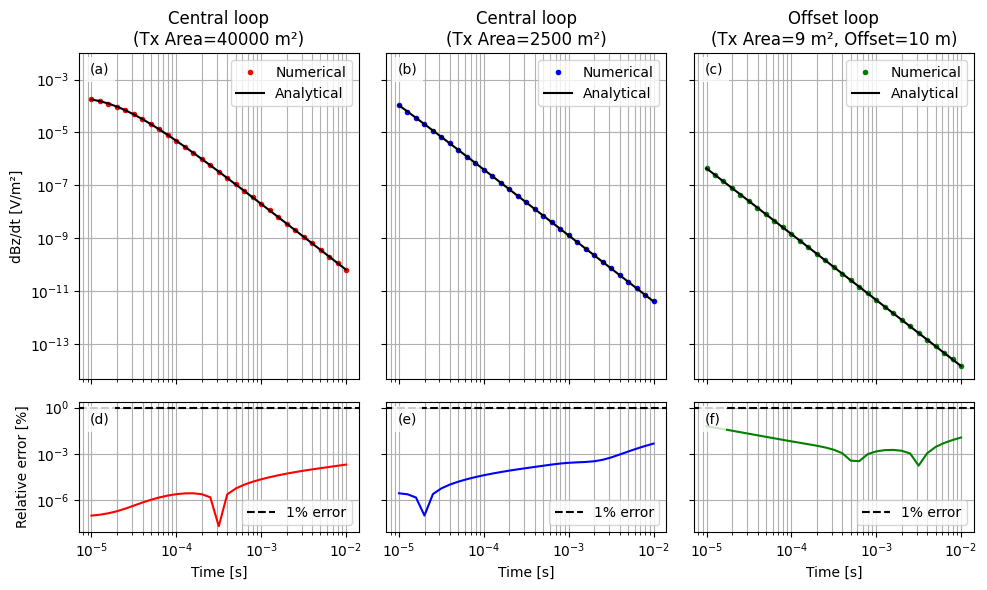

In [15]:
fig, axs = plt.subplots(2, 3, figsize=(10, 6), sharey='row', sharex=True, gridspec_kw={'height_ratios': [2.5, 1]})

# Panel 1: responses
axs[0, 0].loglog(times, np.abs(dbdt_num_200), 'r.', label='Numerical')
axs[0, 0].loglog(times, np.abs(dbdt_ana_200), 'k-', label='Analytical')
axs[0, 1].loglog(times, np.abs(dbdt_num_50), 'b.', label='Numerical')
axs[0, 1].loglog(times, np.abs(dbdt_ana_50), 'k-', label='Analytical')
axs[0, 2].loglog(times, np.abs(dbdt_offset_num), 'g.', label=f'Numerical')
axs[0, 2].loglog(times, np.abs(dbdt_offset_ana), 'k-', label=f'Analytical')
for i in range(3):
    axs[0, i].grid(True, which='both', alpha=1)
axs[0, 0].set_ylabel('dBz/dt [V/m²]')
axs[0, 0].set_title(f'Central loop\n(Tx Area={A_200:.0f} m²)')
axs[0, 0].legend()
axs[0, 1].set_title(f'Central loop\n(Tx Area={A_50:.0f} m²)')
axs[0, 1].legend()
axs[0, 2].set_title(f'Offset loop\n(Tx Area={A_3:.0f} m², Offset={r_ref} m)')
axs[0, 2].legend()

# Panel 2: central-loop relative error
axs[1, 0].loglog(times, rel_err_200, 'r-')
axs[1, 1].loglog(times, rel_err_50, 'b-')
axs[1, 0].set_ylabel('Relative error [%]')
axs[1, 0].axhline(1, color='k', linestyle='--', label='1% error')
axs[1, 1].axhline(1, color='k', linestyle='--', label='1% error')
axs[1, 0].legend(loc='lower right')
axs[1, 1].legend(loc='lower right')
axs[1, 0].grid(True, which='both', alpha=1)
axs[1, 1].grid(True, which='both', alpha=1)

# Panel 3: offset-loop relative error
axs[1, 2].loglog(times, rel_err_offset, 'g-')
axs[1, 0].set_xlabel('Time [s]')
axs[1, 1].set_xlabel('Time [s]')
axs[1, 2].set_xlabel('Time [s]')
axs[1, 2].axhline(1, color='k', linestyle='--', label='1% error')
axs[1, 2].legend(loc='lower right')
axs[1, 2].grid(True, which='both', alpha=1)

axs[0,0].set_ylim(None, 1e-2)

letters = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']
for i in range(2):
    for j in range(3):
        if i == 0:
            y_pos = 0.97
        else:
            y_pos = 0.92
        axs[i, j].text(0.04, y_pos, letters[i * 3 + j], transform=axs[i, j].transAxes,
                       fontsize=10, va='top', ha='left', bbox=dict(edgecolor='none',
                                                                   facecolor='white', alpha=0.8))
fig.tight_layout()

### Test 2 — Square loop vs circular equivalent

Compare the central square-loop response (area integral) against the circular-loop response using the equivalent radius $a_{eff} = L/\sqrt{\pi}$ (equal area). The difference quantifies the geometry effect between square and circular loop shapes.

In [16]:
# ============================================================================
# Compare: 200x200 central, 40x40 central, and 3x3 offset loop (square vs circle)
# ============================================================================

# --- Case 1: 200x200 central ---
L_200 = 200.0
a_200 = np.sqrt((L_200**2) / np.pi)
dbdt_sq_200 = tem_forward_square([], [rho_hs], L_200, times, n_quad=7, use_numba=True)
dbdt_ci_200 = tem_forward([], [rho_hs], a_200, times, use_numba=True)
rel_200 = 100 * np.abs(dbdt_sq_200 - dbdt_ci_200) / np.maximum(np.abs(dbdt_sq_200), 1e-30)

# --- Case 2: 50x50 central ---
L_50 = 50.0
a_50 = np.sqrt((L_50**2) / np.pi)
dbdt_sq_50 = tem_forward_square([], [rho_hs], L_50, times, n_quad=9, use_numba=True)
dbdt_ci_50 = tem_forward([], [rho_hs], a_50, times, use_numba=True)
rel_50 = 100 * np.abs(dbdt_sq_50 - dbdt_ci_50) / np.maximum(np.abs(dbdt_sq_50), 1e-30)

# --- Case 3: 3x3 offset ---
L_3 = 3.0
a_3 = np.sqrt((L_3**2) / np.pi)
rx_offset = 10.0
rx_x, rx_y = rx_offset, 0.0
dbdt_sq_3_off = tem_forward_square_offset([], [rho_hs], L_3, rx_x, rx_y, times, n_quad=13, use_numba=True)
dbdt_ci_3_off = tem_forward_offset([], [rho_hs], a_3, rx_offset, times, use_numba=True)
rel_3_off = 100 * np.abs(dbdt_sq_3_off - dbdt_ci_3_off) / np.maximum(np.abs(dbdt_sq_3_off), 1e-30)

print("=== Comparison summary ===")
print(f"200x200 central: max Δ = {rel_200.max():.3f}% | mean Δ = {rel_200.mean():.3f}%")
print(f"50x50 central : max Δ = {rel_50.max():.3f}% | mean Δ = {rel_50.mean():.3f}%")
print(f"3x3 offset    : max Δ = {rel_3_off.max():.3f}% | mean Δ = {rel_3_off.mean():.3f}% (r={rx_offset} m)")



=== Comparison summary ===
200x200 central: max Δ = 1.972% | mean Δ = 0.660%
50x50 central : max Δ = 0.740% | mean Δ = 0.123%
3x3 offset    : max Δ = 0.003% | mean Δ = 0.001% (r=10.0 m)


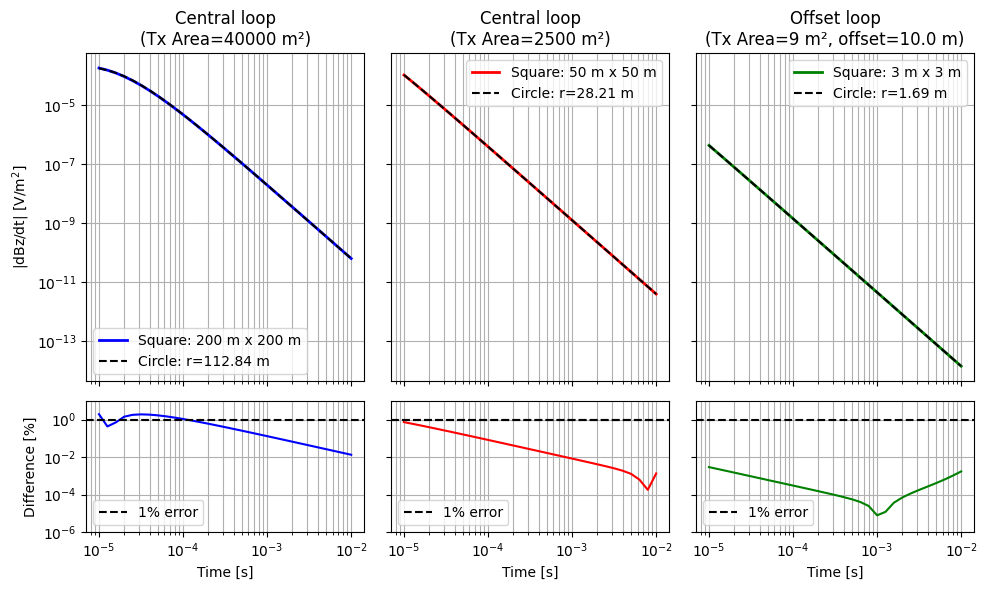

In [17]:
fig, axs = plt.subplots(2, 3, figsize=(10, 6), sharey='row', sharex=True,
                        gridspec_kw={'height_ratios': [2.5, 1]})

# 200x200 central
axs[0, 0].loglog(times, np.abs(dbdt_sq_200), "b-", lw=2, label="Square: 200 m x 200 m")
axs[0, 0].loglog(times, np.abs(dbdt_ci_200), "k--", lw=1.5, label=f"Circle: r={a_200:.2f} m")
axs[0, 0].set_title(f'Central loop\n(Tx Area={L_200**2:.0f} m²)')

axs[0, 0].grid(True, which="both")
axs[0, 0].legend()

axs[1, 0].loglog(times, rel_200, "b-")
axs[1, 0].set_xlabel("Time [s]")
axs[1, 0].set_ylabel("Difference [%]")
axs[1, 0].grid(True, which="both")

# 50x50 central
axs[0, 1].loglog(times, np.abs(dbdt_sq_50), "r-", lw=2, label="Square: 50 m x 50 m")
axs[0, 1].loglog(times, np.abs(dbdt_ci_50), "k--", lw=1.5, label=f"Circle: r={a_50:.2f} m")
axs[0, 1].set_title(f'Central loop\n(Tx Area={L_50**2:.0f} m²)')

axs[0, 1].grid(True, which="both")
axs[0, 1].legend()

axs[1, 1].loglog(times, rel_50, "r-")
axs[1, 1].set_xlabel("Time [s]")
axs[1, 1].grid(True, which="both")
axs[1, 1].axhline(1, color="k", linestyle="--")

# 3x3 offset
axs[0, 2].loglog(times, np.abs(dbdt_sq_3_off), "g-", lw=2, label="Square: 3 m x 3 m")
axs[0, 2].loglog(times, np.abs(dbdt_ci_3_off), "k--", lw=1.5, label=f"Circle: r={a_3:.2f} m")
axs[0, 2].set_title(f"Offset loop\n(Tx Area={L_3**2:.0f} m², offset={rx_offset} m)")
axs[0, 0].set_ylabel(r"|dBz/dt| [V/m$^2$]")
axs[0, 2].grid(True, which="both")
axs[0, 2].legend()
axs[1,1].set_ylim(1e-6, 10)  # avoid zero line for loglog
axs[1,2].set_ylim(1e-6, 10)  # avoid zero line for loglog

axs[1, 2].loglog(times, rel_3_off, "g-")
axs[1, 2].set_xlabel("Time [s]")
axs[1, 2].grid(True, which="both")
axs[1, 2].axhline(1, color="k", linestyle="--", label="1% error")
axs[1, 1].axhline(1, color='k', linestyle='--', label='1% error')
axs[1, 0].axhline(1, color='k', linestyle='--', label='1% error')
axs[1, 0].legend(loc='lower left')
axs[1, 1].legend(loc='lower left')
axs[1, 2].legend(loc='lower left')

plt.tight_layout()
plt.show()

### Test 3 — Layered models (central loop)
Two- and three-layer models to check physically expected behaviour.

In [18]:
import matplotlib.pyplot as plt

# ============================================================================
# Test 2: Layered models (central loop) — Two 3-layer models, subplots
# ============================================================================
times = np.logspace(-5, -2, 31)
# Model 1: low-high-low (e.g., 10/100/10 Ohm.m, thicknesses 30,20)
th1 = [30.0, 20.0]
rho1 = [10.0, 100.0, 10.0]
dbdt_lhl = tem_forward_square(th1, rho1, L_50, times, n_quad=5, 
                              use_numba=True, use_cuda=True, 
                              hankel_filter='key_101', fourier_filter='key_101', transform='dlf')

empymod_lhl = np.array([1.13679597e-03, 8.85312755e-04, 6.27135887e-04, 4.16447070e-04,
       2.65617719e-04, 1.65373670e-04, 1.01165480e-04, 6.06840037e-05,
       3.55075013e-05, 2.02048820e-05, 1.11939958e-05, 6.06756656e-06,
       3.24157743e-06, 1.72202756e-06, 9.17742677e-07, 4.94238417e-07,
       2.70100816e-07, 1.49915045e-07, 8.43374623e-08, 4.79253915e-08,
       2.74125854e-08, 1.57317107e-08, 9.03280057e-09, 5.17680309e-09,
       2.95515854e-09, 1.67682038e-09, 9.43776873e-10, 5.25742434e-10,
       2.89161438e-10, 1.56650228e-10, 8.37216630e-11])

aarhus_inv_lhl = np.array([7.749263e-04, 5.871443e-04, 4.271254e-04, 2.941576e-04,
       1.987840e-04, 1.300814e-04, 8.290166e-05, 5.142938e-05,
       3.088973e-05, 1.800577e-05, 1.016799e-05, 5.596638e-06,
       3.068655e-06, 1.627900e-06, 8.845018e-07, 4.805502e-07,
       2.641654e-07, 1.474779e-07, 8.327249e-08, 4.758555e-08,
       2.731165e-08, 1.571936e-08, 9.167189e-09, 5.228992e-09,
       3.042238e-09, 1.754475e-09, 1.009169e-09, 5.802100e-10,
       3.325352e-10, 1.906650e-10, 1.088946e-10])
       
       

aarhus_times = np.array([1.26e-05, 1.58e-05, 2.00e-05, 2.51e-05, 3.16e-05, 3.98e-05,
       5.01e-05, 6.31e-05, 7.94e-05, 1.00e-04, 1.26e-04, 1.58e-04,
       2.00e-04, 2.51e-04, 3.16e-04, 3.98e-04, 5.01e-04, 6.31e-04,
       7.94e-04, 1.00e-03, 1.26e-03, 1.58e-03, 2.00e-03, 2.51e-03,
       3.16e-03, 3.98e-03, 5.01e-03, 6.31e-03, 7.94e-03, 1.00e-02])

print(f"Length of Aarhus times: {len(aarhus_times)}, length of Aarhus dB/dt: {len(aarhus_inv_lhl)}")

diego_tem_lhl = dbdt_lhl*1.05

# Model 2: high-low-high (e.g., 100/10/100 Ohm.m, thicknesses 30,20)
th2 = [30.0, 20.0]
rho2 = [100.0, 10.0, 100.0]
dbdt_hlh = tem_forward_square(th2, rho2, L_50, times, n_quad=3, use_numba=False)
aarhus_inv_hlh = dbdt_hlh*1.02
empymod_hlh = dbdt_hlh*0.98
diego_tem_hlh = dbdt_hlh*1.03

# Placeholder for other forward code results (to be filled in later)
dbdt_other = np.full_like(times, np.nan)  # or use actual results when available

# Percentage difference
pct_aarhus_inv_lhl = 100 * (np.abs(dbdt_lhl) - np.abs(aarhus_inv_lhl)) / np.abs(dbdt_lhl)
pct_aarhus_inv_hlh = 100 * (np.abs(dbdt_hlh) - np.abs(aarhus_inv_hlh)) / np.abs(dbdt_hlh)

pct_empymod_hlh = 100 * (np.abs(dbdt_hlh) - np.abs(empymod_hlh)) / np.abs(dbdt_hlh)
pct_diego_tem_lhl = 100 * (np.abs(dbdt_lhl) - np.abs(diego_tem_lhl)) / np.abs(dbdt_lhl)
pct_diego_tem_hlh = 100 * (np.abs(dbdt_hlh) - np.abs(diego_tem_hlh)) / np.abs(dbdt_hlh)

Length of Aarhus times: 30, length of Aarhus dB/dt: 31


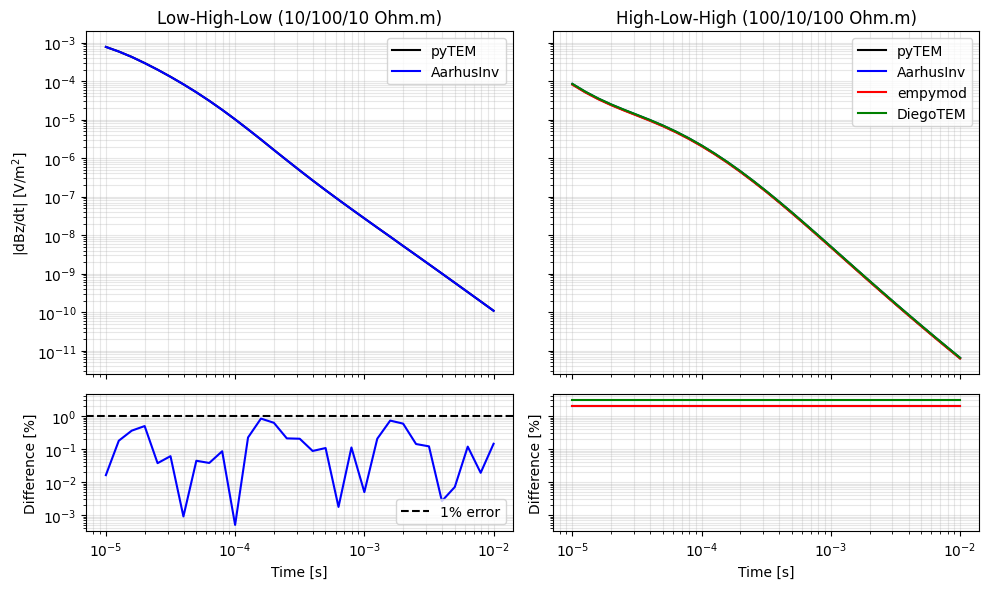

In [19]:

fig, axs = plt.subplots(2, 2, figsize=(10, 6), sharex=True, sharey='row', gridspec_kw={'height_ratios': [2.5, 1]})

hm_waveform_times = np.array([-8.333e-3, -8.033e-3, 0, 5.6e-6])
hm_waveform_current = np.array([0.0, 1.0, 1.0, 0.0])


# First column: low-high-low
axs[0, 0].loglog(times, np.abs(dbdt_lhl), 'k-', label='pyTEM')
axs[0, 0].loglog(times, np.abs(aarhus_inv_lhl), 'b-', label='AarhusInv')


#axs[0, 0].loglog(times, np.abs(empymod_lhl), 'r-', label='empymod')
#axs[0, 0].loglog(times, np.abs(diego_tem_lhl), 'g-', label='DiegoTEM')
axs[0, 0].set_ylabel(r'|dBz/dt| [V/m$^2$]')
axs[0, 0].set_title('Low-High-Low (10/100/10 Ohm.m)')
axs[0, 0].legend()
axs[0, 0].grid(True, which='both', alpha=0.3)

axs[1, 0].loglog(times, np.abs(pct_aarhus_inv_lhl), 'b-')
#axs[1, 0].loglog(times, np.abs(pct_empymod_lhl), 'r-')
#axs[1, 0].loglog(times, np.abs(pct_diego_tem_lhl), 'g-')
axs[1, 0].axhline(0, color='k', ls=':')
axs[1, 0].set_ylabel('Difference [%]')
axs[1, 0].set_xlabel('Time [s]')
axs[1, 0].grid(True, which='both', alpha=0.3)
axs[1, 0].axhline(1, color='k', ls='--', label='1% error')
axs[1, 0].legend(loc='lower right')

# Second column: high-low-high
axs[0, 1].loglog(times, np.abs(dbdt_hlh), 'k-', label='pyTEM')
axs[0, 1].loglog(times, np.abs(aarhus_inv_hlh), 'b-', label='AarhusInv')
axs[0, 1].loglog(times, np.abs(empymod_hlh), 'r-', label='empymod')
axs[0, 1].loglog(times, np.abs(diego_tem_hlh), 'g-', label='DiegoTEM')
axs[0, 1].set_title('High-Low-High (100/10/100 Ohm.m)')
axs[0, 1].legend()
axs[0, 1].grid(True, which='both', alpha=0.3)

axs[1, 1].loglog(times, np.abs(pct_aarhus_inv_hlh), 'b-')
axs[1, 1].loglog(times, np.abs(pct_empymod_hlh), 'r-')
axs[1, 1].loglog(times, np.abs(pct_diego_tem_hlh), 'g-')
axs[1, 1].axhline(0, color='k', ls=':')
axs[1, 1].set_xlabel('Time [s]')
axs[1, 1].set_ylabel('Difference [%]')
axs[1, 1].grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

### Test 4 and 5 — Waveform convolution (ramp-off) and System filter effect
Compare the ideal step-off response with linear ramp-off waveforms of 1 µs, 5 µs, and 20 µs duration. The finite ramp smooths and reduces the early-time response.
Show how 1st- and 2nd-order Butterworth low-pass filters at different cutoff frequencies attenuate the early-time (high-frequency) response.


In [20]:


t_fine = np.logspace(np.log10(5e-6), np.log10(2e-2), 151)
step_fine = tem_forward([], [rho_hs], a_50, t_fine)

ramp_durations = [1e-6, 5e-6, 20e-6]  # 1, 5, 20 µs
dbdt_ramp = {}
for T_ramp in ramp_durations:
    wf_t = np.array([-T_ramp, 0.0])
    wf_I = np.array([1.0, 0.0])
    dbdt_ramp[T_ramp] = convolve_waveform(t_fine, step_fine, wf_t, wf_I, times)

print(f"  Waveform convolution done ({rho_hs} Ohm.m half-space).")
for T_ramp in ramp_durations:
    ratio = np.abs(dbdt_ramp[T_ramp][0] / dbdt_num_50[0])
    print(f"  T_ramp = {T_ramp*1e6:.0f} µs: early-time ratio = {ratio:.4f}")
    ratio = np.abs(dbdt_ramp[T_ramp][-1] / dbdt_num_50[-1])
    print(f"  T_ramp = {T_ramp*1e6:.0f} µs: late-time ratio = {ratio:.4f}")


  Waveform convolution done (100.0 Ohm.m half-space).
  T_ramp = 1 µs: early-time ratio = 0.8963
  T_ramp = 1 µs: late-time ratio = 1.0022
  T_ramp = 5 µs: early-time ratio = 0.6261
  T_ramp = 5 µs: late-time ratio = 1.0017
  T_ramp = 20 µs: early-time ratio = 0.2846
  T_ramp = 20 µs: late-time ratio = 0.9998


In [21]:
def butterworth_filter(f_low=None, f_high=None, order=1):
    """
    Create a Butterworth bandpass system transfer function.

    Parameters
    ----------
    f_low  : low-cut frequency [Hz] (high-pass), or None for no high-pass
    f_high : high-cut frequency [Hz] (low-pass), or None for no low-pass
    order  : filter order (1 or 2)

    Returns
    -------
    H : callable  omega -> complex transfer function
    """
    def H(omega):
        s = 1j * omega
        result = np.ones_like(s)
        # Low-pass (high-cut)
        if f_high is not None:
            wc = 2 * np.pi * f_high
            if order == 1:
                result *= wc / (s + wc)
            elif order == 2:
                result *= wc**2 / (s**2 + np.sqrt(2) * wc * s + wc**2)
        # High-pass (low-cut)
        if f_low is not None:
            wc = 2 * np.pi * f_low
            if order == 1:
                result *= s / (s + wc)
            elif order == 2:
                result *= s**2 / (s**2 + np.sqrt(2) * wc * s + wc**2)
        return result
    return H

def cascade_filter(filtfreq):
    """Two cascaded 1st-order Butterworth LP (WalkTEM convention)."""
    H1 = butterworth_filter(f_high=filtfreq, order=1)
    H2 = butterworth_filter(f_high=3e5, order=1)
    return lambda omega: H1(omega) * H2(omega)



=== Test 5: System filter effect (100.0 Ohm.m half-space) ===
  2nd order LP, 200 kHz: early-time amplitude ratio = 1.3167
  WalkTEM 210 kHz + 300 kHz: early-time amplitude ratio = 1.4607
  WalkTEM 450 kHz + 300 kHz: early-time amplitude ratio = 1.2669


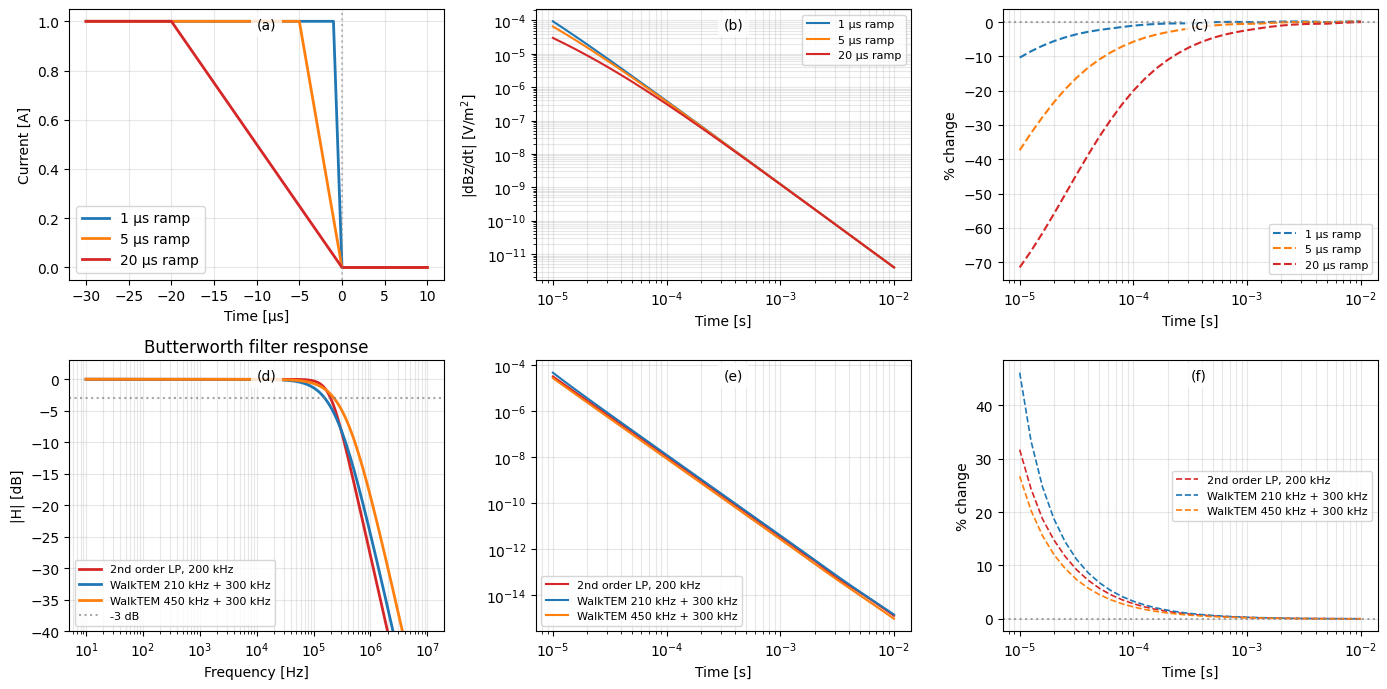

In [22]:

fig, axs = plt.subplots(2, 3, figsize=(14, 7))
# Left: waveform shapes
colors_r = ['C0', 'C1', 'C3']
max_ramp = max(ramp_durations)
for T_ramp, c in zip(ramp_durations, colors_r):
    wf_plot_t = np.array([-1.5*max_ramp, -T_ramp, 0, 0.5*max_ramp]) * 1e6
    wf_plot_I = np.array([1, 1, 0, 0])
    axs[0,0].plot(wf_plot_t, wf_plot_I, c=c, lw=2,
               label=f'{T_ramp*1e6:.0f} µs ramp')
axs[0,0].axvline(0, color='gray', ls=':', alpha=0.5)
axs[0,0].set(xlabel='Time [µs]', ylabel='Current [A]')
axs[0,0].legend(); axs[0,0].grid(True, alpha=0.3)

# Right: convolved vs step-off
for T_ramp, c in zip(ramp_durations, colors_r):
    axs[0,1].loglog(times, np.abs(dbdt_ramp[T_ramp]), c=c, lw=1.5,
                    label=f'{T_ramp*1e6:.0f} µs ramp')
axs[0,1].set(xlabel='Time [s]', ylabel=r'|dBz/dt| [V/m$^2$]')
axs[0,1].legend(fontsize=8); axs[0,1].grid(True, which='both', alpha=0.3)

# --- Row 0: Ramp-off convolution effects ---
# (0,2): Ramp-off percentage change
for T_ramp, c in zip(ramp_durations, colors_r):
    pct = 100 * (np.abs(dbdt_ramp[T_ramp]) - np.abs(dbdt_num_50)) / np.abs(dbdt_num_50)
    ratio = np.abs(dbdt_ramp[T_ramp] / dbdt_num_50)
    axs[0, 2].semilogx(times, pct, c=c, ls='--', label=f'{T_ramp*1e6:.0f} µs ramp')
axs[0, 2].axhline(0, color='gray', ls=':', alpha=0.7)
axs[0, 2].set(ylabel='% change', xlabel='Time [s]')
axs[0, 2].legend(fontsize=8)
axs[0, 2].grid(True, which='both', alpha=0.3)

# --- Row 1: Butterworth filter effects ---

filt_configs = [
    ('2nd order LP, 200 kHz',       butterworth_filter(f_high=200e3, order=2)),
    ('WalkTEM 210 kHz + 300 kHz',   cascade_filter(210e3)),
    ('WalkTEM 450 kHz + 300 kHz',   cascade_filter(450e3)),
]

dbdt_filtered = {}
for label, filt in filt_configs:
    dbdt_filtered[label] = tem_forward([], [rho_hs], a_50, times,
                                        system_filter=filt)

print(f"\n=== Test 5: System filter effect ({rho_hs} Ohm.m half-space) ===")
for label in dbdt_filtered:
    ratio_early = np.abs(dbdt_filtered[label][0] / dbdt_num_50[0])
    print(f"  {label}: early-time amplitude ratio = {ratio_early:.4f}")
# (1,0): Filter frequency response
freqs = np.logspace(1, 7, 500)
omega_arr = 2 * np.pi * freqs
colors_f = ['C3', 'C0', 'C1', 'C2']
for (label, filt), c in zip(filt_configs, colors_f):
    mag_db = 20 * np.log10(np.abs(filt(omega_arr)))
    axs[1, 0].semilogx(freqs, mag_db, c=c, lw=2, label=label)
axs[1, 0].set(xlabel='Frequency [Hz]', ylabel='|H| [dB]', title='Butterworth filter response', ylim=(-40, 3))
axs[1, 0].axhline(-3, color='gray', ls=':', alpha=0.7, label='-3 dB')
axs[1, 0].legend(fontsize=8)
axs[1, 0].grid(True, which='both', alpha=0.3)

# (1,1): Filter effect on dBz/dt (difference)
for (label, _), c in zip(filt_configs, colors_f):
    diff = np.abs(dbdt_filtered[label]) - np.abs(dbdt_num_50)
    axs[1, 1].loglog(times, diff, c=c, lw=1.5, label=label)
axs[1, 1].set(xlabel='Time [s]')
axs[1, 1].legend(fontsize=8)
axs[1, 1].grid(True, which='both', alpha=0.3)

# (1,2): Filter percentage change
for (label, _), c in zip(filt_configs, colors_f):
    pct = 100 * (np.abs(dbdt_filtered[label]) - np.abs(dbdt_num_50)) / np.abs(dbdt_num_50)
    axs[1, 2].semilogx(times, pct, c=c, lw=1.2, label=label, ls='--')
axs[1, 2].axhline(0, color='gray', ls=':', alpha=0.7)
axs[1, 2].set(ylabel='% change', xlabel='Time [s]')
axs[1, 2].legend(fontsize=8)
axs[1, 2].grid(True, which='both', alpha=0.3)

letters = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']
for i in range(2):
    for j in range(3):
        if i == 0:
            y_pos = 0.97
        else:
            y_pos = 0.97
        axs[i, j].text(0.5, y_pos, letters[i * 3 + j], transform=axs[i, j].transAxes,
                       fontsize=10, va='top', ha='left', bbox=dict(edgecolor='none',
                                                                   facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()


### Test 7 — IP effect (multiple IP models)

Compare the step-off TEM response of a two-layer model using four IP model formulations. IP is applied to layer 2 only.

**Pelton resistivity** (Pelton et al., 1978):
$$\rho(\omega) = \rho_0 \left[1 - m\left(1 - \frac{1}{1 + (j\omega\tau)^c}\right)\right]$$

**Cole-Cole conductivity** (Cole & Cole, 1941):
$$\sigma(\omega) = \sigma_\infty + \frac{\sigma_0 - \sigma_\infty}{1 + (j\omega\tau)^c}$$

**Double Pelton** (two relaxation terms):
$$\rho(\omega) = \rho_0 \left[1 - R_1(\omega) - R_2(\omega)\right], \quad R_i = m_i\left(1 - \frac{1}{1 + (j\omega\tau_i)^{c_i}}\right)$$

**Maximum Phase Angle (MPA)** (Fiandaca et al., 2018):
Parameterised by $(\rho_0, \phi_{max}, \tau_\phi, c)$. The classical CC parameters $(m, \tau_\rho)$ are recovered iteratively (Appendix A.1–A.08), then the Pelton resistivity formula is applied.

=== Test 7: IP models ([100.0, 10.0] Ohm.m, h=[10.0] m) ===
  No IP
  Pelton (m=0.3, τ=0.01, c=0.5)
  Double Pelton (0.15/0.15, τ=0.0001/0.1)


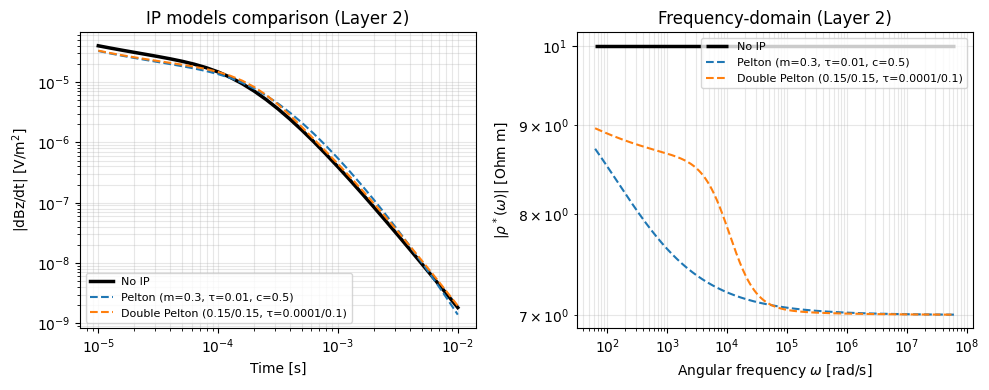

In [23]:
# ============================================================================
# Test 7: IP models — Pelton, Cole-Cole, Double Pelton, MPA
# ============================================================================

# --- IP model functions (complex resistivity at angular frequency omega) ----

def pelton_res_rho(rho_0, m, tau, c, omega):
    """Pelton et al. (1978) — resistivity formulation."""
    iotc = (1j * omega * tau) ** c
    return rho_0 * (1 - m * (1 - 1 / (1 + iotc)))


def cole_cole_rho(rho_0, cond_0, cond_inf, tau, c, omega):
    """Cole & Cole (1941) — conductivity formulation, returned as resistivity.
    cond_0 : DC conductivity (low-freq limit)
    cond_inf: high-freq limit conductivity
    """
    iotc = (1j * omega * tau) ** c
    cond = cond_inf + (cond_0 - cond_inf) / (1 + iotc)
    return 1.0 / cond  # return as complex resistivity


def double_pelton_rho(rho_0, m1, tau1, c1, m2, tau2, c2, omega):
    """Double Pelton — two relaxation terms (Pelton et al., 1978)."""
    iotc1 = (1j * omega * tau1) ** c1
    iotc2 = (1j * omega * tau2) ** c2
    r1 = m1 * (1 - 1 / (1 + iotc1))
    r2 = m2 * (1 - 1 / (1 + iotc2))
    return rho_0 * (1 - r1 - r2)

# --- Generic forward model with pluggable IP function per layer ------------

def tem_forward_ip(thicknesses, resistivities, tx_radius, times,
                   ip_funcs=None, current=1.0,
                   system_filter=None):
    """
    Central-loop TEM step-off dBz/dt with arbitrary IP model per layer.

    Parameters
    ----------
    thicknesses  : layer thicknesses [m] (N-1 values)
    resistivities: DC resistivities rho_0 [Ohm.m] (N values)
    tx_radius    : Tx loop radius [m]
    times        : gate times [s]
    ip_funcs     : list of callables (one per layer).
                   Each callable: f(rho_0, omega) -> complex resistivity.
                   Use None for layers without IP (real rho_0 is used).
    current, system_filter : same as tem_forward.

    Returns dBz/dt [V/m^2].
    """
    thicknesses = np.asarray(thicknesses, dtype=float)
    rho_dc = np.asarray(resistivities, dtype=float)
    times = np.asarray(times, dtype=float)
    a_r = float(tx_radius)
    n_layers = len(rho_dc)

    if ip_funcs is None:
        ip_funcs = [None] * n_layers

    def _hz_sec(omega):
        rho_complex = np.array([
            ip_funcs[j](rho_dc[j], omega) if ip_funcs[j] is not None
            else complex(rho_dc[j])
            for j in range(n_layers)
        ])
        lam = _HANKEL_BASE_201 / a_r
        r_te = te_reflection_coeff(lam, omega, thicknesses, rho_complex)
        hankel = np.dot(r_te * lam, _HANKEL_J1_201) / a_r
        hz = 0.5 * a_r * hankel
        if system_filter is not None:
            hz *= system_filter(omega)
        return hz

    dbdt = np.zeros(len(times))
    for i, t in enumerate(times):
        omega_pts = _FOURIER_BASE_81 / t
        signal = np.zeros(len(omega_pts))
        for k, w in enumerate(omega_pts):
            signal[k] = MU0 * np.imag(_hz_sec(w))
        dbdt[i] = np.dot(signal, _FOURIER_SIN_81) / t

    dbdt *= current * 2.0 / np.pi
    return dbdt

# --- Model setup (2-layer: 100 / 10 Ohm.m, IP in layer 2 only) -----------
thick_ip = [10.0]
rho_ip = [100.0, 10.0]
rho2 = rho_ip[1]

# Common IP parameters for comparison
m, tau, c = 0.3, 0.01, 0.5

# Cole-Cole conductivity params (equivalent to Pelton at same m, tau, c)
cond_0 = 1.0 / rho2
cond_inf = cond_0 * (1 - m)   # sigma_inf = sigma_0 * (1 - m)

# Double Pelton: split chargeability into two terms at different tau
m1, tau1, c1 = 0.15, 0.0001, 1.
m2, tau2, c2 = 0.15, 0.1,   0.4

ip_models = {
    'No IP': [None, None],
    f'Pelton (m={m}, τ={tau}, c={c})': [
        lambda rho0, w, _m=m, _tau=tau, _c=c: pelton_res_rho(rho0, _m, _tau, _c, w),
        lambda rho0, w, _m=m, _tau=tau, _c=c: pelton_res_rho(rho0, _m, _tau, _c, w)
    ],
    f'Double Pelton ({m1}/{m2}, τ={tau1}/{tau2})': [
        lambda rho0, w, _m1=m1, _t1=tau1, _c1=c1, _m2=m2, _t2=tau2, _c2=c2:
            double_pelton_rho(rho0, _m1, _t1, _c1, _m2, _t2, _c2, w),
        lambda rho0, w, _m1=m1, _t1=tau1, _c1=c1, _m2=m2, _t2=tau2, _c2=c2:
            double_pelton_rho(rho0, _m1, _t1, _c1, _m2, _t2, _c2, w)
    ],
}

# --- Compute TEM responses ---
dbdt_ip = {}
for label, ip_f in ip_models.items():
    dbdt_ip[label] = tem_forward_ip(thick_ip, rho_ip, a_200, times, ip_funcs=ip_f)

print(f"=== Test 7: IP models ({rho_ip} Ohm.m, h={thick_ip} m) ===")
for label in ip_models:
    print(f"  {label}")

# MPA verification: should match Pelton with same underlying CC params
pelton_key = [k for k in ip_models if 'Pelton (' in k][0]


# --- Plot time-domain ---
fig_ip, axs = plt.subplots(1, 2, figsize=(10, 4))
ax_ip, ax_freq = axs
colors_ip = ['k', 'C0', 'C1', 'C2', 'C3']
for (label, _), ci in zip(ip_models.items(), colors_ip):
    ls = '-' if label == 'No IP' else '--'
    lw = 2.5 if label == 'No IP' else 1.5
    ax_ip.loglog(times, np.abs(dbdt_ip[label]), c=ci, ls=ls, lw=lw, label=label)

ax_ip.set(xlabel='Time [s]', ylabel=r'|dBz/dt| [V/m$^2$]',
          title='IP models comparison (Layer 2)')
ax_ip.legend(fontsize=8)
ax_ip.grid(True, which='both', alpha=0.3)

# Frequency-domain plot (show |rho*(omega)| for each model)
for (label, ip_f), ci in zip(ip_models.items(), colors_ip):
    if ip_f[1] is not None:
        rho_w = np.array([ip_f[1](rho_ip[1], w) for w in omega_arr])
        ax_freq.loglog(omega_arr, np.abs(rho_w), c=ci, ls='--', lw=1.5, label=label)
    else:
        ax_freq.hlines(rho_ip[1], omega_arr[0], omega_arr[-1], colors=ci, linestyles='-', lw=2.5, label=label)

ax_freq.set(xlabel=r'Angular frequency $\omega$ [rad/s]', ylabel=r'$|\rho^*(\omega)|$ [Ohm m]',
            title='Frequency-domain (Layer 2)')
ax_freq.legend(fontsize=8)
ax_freq.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()


### Test 9 — Runtime benchmark (NumPy vs Numba vs CUDA)

Compare runtime for:
- circular loop,
- square loop without symmetry reduction,
- square loop with symmetry reduction,
for NumPy/Python, Numba JIT, and CUDA/CuPy GPU paths.

In [24]:
import time, sys, io

# Benchmark setup
thick_bm = []
rho_bm = [rho_hs]
a_bm = a_50
L_bm = np.sqrt(np.pi) * a_bm
rx_bm = rx_offset if 'rx_offset' in globals() else 10.0

configs = {
    'DLF 201/81':  dict(hankel_filter='key_201', fourier_filter='key_81',  transform='dlf'),
    'DLF 101/81':  dict(hankel_filter='key_101', fourier_filter='key_81',  transform='dlf'),
    'DLF 101/101': dict(hankel_filter='key_101', fourier_filter='key_101', transform='dlf'),
    'Euler-8 201':  dict(hankel_filter='key_201', transform='euler', euler_order=8),
    'Euler-11 201': dict(hankel_filter='key_201', transform='euler', euler_order=11),
    'Euler-11 101': dict(hankel_filter='key_101', transform='euler', euler_order=11),
    'Euler-15 201': dict(hankel_filter='key_201', transform='euler', euler_order=15),
}

# Suppress JIT compilation output during warm-up
old_stdout = sys.stdout; sys.stdout = io.StringIO()
try:
    for cfg in configs.values():
        _ = tem_forward(thick_bm, rho_bm, a_bm, times, use_numba=True, use_cuda=False, **cfg)
        _ = tem_forward_square(thick_bm, rho_bm, L_bm, times, use_numba=True, use_cuda=False, use_symmetry=True, **cfg)
        _ = tem_forward_offset(thick_bm, rho_bm, a_bm, rx_bm, times, use_numba=True, use_cuda=False, **cfg)
    if HAS_CUDA:
        for cfg in configs.values():
            if cfg.get('transform') != 'euler':  # Euler GPU not implemented
                _ = tem_forward(thick_bm, rho_bm, a_bm, times, use_cuda=True, use_numba=False, **cfg)
                _ = tem_forward_square(thick_bm, rho_bm, L_bm, times, use_cuda=True, use_numba=False, use_symmetry=True, **cfg)
                _ = tem_forward_offset(thick_bm, rho_bm, a_bm, rx_bm, times, use_cuda=True, use_numba=False, **cfg)
finally:
    sys.stdout = old_stdout

def bench(fn, n_repeat=5):
    vals = []
    for _ in range(n_repeat):
        if HAS_CUDA:
            cp.cuda.Stream.null.synchronize()
        t0 = time.perf_counter()
        fn()
        if HAS_CUDA:
            cp.cuda.Stream.null.synchronize()
        vals.append(time.perf_counter() - t0)
    return float(np.min(vals))

if HAS_CUDA:
    cp.cuda.Stream.null.synchronize(); _ = cp.zeros(1); cp.cuda.Stream.null.synchronize()

ref_cfg = configs['DLF 201/81']

# --- Benchmark tables ---
for geom_name, bench_fn in [
    ("CENTRAL CIRCLE", lambda cfg: tem_forward(thick_bm, rho_bm, a_bm, times, **cfg)),
    ("SQUARE (sym)", lambda cfg: tem_forward_square(thick_bm, rho_bm, L_bm, times, use_symmetry=True, **cfg)),
    ("OFFSET CIRCLE", lambda cfg: tem_forward_offset(thick_bm, rho_bm, a_bm, rx_bm, times, **cfg)),
]:
    print(f"\n{'='*64}")
    print(f"  {geom_name}")
    print(f"{'='*64}")
    print(f"  {'Config':16s}  {'nb (ms)':>10s}  {'cuda (ms)':>10s}  {'speedup':>8s}")
    ref_nb = None
    for cname, cfg in configs.items():
        t_nb = bench(lambda c=cfg: bench_fn(dict(use_numba=True, use_cuda=False, **c)))
        line = f"  {cname:16s}  {t_nb*1e3:10.2f}"
        if ref_nb is None:
            ref_nb = t_nb
        if HAS_CUDA and cfg.get('transform') != 'euler':
            t_cu = bench(lambda c=cfg: bench_fn(dict(use_cuda=True, use_numba=False, **c)))
            line += f"  {t_cu*1e3:10.2f}  {ref_nb/t_cu:7.1f}x"
        else:
            line += f"  {'N/A':>10s}  {ref_nb/t_nb:7.1f}x"
        print(line)

# --- Accuracy ---
print(f"\n{'='*64}")
print("  ACCURACY: max rel error vs DLF 201/81 (reference)")
print(f"{'='*64}")
ref_c = tem_forward(thick_bm, rho_bm, a_bm, times, use_numba=True, use_cuda=False, **ref_cfg)
ref_s = tem_forward_square(thick_bm, rho_bm, L_bm, times, use_numba=True, use_cuda=False, use_symmetry=True, **ref_cfg)
ref_o = tem_forward_offset(thick_bm, rho_bm, a_bm, rx_bm, times, use_numba=True, use_cuda=False, **ref_cfg)
print(f"  {'Config':16s}  {'Circle':>10s}  {'Square':>10s}  {'Offset':>10s}")
for cname, cfg in configs.items():
    c = tem_forward(thick_bm, rho_bm, a_bm, times, use_numba=True, use_cuda=False, **cfg)
    s = tem_forward_square(thick_bm, rho_bm, L_bm, times, use_numba=True, use_cuda=False, use_symmetry=True, **cfg)
    o = tem_forward_offset(thick_bm, rho_bm, a_bm, rx_bm, times, use_numba=True, use_cuda=False, **cfg)
    dc = np.max(np.abs(c - ref_c) / np.maximum(np.abs(ref_c), 1e-30))
    ds = np.max(np.abs(s - ref_s) / np.maximum(np.abs(ref_s), 1e-30))
    do = np.max(np.abs(o - ref_o) / np.maximum(np.abs(ref_o), 1e-30))
    print(f"  {cname:16s}  {dc:10.2e}  {ds:10.2e}  {do:10.2e}")


  CENTRAL CIRCLE
  Config               nb (ms)   cuda (ms)   speedup
  DLF 201/81             15.50        4.53      3.4x
  DLF 101/81              7.41        2.85      5.4x
  DLF 101/101             9.67        3.16      4.9x
  Euler-8 201             2.86         N/A      5.4x
  Euler-11 201            4.03         N/A      3.8x
  Euler-11 101            2.07         N/A      7.5x
  Euler-15 201            5.34         N/A      2.9x

  SQUARE (sym)
  Config               nb (ms)   cuda (ms)   speedup
  DLF 201/81            241.68       60.28      4.0x
  DLF 101/81            114.29       31.69      7.6x
  DLF 101/101           123.91       42.10      5.7x
  Euler-8 201            40.64         N/A      5.9x
  Euler-11 201           51.96         N/A      4.7x
  Euler-11 101           26.34         N/A      9.2x
  Euler-15 201           69.80         N/A      3.5x

  OFFSET CIRCLE
  Config               nb (ms)   cuda (ms)   speedup
  DLF 201/81             11.88        4.24      

In [31]:
# ============================================================================
# Speed test: NumPy vs Numba vs CUDA — populate results / results_offset
# ============================================================================
# Uses the same bench() helper and model parameters from the cell above.

# --- Central-loop timing ---
results = {}

cfg = configs['Euler-11 101']  # use the same config for all tests here, to isolate JIT/CUDA overhead differences
#cfg = configs['DLF 101/101']  # use the same config for all tests here, to isolate JIT/CUDA overhead differences
# Circle
results['Circle (np)']        = bench(lambda: tem_forward(thick_bm, rho_bm, a_bm, times, use_numba=False, use_cuda=False, **cfg))
results['Circle (nb)']        = bench(lambda: tem_forward(thick_bm, rho_bm, a_bm, times, use_numba=True, use_cuda=False, **cfg))
if HAS_CUDA:
    results['Circle (cuda)']  = bench(lambda: tem_forward(thick_bm, rho_bm, a_bm, times, use_cuda=True, use_numba=False, **cfg))

# Square - Full
results['Square - Full (np)'] = bench(lambda: tem_forward_square(thick_bm, rho_bm, L_bm, times, use_numba=False, use_cuda=False, use_symmetry=False, **cfg))
results['Square - Full (nb)'] = bench(lambda: tem_forward_square(thick_bm, rho_bm, L_bm, times, use_numba=True, use_cuda=False, use_symmetry=False, **cfg))
if HAS_CUDA:
    results['Square - Full (cuda)'] = bench(lambda: tem_forward_square(thick_bm, rho_bm, L_bm, times, use_cuda=True, use_numba=False, use_symmetry=False, **cfg))

# Square - Sym
results['Square - Sym (np)']  = bench(lambda: tem_forward_square(thick_bm, rho_bm, L_bm, times, use_numba=False, use_cuda=False, use_symmetry=True, **cfg))
results['Square - Sym (nb)']  = bench(lambda: tem_forward_square(thick_bm, rho_bm, L_bm, times, use_numba=True, use_cuda=False, use_symmetry=True, **cfg))
if HAS_CUDA:
    results['Square - Sym (cuda)'] = bench(lambda: tem_forward_square(thick_bm, rho_bm, L_bm, times, use_cuda=True, use_numba=False, use_symmetry=True, **cfg))

# --- Offset-loop timing ---
results_offset = {}

# Circle
results_offset['Circle (np)']        = bench(lambda: tem_forward_offset(thick_bm, rho_bm, a_bm, rx_bm, times, use_numba=False, use_cuda=False, **cfg))
results_offset['Circle (nb)']        = bench(lambda: tem_forward_offset(thick_bm, rho_bm, a_bm, rx_bm, times, use_numba=True, use_cuda=False, **cfg))
if HAS_CUDA:
    results_offset['Circle (cuda)']  = bench(lambda: tem_forward_offset(thick_bm, rho_bm, a_bm, rx_bm, times, use_cuda=True, use_numba=False, **cfg))

# Square - Full
results_offset['Square - Full (np)'] = bench(lambda: tem_forward_square_offset(thick_bm, rho_bm, L_bm, rx_bm, 0.0, times, use_numba=False, use_cuda=False, **cfg))
results_offset['Square - Full (nb)'] = bench(lambda: tem_forward_square_offset(thick_bm, rho_bm, L_bm, rx_bm, 0.0, times, use_numba=True, use_cuda=False, **cfg))
if HAS_CUDA:
    results_offset['Square - Full (cuda)'] = bench(lambda: tem_forward_square_offset(thick_bm, rho_bm, L_bm, rx_bm, 0.0, times, use_cuda=True, use_numba=False, **cfg))

# --- Print summary ---
print("=" * 60)
print("CENTRAL-LOOP: NumPy vs Numba vs CUDA")
print("=" * 60)
for k, v in results.items():
    print(f"  {k:24s}: {v:.4f} s")

print(f"\nOFFSET-LOOP (r = {rx_bm:g} m): NumPy vs Numba vs CUDA")
print("=" * 60)
for k, v in results_offset.items():
    print(f"  {k:24s}: {v:.4f} s")

CENTRAL-LOOP: NumPy vs Numba vs CUDA
  Circle (np)             : 0.0099 s
  Circle (nb)             : 0.0011 s
  Circle (cuda)           : 0.0101 s
  Square - Full (np)      : 0.2918 s
  Square - Full (nb)      : 0.0343 s
  Square - Full (cuda)    : 0.0175 s
  Square - Sym (np)       : 0.1484 s
  Square - Sym (nb)       : 0.0177 s
  Square - Sym (cuda)     : 0.0105 s

OFFSET-LOOP (r = 10 m): NumPy vs Numba vs CUDA
  Circle (np)             : 0.0141 s
  Circle (nb)             : 0.0011 s
  Circle (cuda)           : 0.0011 s
  Square - Full (np)      : 1.2659 s
  Square - Full (nb)      : 0.1475 s
  Square - Full (cuda)    : 0.0682 s


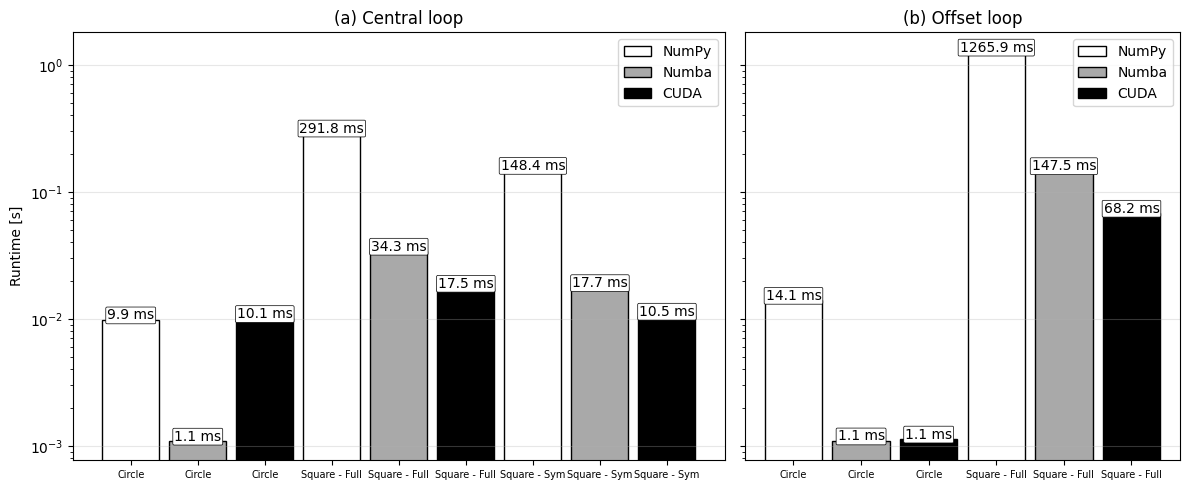

Central benchmark:
  Circle (np)             : 0.0099 s
  Circle (nb)             : 0.0011 s
  Circle (cuda)           : 0.0101 s
  Square - Full (np)      : 0.2918 s
  Square - Full (nb)      : 0.0343 s
  Square - Full (cuda)    : 0.0175 s
  Square - Sym (np)       : 0.1484 s
  Square - Sym (nb)       : 0.0177 s
  Square - Sym (cuda)     : 0.0105 s

Offset benchmark (r = 10 m):
  Circle (np)             : 0.0141 s
  Circle (nb)             : 0.0011 s
  Circle (cuda)           : 0.0011 s
  Square - Full (np)      : 1.2659 s
  Square - Full (nb)      : 0.1475 s
  Square - Full (cuda)    : 0.0682 s


In [36]:
# --- Plot runtimes ---
fig, axs = plt.subplots(1, 2, figsize=(12, 5), 
                        gridspec_kw={'width_ratios': [9, 6]}, sharey=True)

# Color mapping: np=black, nb=lightgrey, cuda=green
def _bar_color(key):
    if '(cuda)' in key: return 'k'
    if '(nb)' in key: return 'darkgrey'
    return 'w'

# Central systems
labels_c = list(results.keys())
times_c = [results[k] for k in labels_c]
x_c = np.arange(len(labels_c))
colors_c = [_bar_color(k) for k in labels_c]

bars_c = axs[0].bar(x_c, times_c, width=0.85, color=colors_c, edgecolor='black')
axs[0].set_ylabel('Runtime [s]')
axs[0].set_title('(a) Central loop')
axs[0].set_yscale('log')
axs[0].grid(True, axis='y', alpha=0.3)
axs[0].set_xticks(x_c)
axs[0].set_xticklabels([k.replace(' (np)', '').replace(' (nb)', '').replace(' (cuda)', '') for k in labels_c], rotation=0, fontsize=7)

for bar, val in zip(bars_c, times_c):
    axs[0].text(bar.get_x() + bar.get_width() / 2, val * 0.95,
                f"{val*1000:.1f} ms", ha='center', va='bottom', 
                bbox=dict(boxstyle='round,pad=0.1', facecolor='white', edgecolor='black', lw=0.5))

# Offset systems
labels_o = list(results_offset.keys())
times_o = [results_offset[k] for k in labels_o]
x_o = np.arange(len(labels_o))
colors_o = [_bar_color(k) for k in labels_o]

bars_o = axs[1].bar(x_o, times_o, width=0.85, color=colors_o, edgecolor='black')
axs[1].set_title('(b) Offset loop')
axs[1].set_yscale('log')
axs[1].grid(True, axis='y', alpha=0.3)
axs[1].set_xticks(x_o)
axs[1].set_xticklabels([k.replace(' (np)', '').replace(' (nb)', '').replace(' (cuda)', '') for k in labels_o], rotation=0, fontsize=7)

for bar, val in zip(bars_o, times_o):
    axs[1].text(bar.get_x() + bar.get_width() / 2, val * 0.95,
                f"{val*1000:.1f} ms", ha='center', va='bottom',
                bbox=dict(boxstyle='round,pad=0.1', facecolor='white', edgecolor='black', lw=0.5))

from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor='w', edgecolor='black', label='NumPy'),
    Patch(facecolor='darkgrey', edgecolor='black', label='Numba'),
]
if HAS_CUDA:
    legend_handles.append(Patch(facecolor='k', edgecolor='black', label='CUDA'))
axs[0].legend(handles=legend_handles, loc='upper right')
axs[1].legend(handles=legend_handles, loc='upper right')

plt.tight_layout()
plt.show()

print("Central benchmark:")
for k, v in results.items():
    print(f"  {k:24s}: {v:.4f} s")

print(f"\nOffset benchmark (r = {rx_bm:g} m):")
for k, v in results_offset.items():
    print(f"  {k:24s}: {v:.4f} s")

In [27]:
# ============================================================
# Standalone Euler acceleration — VERIFICATION ONLY
# ============================================================
# This cell defines a self-contained euler_invert() for testing.
# It is NOT used by the forward functions, which use the
# precomputed EULER_PARAMS weights in _tem_circular_euler_jit
# and _tem_square_euler_jit.  Kept here to verify those
# precomputed weights reproduce the direct algorithm.

def euler_invert(F, t, N=15, A=18.4):
    """
    Inverse Laplace transform via Euler acceleration (Abate & Whitt 1995).

    Evaluates F(s) at 2N+1 complex points along Re(s) = A/(2t),
    then accelerates the alternating partial sums with binomial weights.

    This is a reference implementation for verification. The production
    Euler path in the forward functions uses precomputed eta/A weights
    from EULER_PARAMS (see _tem_circular_euler_jit).

    Parameters
    ----------
    F : callable  F(s) -> complex, the Laplace-domain function
    t : float     time at which to evaluate the inverse
    N : int       half-order (default 15 — 31 evaluations, ~8 digits)
    A : float     Bromwich abscissa parameter (default 18.4)

    Returns
    -------
    f(t) : float — the time-domain value
    """
    c = A / (2.0 * t)        # Bromwich abscissa
    h = np.pi / t             # imaginary spacing

    # Function values along the Bromwich line
    vals = np.zeros(2 * N + 1)
    for k in range(2 * N + 1):
        s = c + k * h * 1j
        vals[k] = np.real(F(s))

    # Partial sums of the alternating series
    partial = np.zeros(2 * N + 1)
    partial[0] = vals[0] / 2.0
    for k in range(1, 2 * N + 1):
        partial[k] = partial[k - 1] + (-1)**k * vals[k]

    # Euler acceleration: binomial average of partial[N:2N+1]
    d = 0.0
    binom = 1.0
    for j in range(N + 1):
        d += binom * partial[N + j]
        if j < N:
            binom *= float(N - j) / float(j + 1)
    d /= 2.0**N

    return np.exp(A / 2.0) / t * d


# --- Verification 1: known Laplace pair L{exp(-t)} = 1/(s+1) ---
print("Euler verification: L^{-1}{1/(s+1)} = exp(-t)")
for N_test in [8, 11, 15, 19]:
    for t_test in [0.1, 1.0, 5.0]:
        val = euler_invert(lambda s: 1.0/(s + 1.0), t_test, N_test)
        exact = np.exp(-t_test)
        err = abs(val - exact) / exact
        print(f"  N={N_test:2d} ({2*N_test+1:2d} evals), t={t_test}: result={val:.10e}, err={err:.2e}")

# --- Verification 2: TEM central loop vs DLF reference ---
print("\nEuler TEM accuracy (standalone euler_invert vs DLF 201/81 Numba):")
ref_c = tem_forward(thick_bm, rho_bm, a_bm, times,
                    use_numba=True, use_cuda=False,
                    hankel_filter='key_201', fourier_filter='key_81', transform='dlf')

a = float(a_bm)
h_base, _, h_j1 = HANKEL_FILTERS['key_201']
thick_arr = np.asarray(thick_bm, dtype=float)
rho_arr = np.asarray(rho_bm, dtype=float)

for N_euler in [8, 11, 15, 19]:
    dbdt_euler = np.zeros(len(times))
    for i, t in enumerate(times):
        def F_hz(s, _h_base=h_base, _h_j1=h_j1, _a=a,
                 _thick=thick_arr, _rho=rho_arr):
            omega = s / 1j
            lam = _h_base / _a
            r_te = te_reflection_coeff(lam, omega, _thick, _rho)
            return MU0 * 0.5 * np.dot(r_te * lam, _h_j1)
        dbdt_euler[i] = euler_invert(F_hz, t, N_euler)
    dbdt_euler *= -1.0  # step-off sign
    errs = np.abs(dbdt_euler - ref_c) / np.maximum(np.abs(ref_c), 1e-30)
    early = errs[times < 5e-5].max() if np.any(times < 5e-5) else 0.0
    mid   = errs[(times >= 5e-5) & (times < 1e-3)].max() if np.any((times >= 5e-5) & (times < 1e-3)) else 0.0
    late  = errs[times >= 1e-3].max() if np.any(times >= 1e-3) else 0.0
    print(f"  Euler N={N_euler:2d} ({2*N_euler+1:2d} evals): early={early:.2e}, mid={mid:.2e}, late={late:.2e}, max={errs.max():.2e}")

Euler verification: L^{-1}{1/(s+1)} = exp(-t)
  N= 8 (17 evals), t=0.1: result=9.0486165888e-01, err=2.68e-05
  N= 8 (17 evals), t=1.0: result=3.6789905425e-01, err=5.33e-05
  N= 8 (17 evals), t=5.0: result=6.7368536617e-03, err=1.62e-04
  N=11 (23 evals), t=0.1: result=9.0483738144e-01, err=4.04e-08
  N=11 (23 evals), t=1.0: result=3.6787940539e-01, err=9.73e-08
  N=11 (23 evals), t=5.0: result=6.7379496418e-03, err=3.92e-07
  N=15 (31 evals), t=0.1: result=9.0483742559e-01, err=8.35e-09
  N=15 (31 evals), t=1.0: result=3.6787944167e-01, err=1.36e-09
  N=15 (31 evals), t=5.0: result=6.7379469999e-03, err=1.25e-10
  N=19 (39 evals), t=0.1: result=9.0483742560e-01, err=8.36e-09
  N=19 (39 evals), t=1.0: result=3.6787944168e-01, err=1.38e-09
  N=19 (39 evals), t=5.0: result=6.7379469993e-03, err=3.64e-11

Euler TEM accuracy (standalone euler_invert vs DLF 201/81 Numba):
  Euler N= 8 (17 evals): early=1.82e-03, mid=1.74e-03, late=1.52e-03, max=1.82e-03
  Euler N=11 (23 evals): early=2.91e

In [28]:
print("=== Numba Speedup (vs NumPy) ===")
print(f"Speedup for Circle: × {results['Circle (np)'] / results['Circle (nb)']:.2f}")
print(f"Speedup for Square - Full: × {results['Square - Full (np)'] / results['Square - Full (nb)']:.2f}")
print(f"Speedup for Square - Sym: × {results['Square - Sym (np)'] / results['Square - Sym (nb)']:.2f}")
print(f"Speedup for Offset Circle: × {results_offset['Circle (np)'] / results_offset['Circle (nb)']:.2f}")
print(f"Speedup for Offset Square - Full: × {results_offset['Square - Full (np)'] / results_offset['Square - Full (nb)']:.2f}")

if HAS_CUDA:
    print("\n=== CUDA Speedup (vs NumPy) ===")
    print(f"Speedup for Circle: × {results['Circle (np)'] / results['Circle (cuda)']:.2f}")
    print(f"Speedup for Square - Full: × {results['Square - Full (np)'] / results['Square - Full (cuda)']:.2f}")
    print(f"Speedup for Square - Sym: × {results['Square - Sym (np)'] / results['Square - Sym (cuda)']:.2f}")
    print(f"Speedup for Offset Circle: × {results_offset['Circle (np)'] / results_offset['Circle (cuda)']:.2f}")
    print(f"Speedup for Offset Square - Full: × {results_offset['Square - Full (np)'] / results_offset['Square - Full (cuda)']:.2f}")
    print("\n=== CUDA Speedup (vs Numba) ===")
    print(f"Speedup for Circle: × {results['Circle (nb)'] / results['Circle (cuda)']:.2f}")
    print(f"Speedup for Square - Full: × {results['Square - Full (nb)'] / results['Square - Full (cuda)']:.2f}")
    print(f"Speedup for Square - Sym: × {results['Square - Sym (nb)'] / results['Square - Sym (cuda)']:.2f}")
    print(f"Speedup for Offset Circle: × {results_offset['Circle (nb)'] / results_offset['Circle (cuda)']:.2f}")
    print(f"Speedup for Offset Square - Full: × {results_offset['Square - Full (nb)'] / results_offset['Square - Full (cuda)']:.2f}")

=== Numba Speedup (vs NumPy) ===
Speedup for Circle: × 10.69
Speedup for Square - Full: × 10.94
Speedup for Square - Sym: × 6.87
Speedup for Offset Circle: × 9.08
Speedup for Offset Square - Full: × 8.04

=== CUDA Speedup (vs NumPy) ===
Speedup for Circle: × 4.71
Speedup for Square - Full: × 28.20
Speedup for Square - Sym: × 18.25
Speedup for Offset Circle: × 30.91
Speedup for Offset Square - Full: × 18.82

=== CUDA Speedup (vs Numba) ===
Speedup for Circle: × 0.44
Speedup for Square - Full: × 2.58
Speedup for Square - Sym: × 2.66
Speedup for Offset Circle: × 3.41
Speedup for Offset Square - Full: × 2.34


In [29]:
# --- MPA iterative conversion (Fiandaca et al., 2018, Appendix A) ----------

def _mpa_tau_rho(m, tau_phi, c):
    """A.05: tau_rho from tau_phi."""
    return tau_phi * (abs(1 - m)) ** (-1 / (2 * c))

def _mpa_ab(tau_rho, tau_phi, c):
    """A.06 & A.07: real (a) and imag (b) parts."""
    z = 1 / (1 + (1j * (tau_rho / tau_phi)) ** c)
    return np.real(z), np.imag(z)

def _mpa_m(a, b, phi_max):
    """A.08: chargeability from a, b, phi_max."""
    tan_phi = np.tan(-phi_max)
    return tan_phi / ((1 - a) * tan_phi + b)

def get_m_taur_MPA(phi_max, tau_phi, c, max_iters=42, threshold=1e-7):
    """Iterative MPA → CC conversion (Fiandaca et al., 2018, A.1–A.08).
    Works for scalar inputs. Returns (m, tau_rho)."""
    if phi_max == 0:
        return 0.0, _mpa_tau_rho(0.0, tau_phi, c)

    m_n = 0.0
    for _ in range(max_iters):
        tau_r = _mpa_tau_rho(m_n, tau_phi, c)
        a, b = _mpa_ab(tau_r, tau_phi, c)
        m_new = _mpa_m(a, b, phi_max)
        if abs(m_new - m_n) / abs(m_new) <= threshold:
            return m_new, tau_r
        m_n = m_new

    raise ValueError(f'MPA iteration did not converge after {max_iters} iters.')


def mpa_rho(rho_0, phi_max, tau_phi, c, omega):
    """MPA model (Fiandaca et al., 2018) — returns complex resistivity.
    Converts (phi_max, tau_phi, c) → (m, tau_rho), then applies Pelton."""
    m, tau_rho = get_m_taur_MPA(phi_max, tau_phi, c)
    return pelton_res_rho(rho_0, m, tau_rho, c, omega)

In [30]:
# Temp cell — filter extraction complete, can be deleted